In [1]:
# Import necessary Packages
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import networkx as nx

# Datatypes
from typing import List, Optional, Tuple

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

# warning 
import warnings
warnings.filterwarnings("ignore")

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2196F3', '#F44336']
sns.set_palette(PALETTE)

# Data Discription

- Resource Link: https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203

## Transaction table 
“It contains money transfer and also other gifting goods and service, like you booked a ticket for others, etc.”

- **TransactionDT**: timedelta from a given reference datetime (not an actual timestamp) “TransactionDT first value is 86400, which corresponds to the number of seconds in a day (60 * 60 * 24 = 86400) so I think the unit is seconds. Using this, we know the data spans 6 months, as the maximum value is 15811131, which would correspond to day 183.”

- **TransactionAMT**: transaction payment amount in USD “Some of the transaction amounts have three decimal places to the right of the decimal point. There seems to be a link to three decimal places and a blank addr1 and addr2 field. Is it possible that these are foreign transactions and that, for example, the 75.887 in row 12 is the result of multiplying a foreign currency amount by an exchange rate?”

- **ProductCD**: product code, the product for each transaction “Product isn't necessary to be a real 'product' (like one item to be added to the shopping cart). It could be any kind of service.”

- **card1 - card6**: payment card information, such as card type, card category, issue bank, country, etc.

- **addr**: address “both addresses are for purchaser addr1 as billing region addr2 as billing country” 
- **dist**: distance "distances between (not limited) billing address, mailing address, zip code, IP address, phone area, etc.” 
- **P_ and (R__) emaildomain**: purchaser and recipient email domain “ certain transactions don't need recipient, so R_emaildomain is null.” 
- **C1-C14**: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked. “Can you please give more examples of counts in the variables C1-15? Would these be like counts of phone numbers, email addresses, names associated with the user? I can't think of 15. Your guess is good, plus like device, ipaddr, billingaddr, etc. Also these are for both purchaser and recipient, which doubles the number.” 
- **D1-D15**: timedelta, such as days between previous transaction, etc. 
- **M1-M9**: match, such as names on card and address, etc. 
- **Vxxx**: Vesta engineered rich features, including ranking, counting, and other entity relations. “For example, how many times the payment card associated with a IP and email or address appeared in 24 hours time range, etc.” "All Vesta features were derived as numerical. some of them are count of orders within a clustering, a time-period or condition, so the value is finite and has ordering (or ranking). I wouldn't recommend to treat any of them as categorical. If any of them resulted in binary by chance, it maybe worth trying."

## Identity Table 
- network connection information (IP, ISP, Proxy, etc)
- digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)

DeviceInfo : https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203#583227

- **id01 to id11** are numerical features for identity, which is collected by Vesta and security partners such as device rating, ip_domain rating, proxy rating, etc. Also it recorded behavioral fingerprint like account login times/failed to login times, how long an account stayed on the page, etc. All of these are not able to elaborate due to security partner T&C. I hope you could get basic meaning of these features, and by mentioning them as numerical/categorical, you won't deal with them inappropriately.

## Categorical Features - Transaction
- ProductCD
- card1 - card6
- addr1, addr2
- P_emaildomain
- R_emaildomain
- M1 - M9

## Categorical Features - Identity
- DeviceType
- DeviceInfo
- id_12 - id_38

# EDA(Explorarory Data Analysis) WorkFlow

**1. Define the question before opening the data.**

What decision will this EDA inform?
- is imbalance severe enough to need special handling
- which features can go in analyst-facing explanations
- Is the synthetic identity viable. 

**2. Schema and structural understanding.**

Row count, column count, dtypes, primary/foreign keys, how tables join, and the match rate on that join. Before any statistics: confirm `shape`, `dtypes`, `nunique()` per column.
confirm the transaction-identity join rate (~24%) here, not later.

**3. Data quality audit — missingness, duplicates, dtype sanity.**

- Missingness *rate* isn't enough — check whether it's **structural** (identity table simply doesn't exist for most transactions — expected, not a defect) versus **incidental** (a sensor/logging failure — needs imputation). 
- Also check for duplicate rows/IDs and dtypes that look wrong (a numeric ID stored as float, a categorical stored as int). 
- This distinction changes whether you impute, flag, or leave missing as a signal.

**4. Target/label analysis — before touching features.**

- Class balance, and *how* imbalanced (3.5% isn't "somewhat imbalanced," it changes your entire metric and modeling strategy downstream). 
- Also check target distribution across key segments (ProductCD, card type) — uniform fraud rate vs. concentrated in one segment changes your feature engineering priorities.
- Do this before univariate feature analysis, because it tells you what to look for in step 5.

**5. Univariate analysis — one feature at a time, target-aware.**
- For each interpretable feature: distribution shape (histogram/boxplot), and critically, distribution split by target class (fraud vs. non-fraud overlaid). 
- A feature whose distribution doesn't differ by class is low-value; one that does is a signal worth engineering further. 
- Don't do this for anonymized columns individually — that's 339 wasted plots. Sample a handful or use automated summary stats (mean/std by class) across all of them at once instead.

**6. Bivariate / multivariate relationships.**
- Feature-vs-feature and feature-vs-target jointly — e.g. does transaction amount deviation matter more for new merchants than familiar ones? 
- This is where interaction hypotheses for feature engineering (Phase 5) come from.

**7. Correlation and multicollinearity study.**
- Correlation matrix (Pearson for numeric, Cramér's V for categorical) — not to drop correlated features blindly (tree models like XGBoost/LightGBM are fairly robust to multicollinearity), but to (a)catch near-duplicate columns, (b)find redundant engineered features once you build them, and (c)flag any feature suspiciously *too* correlated with the target — which is your bridge into the next step.

**8. Leakage analysis — the step most people do wrong by doing it too early or too shallow.**
Two kinds: 
- **target leakage** (a feature that's a proxy for the label, or only knowable after the outcome — e.g. anything computed using post-transaction information)
- **temporal leakage** (a feature computed using future data relative to the transaction being scored — the exact risk your rolling/historical aggregate features carry in Phase 5). 
- Check this *after* you understand distributions and correlations, because a suspiciously perfect single-feature-to-target correlation from step 7 is usually what tips you off to investigate leakage in the first place. 
- Timestamp awared: any "historical average" feature must be computed strictly on data *before* that transaction's timestamp — verify this on paper before you build it, not after you see suspiciously good offline metrics.

**9. Outlier and edge-case review.**
- Extreme values in amount, timestamps at the boundary of the dataset, single-transaction identities. 
- Decide per-case: real signal (large transactions genuinely correlate with fraud) vs. data error (impossible values) — don't cap/remove by a blanket rule.

**10. Synthesize into a written findings document, not just notebook cells.**
- One page: key findings, what they imply for feature engineering, and open risks (e.g. "insufficient per-identity history for reliable rolling features on X% of records").
- This is the artifact — not the notebook — that should survive past this phase. It's also almost verbatim what you'd say out loud in an interview when asked to narrate your EDA approach on an unfamiliar dataset.

## Why this order, in one sentence each
Schema before quality (can't assess missingness without knowing what "missing" means structurally) → quality before target (garbage rows would distort class balance) → target before features (you need to know what you're separating before you look for what separates it) → univariate before multivariate (understand each variable alone before combining) → correlation before leakage (suspiciously strong correlations are usually what *point you toward* leakage) → outliers near the end (once you know the target and the honest correlations, you can judge whether an extreme value is signal or error) → write-up last, but continuously updated, not bolted on at the end.

## 1. Importing Data

In [2]:
DATA_PATH_TRASACTION = r"C:\Users\Abhishek\Desktop\MLOps\Adaptive Financial Risk Intelligence Engine\dataset\raw\train_transaction.csv"
DATA_PATH_IDENTITY = r"C:\Users\Abhishek\Desktop\MLOps\Adaptive Financial Risk Intelligence Engine\dataset\raw\train_identity.csv"

tx_df= pd.read_csv(DATA_PATH_TRASACTION)
idt_df= pd.read_csv(DATA_PATH_IDENTITY)

# Merge Dataset Together
df = tx_df.merge(idt_df, on="TransactionID", how="left")


In [3]:
pd.set_option('display.max_columns', None)  # None = no column limit
pd.set_option('display.width', None)

display(df.head())
display(df.tail())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0

## Columns Seperations

### Tier 1 — officially documented, analyze individually and deeply.
- These have real, host-confirmed meanings (from the competition's own data description, not community guesswork): **TransactionAmt, ProductCD, card1-card6, addr1/addr2, dist1/dist2, P_emaildomain/R_emaildomain, M1-M9 (match flags), and from the identity table: DeviceType, DeviceInfo**

### Tier 2 — category known, exact definition not disclosed, analyze in aggregate only
- C1-C14 (host describes these only as "counting" features — how many addresses, phones, etc. 
- associated with the card — but the exact definition per column was never published)
- D1-D15 (described only as "time deltas" — days since some event). 
- Worth checking as a group: do their means/distributions shift meaningfully by fraud class at all? If yes, they're useful to the model

### Tier 3 — fully opaque, never analyze individually.
- V1-V339 — Vesta-engineered features with zero disclosed meaning. 
- It is a genuinely interesting data-science exercise, but it produces hypotheses, not facts, and it doesn't belong in your project's explanation layer. 
- For EDA purposes, treat this whole block as one unit: check aggregate statistics (how many are null together in blocks — they tend to have shared missingness patterns from different Vesta feature-generation batches). 
- Maybe we'll run PCA/correlation clustering to see if they collapse into a smaller number of "families".

In [4]:
known_cols = ["TransactionAmt","ProductCD","card1","card2","card3","card4","card5","card6",
         "addr1","addr2","dist1","dist2","P_emaildomain","R_emaildomain",
         "DeviceType","DeviceInfo"] + [f"M{i}" for i in range(1,10)]
unknown_cols_cat = [c for c in df.columns if (c.startswith("C") and c[1:].isdigit()) or (c.startswith("D") and c[1:].isdigit())]
unknown_cols = [c for c in df.columns if (c.startswith("V") and c[1:].isdigit())]
id_cols = [c for c in df.columns if (c.startswith("id_") and c[3:].isdigit())]
meta_cols = ["TransactionID", "isFraud", "TransactionDT"]

print(f"known_cols length: {len(known_cols)}")
print(f"unknow_cols_cat length: {len(unknown_cols_cat)}")
print(f"unknown_cols length: {len(unknown_cols)}")
print(f"id_cols length: {len(id_cols)}")
print(f"meta_cols length: {len(meta_cols)}")

known_cols length: 25
unknow_cols_cat length: 29
unknown_cols length: 339
id_cols length: 38
meta_cols length: 3


In [5]:
# Checking for any missing column with main dataframe
all_bucketed = set(known_cols + unknown_cols_cat + unknown_cols + id_cols + meta_cols)
missing = set(df.columns) - all_bucketed
print(len(missing))
print(sorted(missing))

0
[]


[ ] = means we have added all the feature in there respected buckets.

## 2. Schema and Structural Understanding

In [6]:
print(f"No. of Rows: {df.shape[0]}")
print(f"No. of Columns: {df.shape[1]}")
print(df.shape, "| identity match rate:", (idt_df.shape[0] / tx_df.shape[0]) * 100, "%")

No. of Rows: 590540
No. of Columns: 434
(590540, 434) | identity match rate: 24.42391709283029 %


In [7]:
# Data Type of Columns
print(f"Total Number of DataTypes:\n{df.dtypes.value_counts()}")
print("=" * 100)
print(f"Know Columns:\n{df[known_cols].dtypes}")
print("=" * 100)
print(f"Meta Columns:\n{df[meta_cols].dtypes}")

Total Number of DataTypes:
float64    399
str         31
int64        4
Name: count, dtype: int64
Know Columns:
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64
card6                 str
addr1             float64
addr2             float64
dist1             float64
dist2             float64
P_emaildomain         str
R_emaildomain         str
DeviceType            str
DeviceInfo            str
M1                    str
M2                    str
M3                    str
M4                    str
M5                    str
M6                    str
M7                    str
M8                    str
M9                    str
dtype: object
Meta Columns:
TransactionID    int64
isFraud          int64
TransactionDT    int64
dtype: object


In [8]:
# Basic Information 
print(f"Known columns Information:\n{df[known_cols].info()}")
print(f"Meta columns Information:\n{df[meta_cols].info()}")

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionAmt  590540 non-null  float64
 1   ProductCD       590540 non-null  str    
 2   card1           590540 non-null  int64  
 3   card2           581607 non-null  float64
 4   card3           588975 non-null  float64
 5   card4           588963 non-null  str    
 6   card5           586281 non-null  float64
 7   card6           588969 non-null  str    
 8   addr1           524834 non-null  float64
 9   addr2           524834 non-null  float64
 10  dist1           238269 non-null  float64
 11  dist2           37627 non-null   float64
 12  P_emaildomain   496084 non-null  str    
 13  R_emaildomain   137291 non-null  str    
 14  DeviceType      140810 non-null  str    
 15  DeviceInfo      118666 non-null  str    
 16  M1              319440 non-null  str    
 17  M2              31944

In [9]:
# Basic Metrics about data
print("Know Columns Metrics")
print("-"*len("Know Columns Metrics"))
print(df[known_cols].describe().T)
print("="*70)
print("Meta Columns Metrics")
print("-"*len("Meta Columns Metrics"))
print(df[meta_cols].describe().T)

Know Columns Metrics
--------------------
                   count         mean          std       min       25%  \
TransactionAmt  590540.0   135.027176   239.162522     0.251    43.321   
card1           590540.0  9898.734658  4901.170153  1000.000  6019.000   
card2           581607.0   362.555488   157.793246   100.000   214.000   
card3           588975.0   153.194925    11.336444   100.000   150.000   
card5           586281.0   199.278897    41.244453   100.000   166.000   
addr1           524834.0   290.733794   101.741072   100.000   204.000   
addr2           524834.0    86.800630     2.690623    10.000    87.000   
dist1           238269.0   118.502180   371.872026     0.000     3.000   
dist2            37627.0   231.855423   529.053494     0.000     7.000   

                     50%      75%        max  
TransactionAmt    68.769    125.0  31937.391  
card1           9678.000  14184.0  18396.000  
card2            361.000    512.0    600.000  
card3            150.000    1

## 3. Data Quality Audit

In [10]:
# Duplicate TransactionID checking
duplicate_transaction = df["TransactionID"].duplicated().sum()
print(f"No. of Duplicate Transactions: {duplicate_transaction}")
# Hence there is not duplicate Trasaction in the dataset.

No. of Duplicate Transactions: 0


In [11]:
# Missing Ness
miss = round(df.isnull().mean().sort_values(ascending=False)*100, 2)
miss = miss.apply(lambda x: f"{x}%")
print(miss.head(20))


id_24     99.2%
id_25    99.13%
id_07    99.13%
id_08    99.13%
id_21    99.13%
id_26    99.13%
id_27    99.12%
id_23    99.12%
id_22    99.12%
dist2    93.63%
D7       93.41%
id_18    92.36%
D13      89.51%
D14      89.47%
D12      89.04%
id_04    88.77%
id_03    88.77%
D6       87.61%
id_33    87.59%
id_09    87.31%
dtype: str


## 4. Target/ class Analysis

- **isFraud** is the target column

In [12]:
# class distribution
# 0 -> Non Fraudulent Transaction
# 1 -> Fraudulent Transaction
print(df[['isFraud']].value_counts())

isFraud
0          569877
1           20663
Name: count, dtype: int64


In [13]:
per_dist = round(df[['isFraud']].value_counts(normalize=True)*100, 2)
per_dist = per_dist.apply(lambda x: f"{x}%")
per_dist

isFraud
0          96.5%
1           3.5%
Name: proportion, dtype: str

- Data is severly imbalanced.
- The Positive class is only 3.5 % which is very low

In [14]:
c = ["ProductCD", "card4", "card6", "P_emaildomain","R_emaildomain","DeviceType"]
for i in c:
    result = round(df.groupby(i)["isFraud"].mean().sort_values(ascending=False).head(10)*100, 2)
    result = result.astype("str") + "%"
    print(result)
    print("\n")

ProductCD
C    11.69%
S      5.9%
H     4.77%
R     3.78%
W     2.04%
Name: isFraud, dtype: str


card4
discover            7.73%
visa                3.48%
mastercard          3.43%
american express    2.87%
Name: isFraud, dtype: str


card6
credit             6.68%
debit              2.43%
charge card         0.0%
debit or credit     0.0%
Name: isFraud, dtype: str


P_emaildomain
protonmail.com    40.79%
mail.com          18.96%
outlook.es        13.01%
aim.com            12.7%
outlook.com        9.46%
hotmail.es         6.56%
live.com.mx        5.47%
hotmail.com         5.3%
gmail.com          4.35%
yahoo.fr            3.5%
Name: isFraud, dtype: str


R_emaildomain
protonmail.com    95.12%
mail.com           37.7%
netzero.net       22.22%
outlook.com       16.51%
outlook.es        13.16%
icloud.com        12.88%
gmail.com         11.92%
hotmail.com        7.78%
earthlink.net      7.59%
hotmail.es         6.85%
Name: isFraud, dtype: str


DeviceType
mobile     10.17%
desktop     6.52%

- **ProductCD**: C has the highest fraud rate (11.69%), followed by S (5.90%) and H (4.77%), while W is lowest (2.04%).


- **card4**: discover is most fraud-prone (7.73%), with visa (3.48%) and mastercard (3.43%) much lower; american express is lowest among these (2.87%).


- **card6**: credit shows the highest fraud rate (6.68%), debit is lower (2.43%), and charge card / debit or credit are 0%.


- **P_emaildomain**: fraud is heavily concentrated in protonmail.com (40.79%), with mail.com (18.96%), outlook.es (13.01%), and aim.com (12.70%) next; yahoo.fr is comparatively low (3.50%).


- **R_emaildomain**: protonmail.com has the highest fraud rate (95.12%); other high rates include mail.com (37.70%) and netzero.net (22.22%), with lowest among shown around hotmail.es (6.85%).


- **DeviceType**: mobile is more fraud-prone (10.17%) than desktop (6.52%).

## 5. Univariate Analysis (fully Known Feature)

### Helper Functions

In [15]:
def stat_describe(column, dataframes: list):
    """
    column: dataframe column name for which stat needed to calculate
    dataframes: [List] of dataframes name 
        - order: df[[column]], Positive Class column, Negative Class column 
        - can also be provided with single dataframe.
    """

    names = ["Train", "Train fraud", "Train Not fraud"]
    
    summary = {}
    for name, df_ in zip(names, dataframes): # type: ignore
        target = df_[column]
        desc = target.describe()

        desc["unique values"] = target.nunique()
        desc["NaNs"] = target.isna().sum()
        desc["NaNs share"] = target.isna().mean()
        summary[name] = desc

    return pd.DataFrame(summary)

In [16]:
def feature_distribution(
    column: str,
    dataframe: pd.DataFrame,
    bins=50,
    target_col="isFraud",
    histplot: bool = True,
    kde: bool = False
):
    n_plots = int(histplot) + int(kde)
    fig, axes = plt.subplots(1, n_plots, figsize=(8*n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    idx = 0

    # --- Plot 1: Overall histogram ---
    if histplot:
        sns.histplot(
            data=dataframe,
            x=column,
            bins=bins,
            ax=axes[idx],
            color="skyblue",
            edgecolor="black"
        )
        axes[idx].set_title(f"{column} - Overall Distribution")
        axes[idx].set_xlabel("Value")
        axes[idx].set_ylabel("Count")
        axes[idx].set_xlim(dataframe[column].min(), dataframe[column].max())
        axes[idx].set_yscale("log")
        idx += 1

    # --- Plot 2: Fraud vs Non-fraud KDE ---
    if kde:
        sns.kdeplot(
            data=dataframe,
            x=column,
            hue=target_col,
            palette={0: "blue", 1: "red"},
            linewidth=2,
            ax=axes[idx]
        )
        axes[idx].set_title(f"{column} - Split by {target_col}")
        axes[idx].set_xlabel("Value")
        axes[idx].set_ylabel("Density")
        axes[idx].set_xlim(dataframe[column].min(), dataframe[column].max())

    plt.tight_layout()
    plt.show()


In [17]:
def calculate_woe_iv(
        dataframe: pd.DataFrame, 
        domain_col: str, 
        target: str ="isFraud",
        bins: int = 10
):
    """
    Calculates the Weight of Evidence (WOE) + Information Value (IV)
        - IV is more common for categorical variables.
        - This is the standard credit-risk/fraud industry technique for scoring how predictive a feature is - more rigorous than eyeballing a bar chart

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataset containing domains and fraud flag.
    domain_col : str
        Column name for which you want calculate IV and WOE.
    """
    col = dataframe[domain_col]

    if pd.api.types.is_numeric_dtype(col) and col.nunique() > 20:
        # numeric, high-cardinality -> quantile-bin
        binned = pd.qcut(col, q=bins, duplicates="drop").astype(str)
    elif col.nunique() > 20:
        # categorical/string, high-cardinality (e.g. DeviceInfo) -> bucket rare values
        top_n = col.value_counts().head(15).index
        binned = col.where(col.isin(top_n), "other").astype(str)
    else:
        # low-cardinality categorical -> use as-is
        binned = col.astype(str)

    tmp = dataframe[[target]].copy()
    tmp["_bin"] = binned

    grouped = tmp.groupby("_bin")[target].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]
    grouped["dist_good"] = grouped["good"] / grouped["good"].sum()
    grouped["dist_bad"] = grouped["bad"] / grouped["bad"].sum()
    grouped["woe"] = np.log((grouped["dist_good"] + 1e-6) / (grouped["dist_bad"] + 1e-6))
    grouped["iv"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]
    return grouped, grouped["iv"].sum()

In [18]:
def ks_statistic(
    dataframe: pd.DataFrame, 
    domain_cols: List[str], 
    target: str = "isFraud"
) -> None:
    """
    Compute and print the Kolmogorov-Smirnov statistic between two samples
    for each domain column grouped by the target variable.
    
    Parameters:
    ----------
    dataframe : pd.DataFrame
        Input dataset containing features and target variable
    domain_cols : List[str]
        List of column names to compute KS statistic on
    target : str, optional
        Name of the target column (default: "isFraud")
    """
    for col in domain_cols:
        good = dataframe[dataframe[target]==0][col].dropna()
        bad = dataframe[dataframe[target]==1][col].dropna()
        stat, _ = ks_2samp(good, bad)
        print(f"{col}: KS = {stat:.4f}")

In [19]:
def plot_fraud_rate(
    dataframe: pd.DataFrame,
    domain_col: str,
    fraud_col: str = "isFraud",
    top: int = 10,
    figsize: tuple[int,int] =(10, 5)
):
    """
    Plot fraud rate (percentage of fraudulent transactions) by email domain.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataset containing domains and fraud flag.
    domain_col : str, optional
        Column name for email domain (default: "R_emaildomain").
    fraud_col : str, optional
        Column name for fraud flag (default: "isFraud").
    top : int, optional
        Number of top domains to display by fraud rate (default: 10).
    figsize : tuple, optional
        Size of the figure (default: (10, 5)).
    """

    # Calculate fraud rate per domain
    fraud_rate = (
        dataframe
        .groupby(domain_col)[fraud_col]
        .agg(
            Transactions="count",
            Fraud_Rate="mean",
            Fraud_Count="sum"
        )
    )
    fraud_rate = fraud_rate[fraud_rate["Transactions"] >= 100]
    fraud_rate = fraud_rate.sort_values(
        "Fraud_Rate",
        ascending=False
    ).head(top)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    barplot = sns.barplot(x=fraud_rate.index, y=fraud_rate["Fraud_Rate"], ax=ax, order=fraud_rate.index)
    if int(dataframe[domain_col].nunique()) > 6:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylabel("Fraud Rate")
    ax.set_title(f"Fraud Rate by {domain_col}")

    # Add percentage labels on bars
    labels = [
        f"{rate*100:.2f}%\n(n={count:,})"
        for rate, count in zip(
            fraud_rate["Fraud_Rate"],
            fraud_rate["Transactions"]
        )
    ]
    for container in barplot.containers:
        ax.bar_label(
            container, # type: ignore
            labels=labels,
            label_type="edge"
        )

    plt.tight_layout()
    plt.show()

    display(fraud_rate)

### 1. TransactionAmt (Transaction Amount)

- TransactionAmt is highly right/positive skewed 
    - from kde plot
    - form 25% and 75% quantile gap
- TransactionAmt feature dont have any missing / NaN values1

In [20]:
# Creating TransactionAmt Bins
df["TransactionAmt_bin"] = pd.qcut(
    df['TransactionAmt'],
    q=10, # 10 equal freuency bins
    duplicates="drop"
)

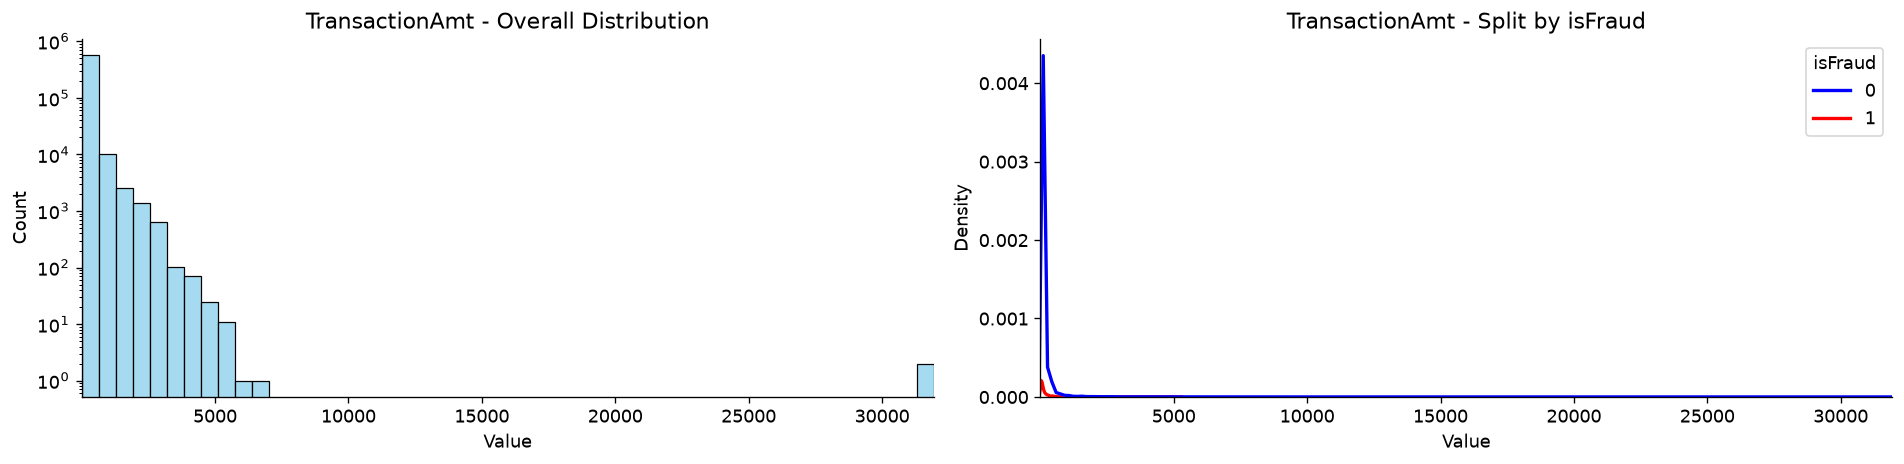

In [21]:
# Distribution of Transaction Amount by isFraud
feature_distribution(
    dataframe=df,
    bins=50,
    column="TransactionAmt",
    kde=True
)

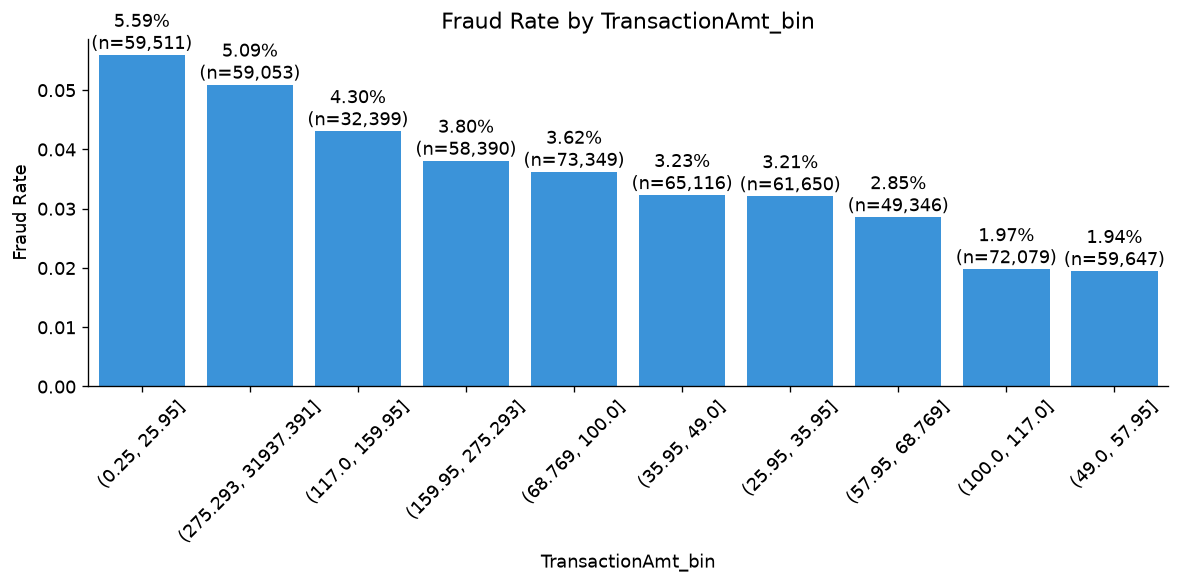

,Transactions,Fraud_Rate,Fraud_Count
TransactionAmt_bin,,,
"(0.25, 25.95]",59511,0.055889,3326
"(275.293, 31937.391]",59053,0.050870,3004
"(117.0, 159.95]",32399,0.043026,1394
"(159.95, 275.293]",58390,0.038037,2221
"(68.769, 100.0]",73349,0.036170,2653
"(35.95, 49.0]",65116,0.032250,2100
"(25.95, 35.95]",61650,0.032052,1976
"(57.95, 68.769]",49346,0.028513,1407
"(100.0, 117.0]",72079,0.019742,1423


In [22]:
# Fraud rate of TransactionAmt
plot_fraud_rate(
    dataframe=df,
    domain_col="TransactionAmt_bin",
    top=100
)

In [23]:
# stats
transaction_df = df[['TransactionAmt']]
transaction_fraud_df = df[['TransactionAmt']][df["isFraud"] == 1]
transaction_nonfraud_df = df[['TransactionAmt']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="TransactionAmt",
    dataframes=[transaction_df, transaction_fraud_df, transaction_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,590540.000000,20663.000000,569877.000000
mean,135.027176,149.244779,134.511665
std,239.162522,232.212163,239.395078
min,0.251000,0.292000,0.251000
25%,43.321000,35.044000,43.970000
50%,68.769000,75.000000,68.500000
75%,125.000000,161.000000,120.000000
max,31937.391000,5191.000000,31937.391000
unique values,20902.000000,2515.000000,20560.000000
NaNs,0.000000,0.000000,0.000000


### 2. dist1-dist2 (Distance)
- dist1-dist2 is highly right skewed
- shows strong divergence in Fraud rate for bins of values.
- These features are sparse because **~94%** values are **NaN values**, and need missing indicator not imputation in NaNs vlaues.
- very good candidate for model building

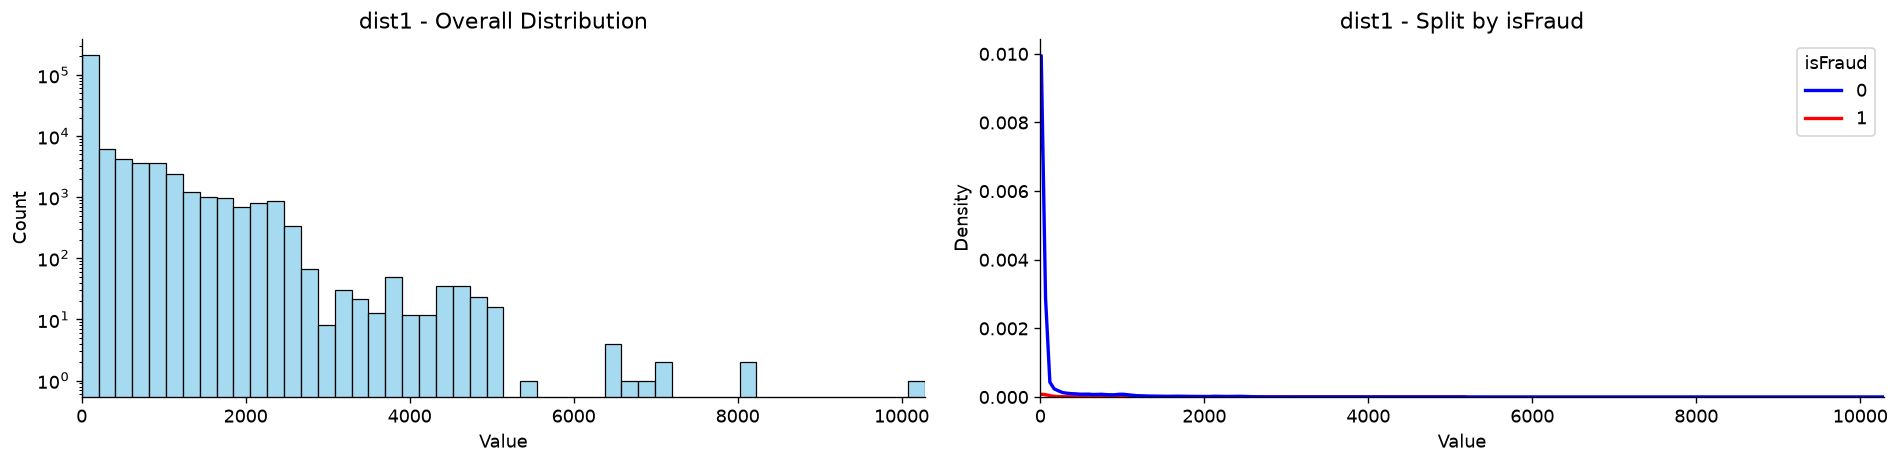

In [24]:
# Distribution by isFraud
feature_distribution(
    dataframe=df,
    bins=50,
    column="dist1",
    kde=True
)

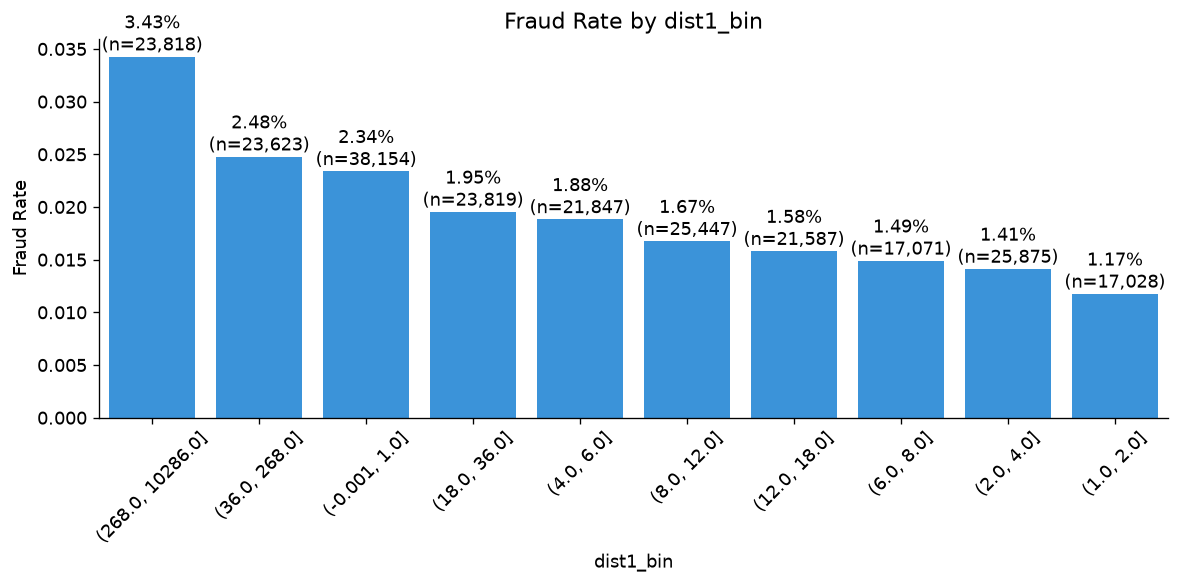

,Transactions,Fraud_Rate,Fraud_Count
dist1_bin,,,
"(268.0, 10286.0]",23818,0.034260,816
"(36.0, 268.0]",23623,0.024764,585
"(-0.001, 1.0]",38154,0.023379,892
"(18.0, 36.0]",23819,0.019522,465
"(4.0, 6.0]",21847,0.018813,411
"(8.0, 12.0]",25447,0.016741,426
"(12.0, 18.0]",21587,0.015797,341
"(6.0, 8.0]",17071,0.014879,254
"(2.0, 4.0]",25875,0.014106,365


In [25]:
# Fraud rate of dist1
# Creating dist1 Bins
df["dist1_bin"] = pd.qcut(
    df['dist1'],
    q=10, # 10 equal freuency bins
    duplicates="drop"
)
plot_fraud_rate(
    dataframe=df,
    domain_col="dist1_bin",
    top=100
)

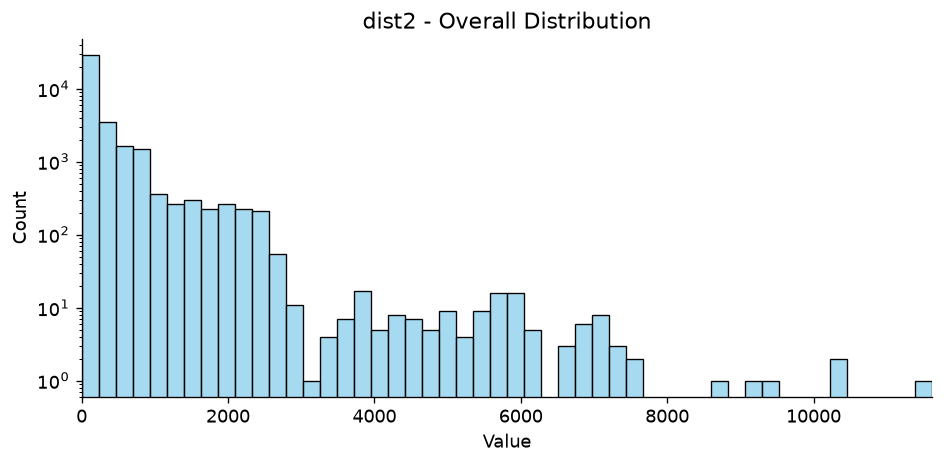

In [26]:
# Distribution by isFraud
feature_distribution(
    dataframe=df,
    bins=50,
    column="dist2"
)

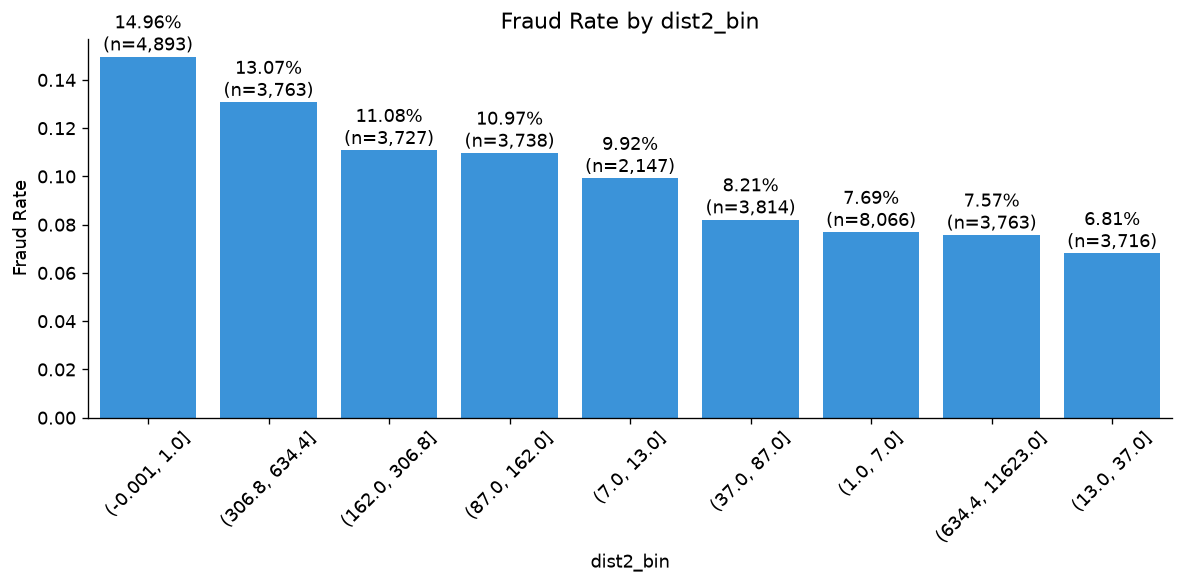

,Transactions,Fraud_Rate,Fraud_Count
dist2_bin,,,
"(-0.001, 1.0]",4893,0.149601,732
"(306.8, 634.4]",3763,0.130747,492
"(162.0, 306.8]",3727,0.110813,413
"(87.0, 162.0]",3738,0.109684,410
"(7.0, 13.0]",2147,0.099208,213
"(37.0, 87.0]",3814,0.082066,313
"(1.0, 7.0]",8066,0.076866,620
"(634.4, 11623.0]",3763,0.075737,285
"(13.0, 37.0]",3716,0.068084,253


In [27]:
# Fraud rate of dist2
# Creating dist2 Bins
df["dist2_bin"] = pd.qcut(
    df['dist2'],
    q=10, # 10 equal freuency bins
    duplicates="drop"
)
plot_fraud_rate(
    dataframe=df,
    domain_col="dist2_bin",
    top=100
)

In [28]:
# stats
dist_df = df[['dist1']]
dist_fraud_df = df[['dist1']][df["isFraud"] == 1]
dist_nonfraud_df = df[['dist1']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="dist1",
    dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,238269.000000,4755.000000,233514.000000
mean,118.502180,174.588854,117.360098
std,371.872026,424.232313,370.641879
min,0.000000,0.000000,0.000000
25%,3.000000,3.000000,3.000000
50%,8.000000,10.000000,8.000000
75%,24.000000,85.500000,24.000000
max,10286.000000,4942.000000,10286.000000
unique values,2651.000000,470.000000,2635.000000
NaNs,352271.000000,15908.000000,336363.000000


In [29]:
# stats
dist_df = df[['dist2']]
dist_fraud_df = df[['dist2']][df["isFraud"] == 1]
dist_nonfraud_df = df[['dist2']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="dist2",
    dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,37627.000000,3731.000000,33896.000000
mean,231.855423,201.472259,235.199758
std,529.053494,451.589576,536.798492
min,0.000000,0.000000,0.000000
25%,7.000000,7.000000,7.000000
50%,37.000000,49.000000,36.000000
75%,206.000000,233.000000,206.000000
max,11623.000000,9337.000000,11623.000000
unique values,1751.000000,344.000000,1723.000000
NaNs,552913.000000,16932.000000,535981.000000


### 3. Numerical Card features (card-1,2,3,5)

- **They are actually categorical features** as it is mentioned in the kaggle dataset description
- card1 has the highest cardinality, hence it is almost certainly an encoded identifier like ID columns
    - **Divergence is very weak, should be the candidate for model training.**
- card2: Although only 500 unique values exist, there is still no mathematical relationship between fraud and nonfraud.
- card3: Almost 90% of the data is concentrated in only two values.
    - Varience is low. hence, risk of overfitting, and curse of dimensionality issue if used one hot encoding etc.
- card5: Exactly like card3, 119 unique values.
    - Similar concentration issue to card3


- NOTES: **Divergence:** means does the feature look different for fraud vs. non-fraud transactions?

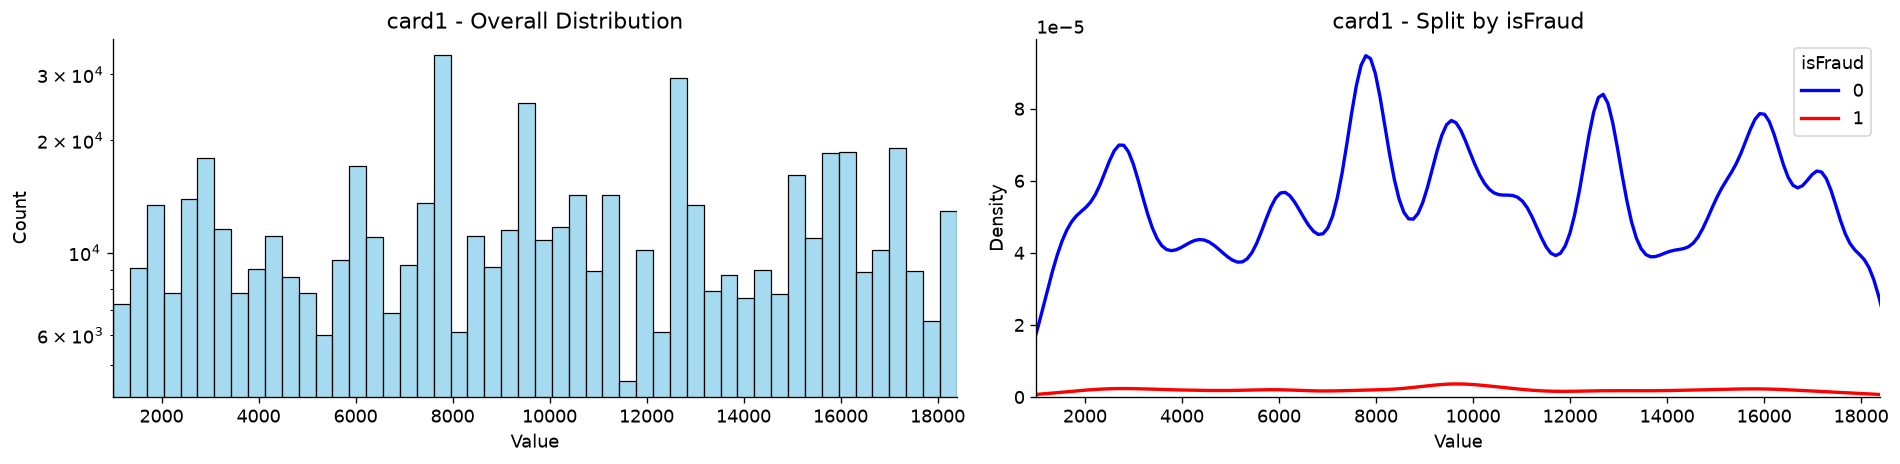

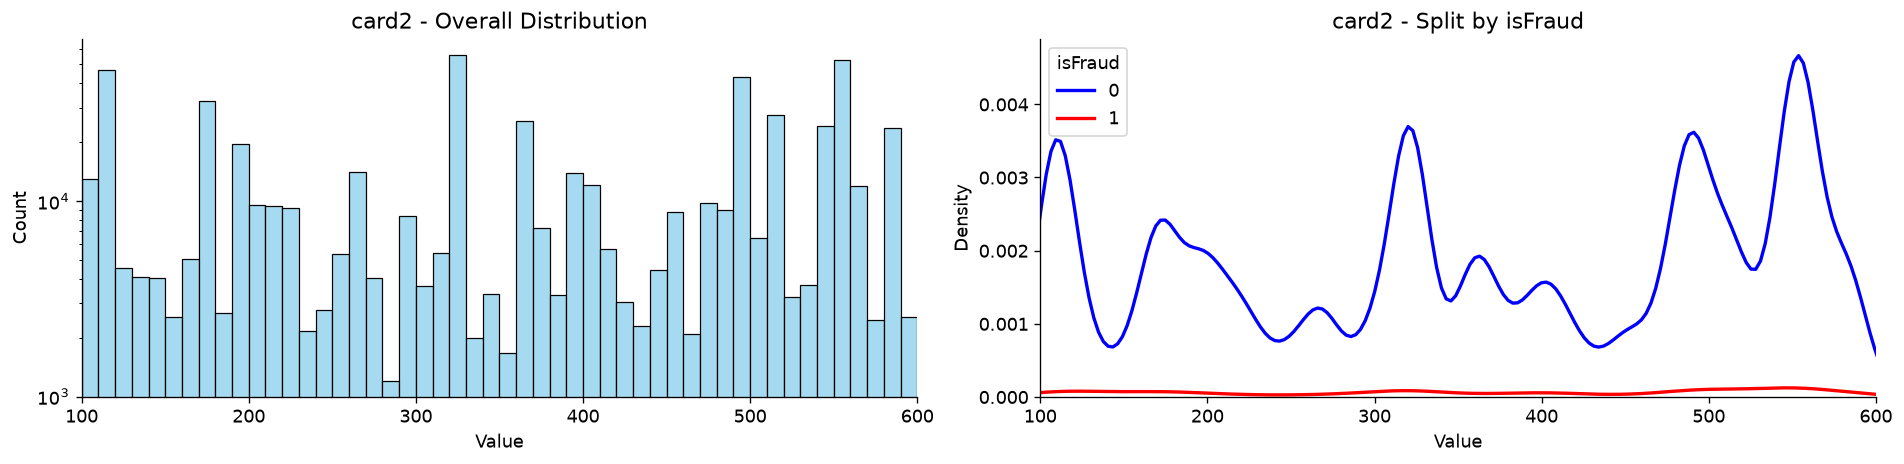

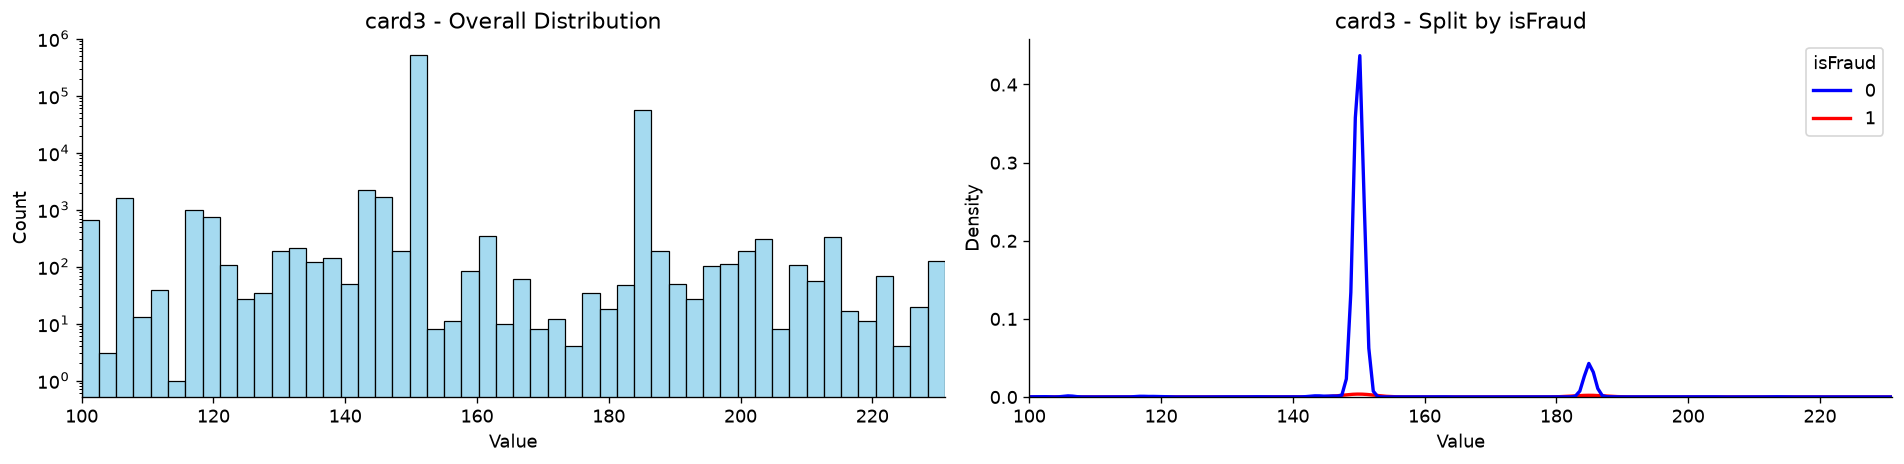

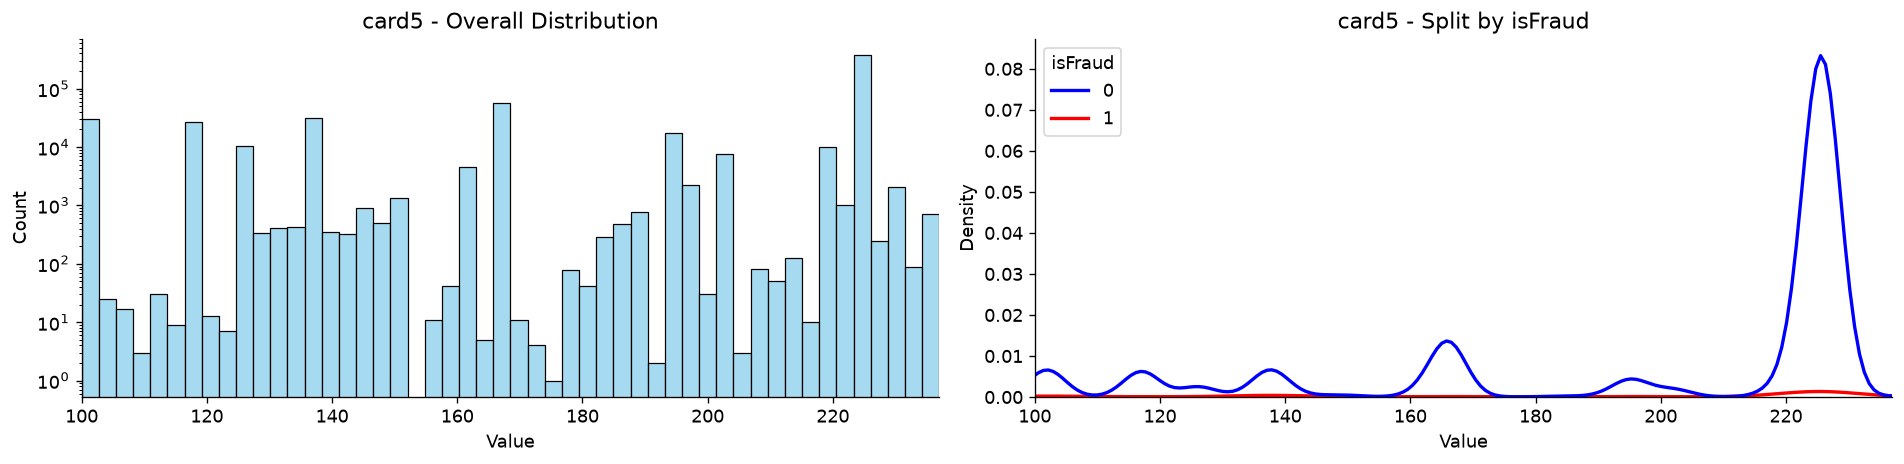

In [30]:
# Distribution by isFraud
numbers = [1,2,3,5]
for num in numbers:
    feature_distribution(
        dataframe=df,
        bins=50,
        column=f"card{num}",
        kde=True
    )

In [31]:
# stats
numbers = [1,2,3,5]
for i in numbers:
    print(f"-- Statistics for card{i} --")
    dist_df = df[[f"card{i}"]]
    dist_fraud_df = df[[f"card{i}"]][df["isFraud"] == 1]
    dist_nonfraud_df = df[[f"card{i}"]][df["isFraud"] == 0]

    summary_table = stat_describe(
        column=f"card{i}",
        dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
    )
    display(summary_table)
    print("=="*40)

-- Statistics for card1 --


,Train,Train fraud,Train Not fraud
count,590540.000000,20663.000000,569877.000000
mean,9898.734658,9547.654164,9911.464381
std,4901.170153,4762.051380,4905.672370
min,1000.000000,1015.000000,1000.000000
25%,6019.000000,5732.500000,6019.000000
50%,9678.000000,9633.000000,9711.000000
75%,14184.000000,13623.000000,14229.000000
max,18396.000000,18375.000000,18396.000000
unique values,13553.000000,1740.000000,13350.000000
NaNs,0.000000,0.000000,0.000000


-- Statistics for card2 --


,Train,Train fraud,Train Not fraud
count,581607.000000,20240.000000,561367.000000
mean,362.555488,365.370850,362.453981
std,157.793246,159.623511,157.726065
min,100.000000,100.000000,100.000000
25%,214.000000,204.000000,215.000000
50%,361.000000,375.000000,361.000000
75%,512.000000,514.000000,512.000000
max,600.000000,600.000000,600.000000
unique values,500.000000,327.000000,500.000000
NaNs,8933.000000,423.000000,8510.000000


-- Statistics for card3 --


,Train,Train fraud,Train Not fraud
count,588975.000000,20624.000000,568351.000000
mean,153.194925,162.368648,152.862034
std,11.336444,17.495775,10.904432
min,100.000000,100.000000,100.000000
25%,150.000000,150.000000,150.000000
50%,150.000000,150.000000,150.000000
75%,150.000000,185.000000,150.000000
max,231.000000,231.000000,231.000000
unique values,114.000000,62.000000,106.000000
NaNs,1565.000000,39.000000,1526.000000


-- Statistics for card5 --


,Train,Train fraud,Train Not fraud
count,586281.000000,20453.000000,565828.000000
mean,199.278897,191.994328,199.542212
std,41.244453,45.779886,41.046975
min,100.000000,100.000000,100.000000
25%,166.000000,138.000000,166.000000
50%,226.000000,224.000000,226.000000
75%,226.000000,226.000000,226.000000
max,237.000000,237.000000,237.000000
unique values,119.000000,49.000000,118.000000
NaNs,4259.000000,210.000000,4049.000000


### 4. Categorical Card features [4, 6]

- card4: discover/mastercard/visa show different fraud rates, Most of transaction is done using visa, mastercard
- card6: credit >> debit fraud rate means most of transaction is done using debit or credit cards where debit card is more popular.

### Helper Function

In [32]:
from typing import Optional

def categorical_countplot(
    dataframe: pd.DataFrame,
    column: str,
    hue: Optional[str] = None,
    palette: Optional[dict[str, str]] = None,
    figsize=(8, 4),
    top: Optional[int] = None
):
    """
    Plot a countplot for a categorical column.

    dataframe : pd.DataFrame
        The dataset.
    column : str
        The categorical column to plot.
    hue : str, optional
        Column to use for hue (e.g., 'isFraud'). If provided, palette is ignored.
    palette : dict, optional
        Custom palette mapping categories to colors. Used only if hue is None.
    figsize : tuple, optional
        Size of the figure.
    """
    fig, ax = plt.subplots(figsize=figsize)

    if top is not None: 
        top_categories = dataframe[column].value_counts().nlargest(10).index
        dataframe = dataframe[dataframe[column].isin(top_categories)]

    order = dataframe[column].value_counts().index
    if hue:
        barplot = sns.countplot(data=dataframe, x=column, hue=hue, ax=ax, order=order)
    else:
        barplot = sns.countplot(data=dataframe, x=column, ax=ax, palette=palette, order=order)
    if hue:
        ax.set_title(f"{column} Count plot by isFraud")
    else:
        ax.set_title(f"{column} Count plot")

    # Add counts on top of bars
    for container in barplot.containers:
        ax.bar_label(container, fmt='%d', label_type='edge') # type: ignore
    if top is not None:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

    plt.tight_layout()
    plt.show()


In [105]:
df['card4'].value_counts().index

Index(['visa', 'mastercard', 'american express', 'discover'], dtype='str', name='card4')

In [106]:
df['card6'].value_counts().index

Index(['debit', 'credit', 'debit or credit', 'charge card'], dtype='str', name='card6')

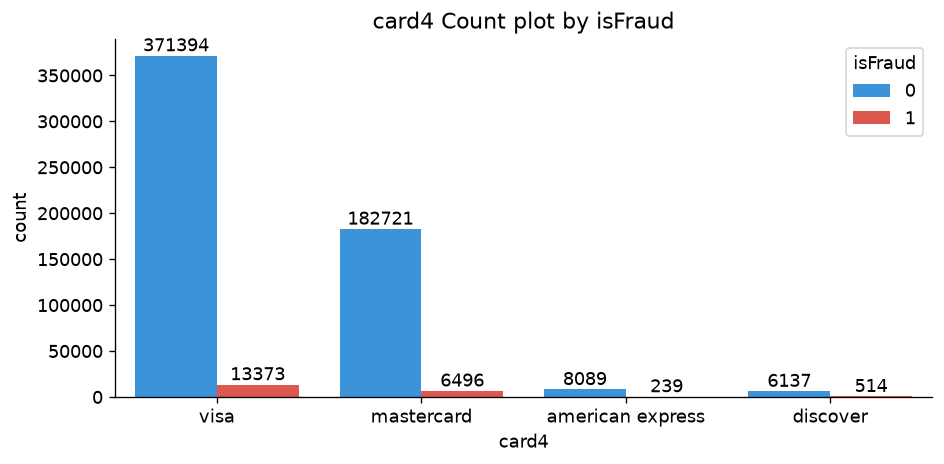

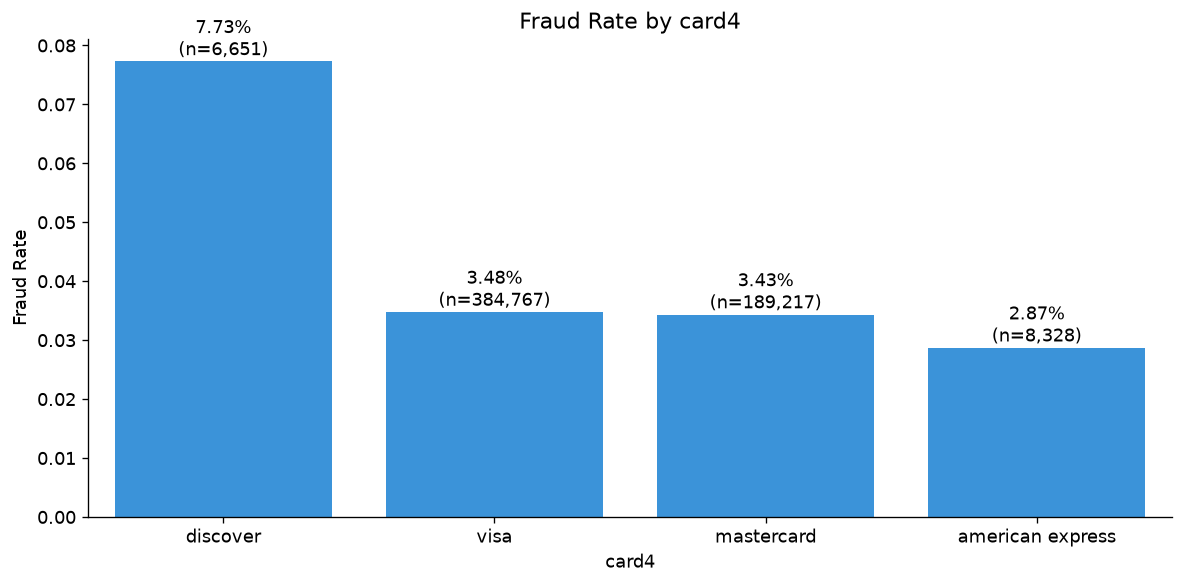

,Transactions,Fraud_Rate,Fraud_Count
card4,,,
discover,6651,0.077282,514
visa,384767,0.034756,13373
mastercard,189217,0.034331,6496
american express,8328,0.028698,239


In [103]:
# Card Category count by isFraud
categorical_countplot(df, column="card4", hue="isFraud")
plot_fraud_rate(df, "card4")

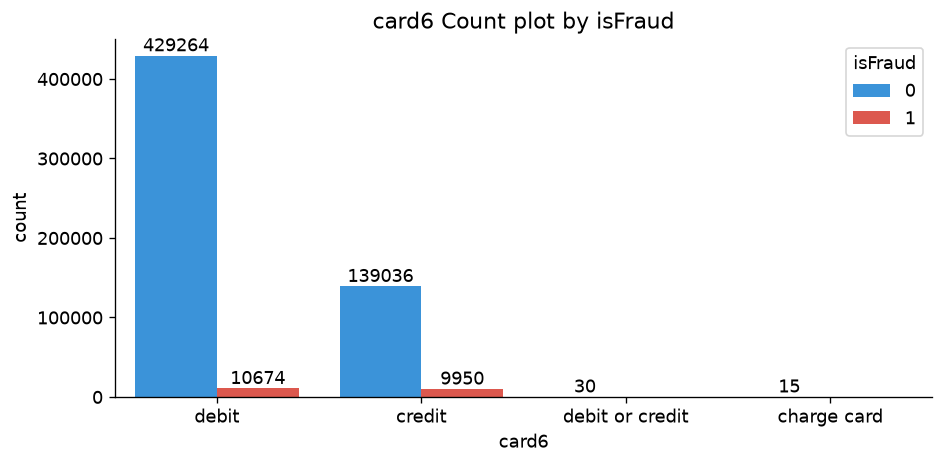

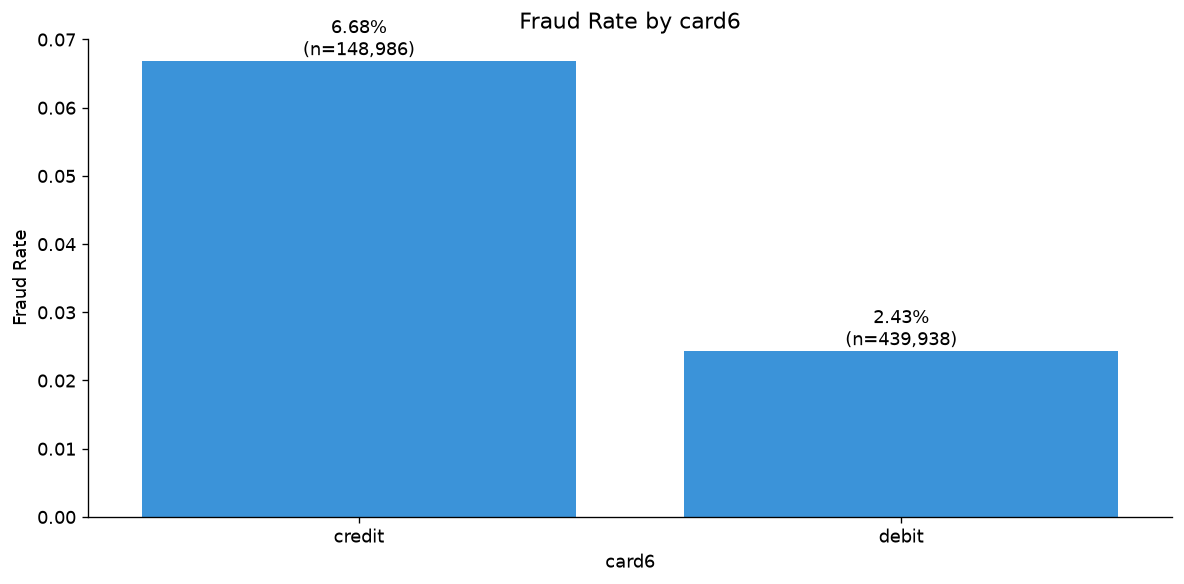

,Transactions,Fraud_Rate,Fraud_Count
card6,,,
credit,148986,0.066785,9950
debit,439938,0.024263,10674


In [104]:
# Fraud rate of card 4, 6
categorical_countplot(df, column="card6", hue="isFraud")
plot_fraud_rate(df, "card6")

In [35]:
# stats
numbers = [4,6]
for i in numbers:
    print(f"-- Statistics for card{i} --")
    dist_df = df[[f"card{i}"]]
    dist_fraud_df = df[[f"card{i}"]][df["isFraud"] == 1]
    dist_nonfraud_df = df[[f"card{i}"]][df["isFraud"] == 0]

    summary_table = stat_describe(
        column=f"card{i}",
        dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
    )
    display(summary_table)
    print("=="*40)

-- Statistics for card4 --


,Train,Train fraud,Train Not fraud
count,588963,20622,568341
unique,4,4,4
top,visa,visa,visa
freq,384767,13373,371394
unique values,4,4,4
NaNs,1577,41,1536
NaNs share,0.00267,0.001984,0.002695


-- Statistics for card6 --


,Train,Train fraud,Train Not fraud
count,588969,20624,568345
unique,4,2,4
top,debit,debit,debit
freq,439938,10674,429264
unique values,4,2,4
NaNs,1571,39,1532
NaNs share,0.00266,0.001887,0.002688


### 5. ProductCD feature (Product Code)

- Categorical feature
- About ~83% of product are "W" product code.
- **Product code "C" is very small** in Non Fraudulent Transaction compare to code "W" but **it is the second highest in Fraud Transactions**.
- Divergence is very strong and this feature is the strong candidate for model training.

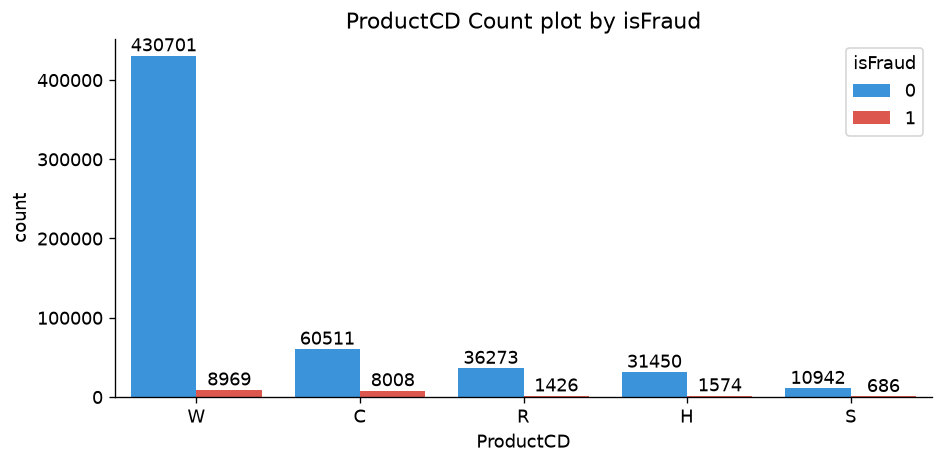

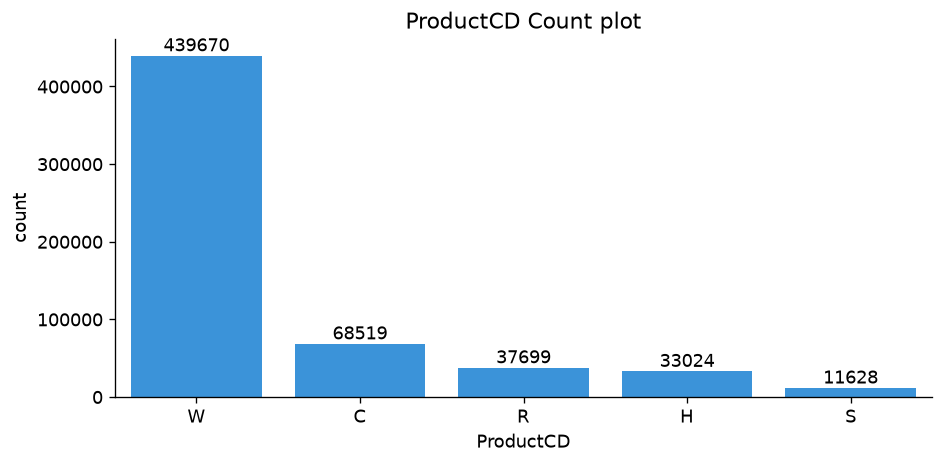

In [36]:
# Example 1: With hue (palette ignored)
categorical_countplot(df, column="ProductCD", hue="isFraud")

# Example 2: Without hue (palette applied)
categorical_countplot(df, column="ProductCD")

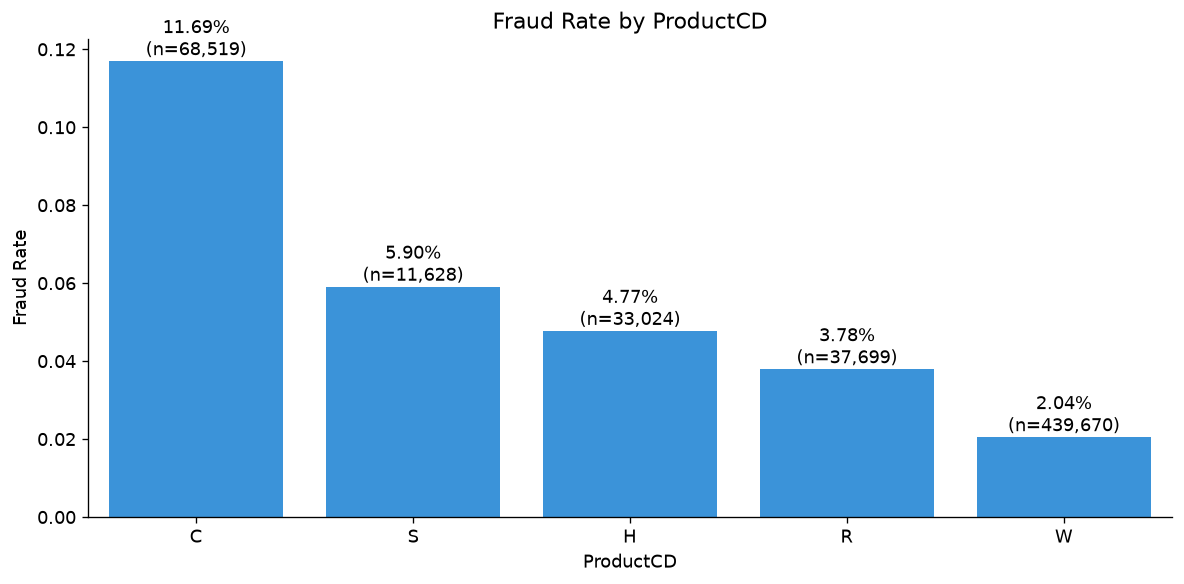

,Transactions,Fraud_Rate,Fraud_Count
ProductCD,,,
C,68519,0.116873,8008
S,11628,0.058996,686
H,33024,0.047662,1574
R,37699,0.037826,1426
W,439670,0.020399,8969


In [37]:
# Fraud rate of ProductCD
plot_fraud_rate(df, "ProductCD")

In [38]:
# stats
productCD_df = df[['ProductCD']]
productCD_fraud_df = df[['ProductCD']][df["isFraud"] == 1]
productCD_nonfraud_df = df[['ProductCD']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="ProductCD",
    dataframes=[productCD_df, productCD_fraud_df, productCD_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,590540,20663,569877
unique,5,5,5
top,W,W,W
freq,439670,8969,430701
unique values,5,5,5
NaNs,0,0,0
NaNs share,0.0,0.0,0.0


### 6. P_emaildomains and R_emaildomain feature (Purchaser email, Recipient email)

- Categorical features
- gmail.com, yahoo.com, hotmail.com and anonymous.com is 4 most used email domains used by purchasers and recipients.
- Protonmail.com → ~95% of transactions are fraudulent. That’s an extreme signal: almost every transaction from this domain is fraud.
- Mail.com → ~38% fraud rate. Still very high compared to mainstream providers.
- Netzero.net, Outlook.com, Outlook.es, iCloud.com → all show double‑digit fraud rates, meaning a significant fraction of their traffic is fraudulent.
- Gmail.com and Hotmail.com → although they dominate in raw transaction counts, their fraud rates are much lower (~12% and ~8%). This means they’re popular but relatively safer compared to smaller domains.

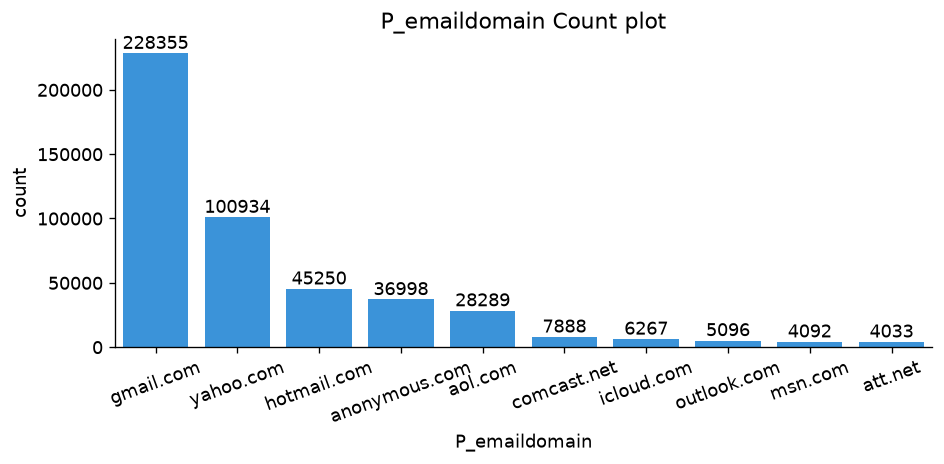

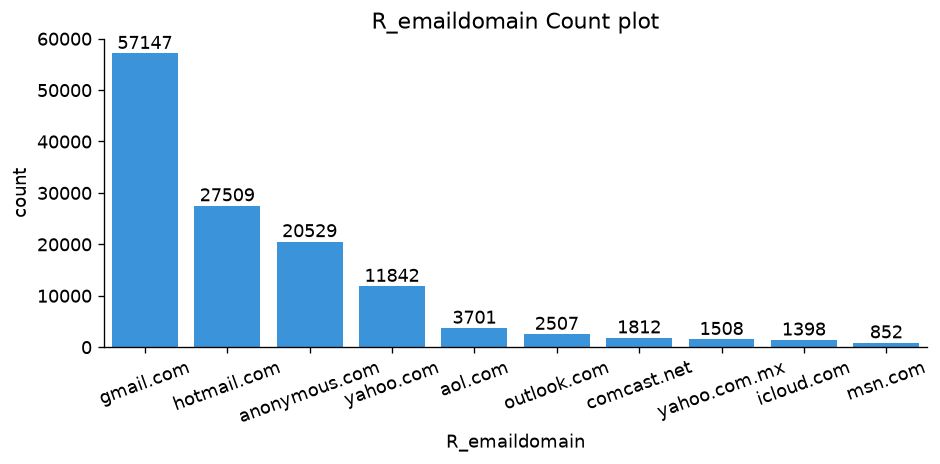

In [39]:
# P_emaildomain
categorical_countplot(df, column="P_emaildomain", top=8)

# R_emaildomain
categorical_countplot(df, column="R_emaildomain", top=8)

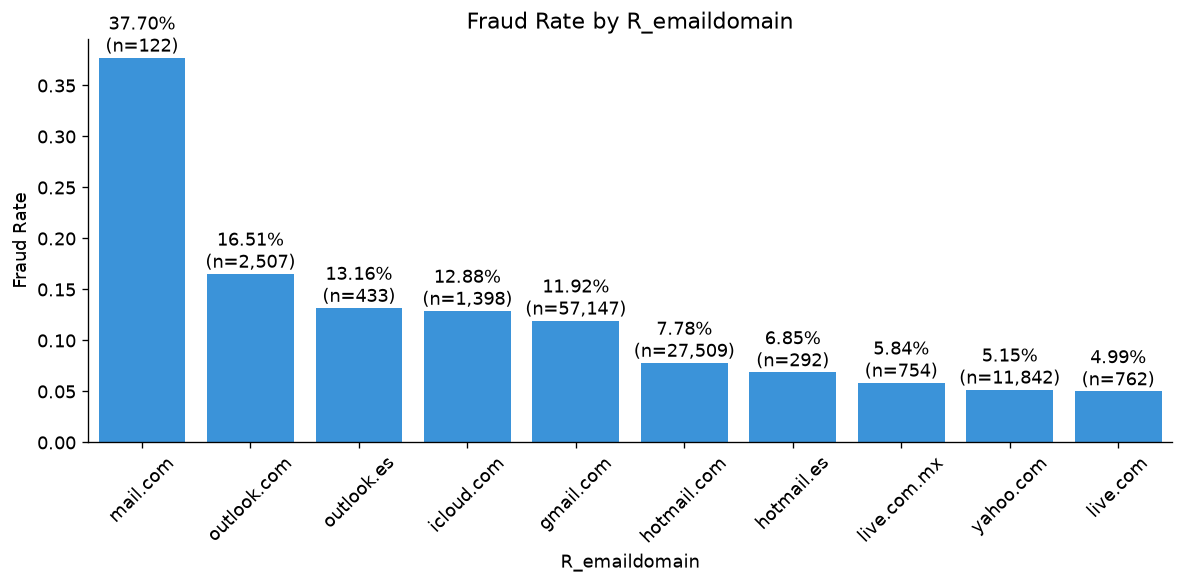

,Transactions,Fraud_Rate,Fraud_Count
R_emaildomain,,,
mail.com,122,0.377049,46
outlook.com,2507,0.165138,414
outlook.es,433,0.131640,57
icloud.com,1398,0.128755,180
gmail.com,57147,0.119184,6811
hotmail.com,27509,0.077793,2140
hotmail.es,292,0.068493,20
live.com.mx,754,0.058355,44
yahoo.com,11842,0.051512,610


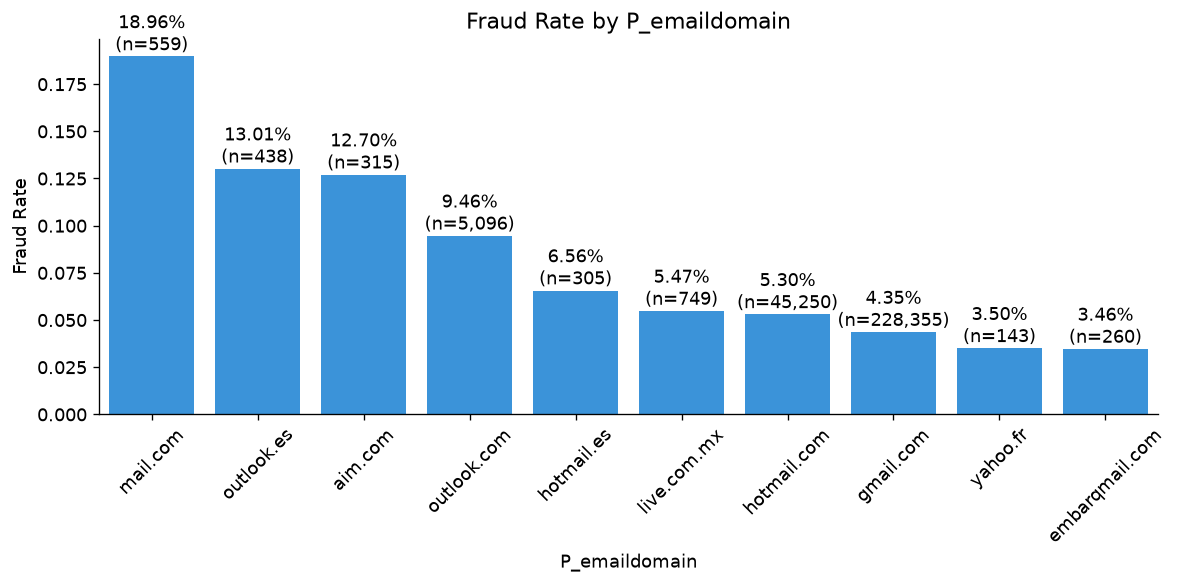

,Transactions,Fraud_Rate,Fraud_Count
P_emaildomain,,,
mail.com,559,0.189624,106
outlook.es,438,0.130137,57
aim.com,315,0.126984,40
outlook.com,5096,0.094584,482
hotmail.es,305,0.065574,20
live.com.mx,749,0.054740,41
hotmail.com,45250,0.052950,2396
gmail.com,228355,0.043542,9943
yahoo.fr,143,0.034965,5


In [40]:
# Fraud Rate of R_emaildomain
plot_fraud_rate(df, "R_emaildomain", top=10)

# Fraud Rate of P_emaildomain
plot_fraud_rate(df, "P_emaildomain", top=10)

In [41]:
# stats
r_emaildomain_df = df[['R_emaildomain']]
r_emaildomain_fraud_df = df[['R_emaildomain']][df["isFraud"] == 1]
r_emaildomain_nonfraud_df = df[['R_emaildomain']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="R_emaildomain",
    dataframes=[r_emaildomain_df, r_emaildomain_fraud_df, r_emaildomain_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,137291,11227,126064
unique,60,32,60
top,gmail.com,gmail.com,gmail.com
freq,57147,6811,50336
unique values,60,32,60
NaNs,453249,9436,443813
NaNs share,0.767516,0.456662,0.778787


In [42]:
# stats
p_emaildomain_df = df[['P_emaildomain']]
p_emaildomain_fraud_df = df[['P_emaildomain']][df["isFraud"] == 1]
p_emaildomain_nonfraud_df = df[['P_emaildomain']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="P_emaildomain",
    dataframes=[p_emaildomain_df, p_emaildomain_fraud_df, p_emaildomain_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,496084,17873,478211
unique,59,42,59
top,gmail.com,gmail.com,gmail.com
freq,228355,9943,218412
unique values,59,42,59
NaNs,94456,2790,91666
NaNs share,0.159949,0.135024,0.160852


### 7. DeviceType

- Categorical feature
- Customer used desktop device more for the banking.
- Even then the fraud transaction are ~ equal in both.
    - desktop fraud transaction: 5554
    - mobile fraud transaction: 5657
- Fraud rate of mobile transaction is very high 10.17% by it total no. of transaction compare to desktop 6.52%
- there is divergence in fraud rate for all categories in DeviceTye, and it is a good candidate for model training.

In [43]:
df['DeviceType'].value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

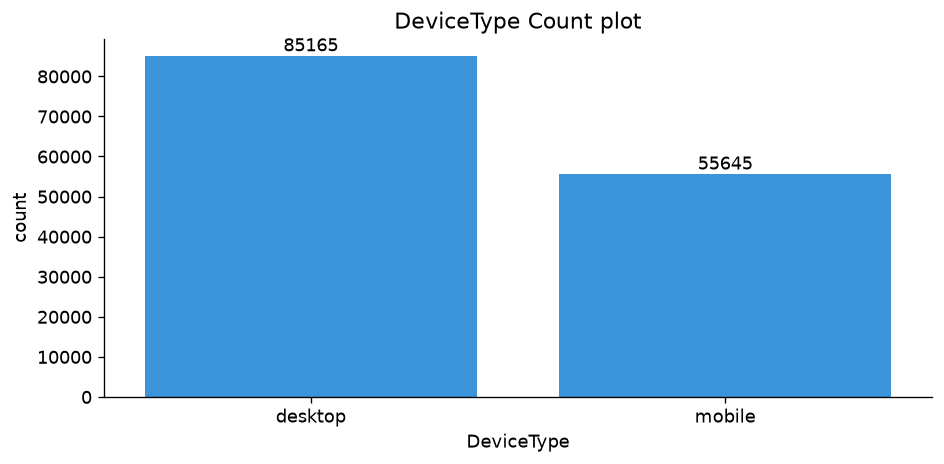

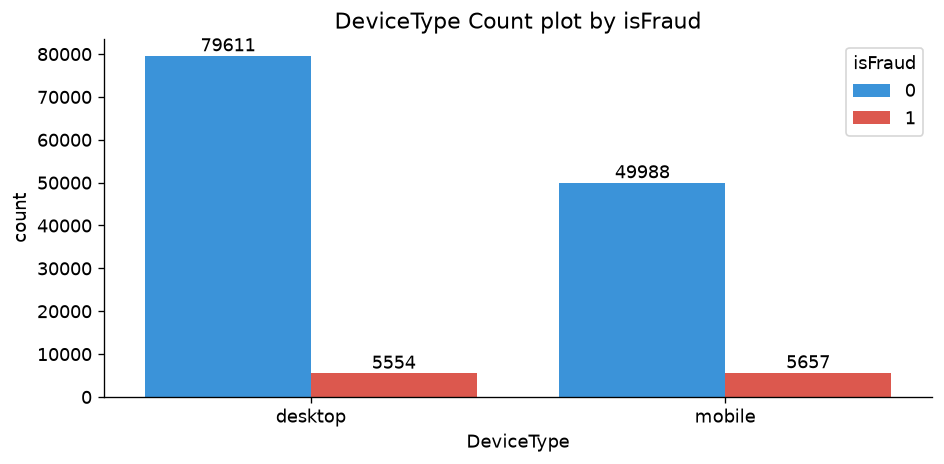

In [44]:
# Total Distribution of Device Type
categorical_countplot(
    dataframe=df,
    column="DeviceType"
)

categorical_countplot(
    dataframe=df,
    column="DeviceType",
    hue="isFraud"
)

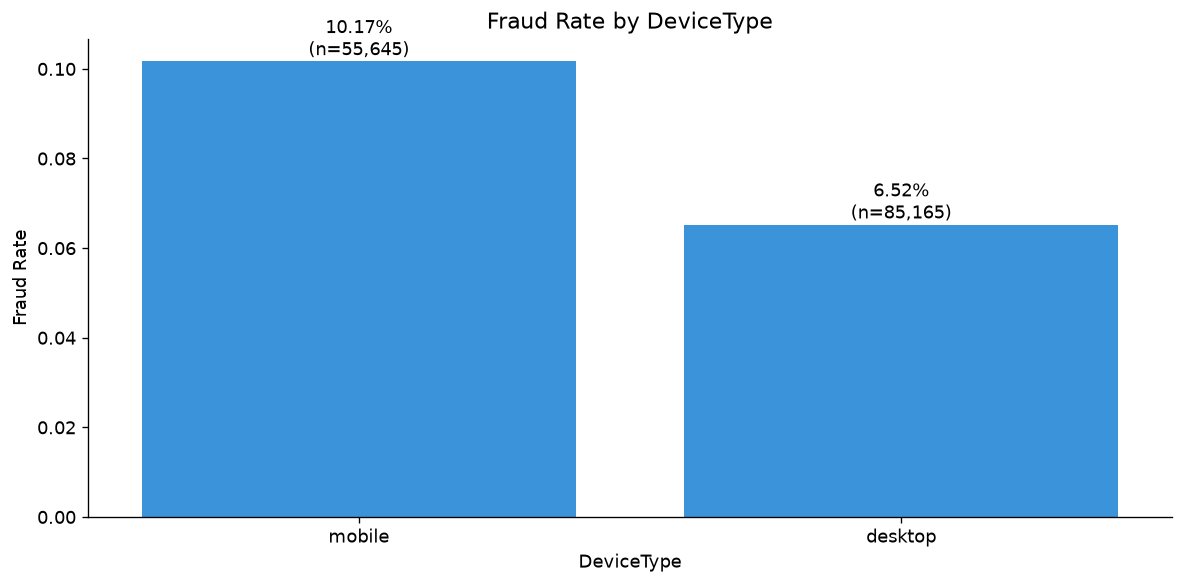

,Transactions,Fraud_Rate,Fraud_Count
DeviceType,,,
mobile,55645,0.101662,5657
desktop,85165,0.065215,5554


In [45]:
# Plotting fraud rate of Device Type
plot_fraud_rate(
    dataframe=df,
    domain_col="DeviceType"
)

### 8. M1-M6 features 

- Categorical Features
- **M1**: Divergence is very low, and Almost all observations are T; F has only 25 samples, so no reliable conclusion can be drawn.
- **M2**: F has nearly 2× the fraud rate of T (3.49% vs 1.81%). Candidate feature.
- **M3**: F has noticeably higher fraud rate than T (3.03% vs 1.71%). Candidate feature.
- **M4**: Clear separation. M2 category has a much higher fraud rate than M0 and M1. Strong candidate feature.
- **M5**: T shows higher fraud rate than F (3.77% vs 2.65%). Candidate featur
- **M6**: F has higher fraud rate than T (2.37% vs 1.70%), but the difference is smaller than M2–M5. Candidate, but lower priority.
- **M7**:  Low variance + weak separation → not very predictive.
- **M8**: Moderate variance, and here the fraud rate differs more noticeably. Could add signal.
- **M9**: Stronger separation in fraud rate. Even though imbalanced, this feature looks predictive.

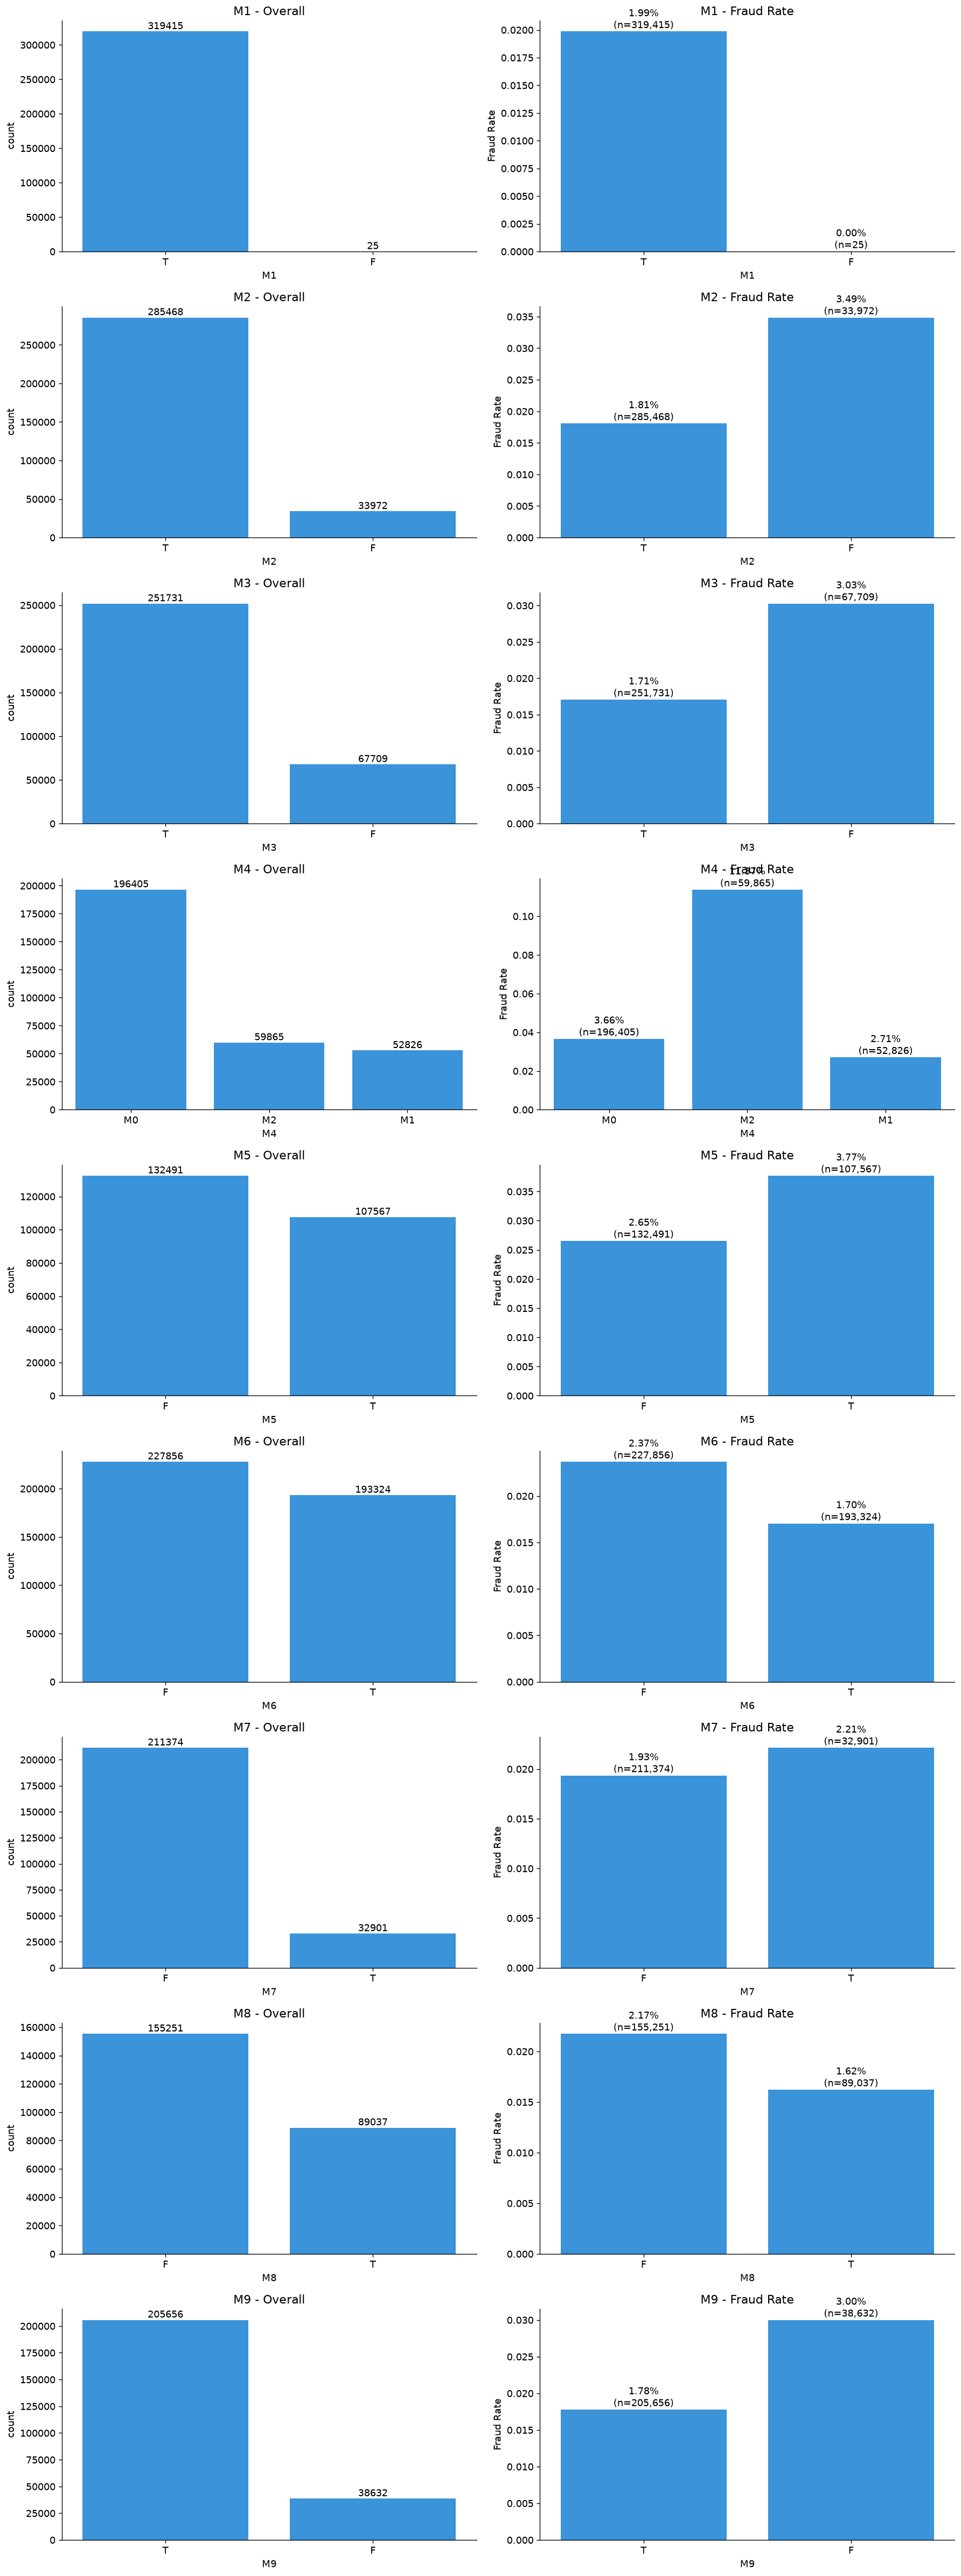

In [46]:
fig, axes = plt.subplots(
    nrows=9,
    ncols=2,
    figsize=(15, 40)
)

for i in range(1, 10):
    col = f"M{i}"

    # Overall Count Plot
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        ax=axes[i-1, 0]
    )

    axes[i-1, 0].set_title(f"{col} - Overall")

    for container in axes[i-1, 0].containers:
        axes[i-1, 0].bar_label(container, fmt="%d")

    # Fraud Rate Plot
    summary = (
        df.groupby(col)["isFraud"]
        .agg(
            Transactions="count",
            Fraud_Rate="mean",
            Fraud_Count="sum"
        ).loc[order]
    )

    barplot = sns.barplot(
        x=summary.index,
        y=summary["Fraud_Rate"],
        ax=axes[i-1, 1]
    )

    axes[i-1, 1].set_title(f"{col} - Fraud Rate")
    axes[i-1, 1].set_ylabel("Fraud Rate")

    labels = [
        f"{rate*100:.2f}%\n(n={count:,})"
        for rate, count in zip(
            summary["Fraud_Rate"],
            summary["Transactions"]
        )
    ]

    for container in barplot.containers:
        axes[i-1, 1].bar_label(
            container,
            labels=labels,
            label_type="edge"
        )

plt.tight_layout()
plt.show()

### 9. addr1 - addr2 (Address)

- addr1: 
    - Fraud rates across bins are very close (≈2.0–2.9%), so the raw values don’t separate fraud well.
    - NaNs are disproportionately high in fraud cases (~37%), which makes missingness itself predictive.
    - Addr1 is weak as a raw categorical feature, but strong as a missingness indicator.

- addr2: 
    - Fraud rate separation is huge: one bin has ~13.4% fraud vs another with ~2.45%.
    - Again, NaNs are much more common in fraud (~37%), so missingness is predictive here too.
    - Addr2 is highly predictive, despite skew, because certain bins strongly correlate with fraud.

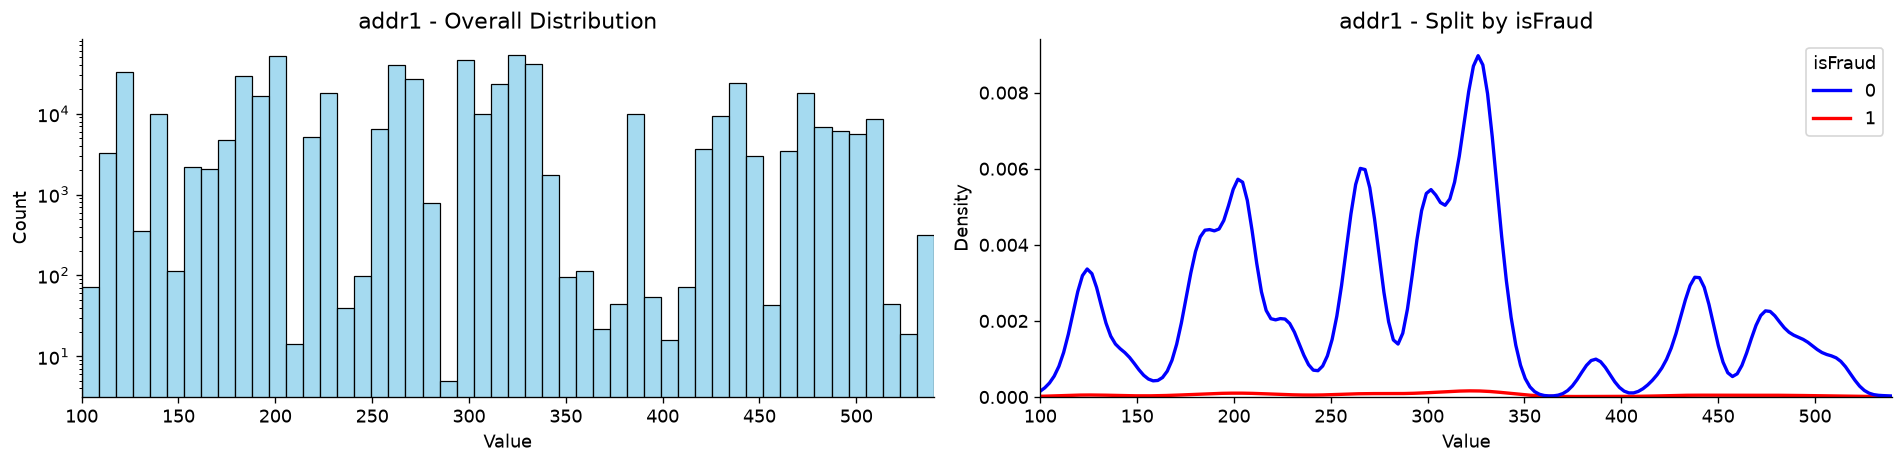

In [47]:
# Distribution by isFraud
feature_distribution(
    dataframe=df,
    bins=50,
    column="addr1",
    kde=True
)

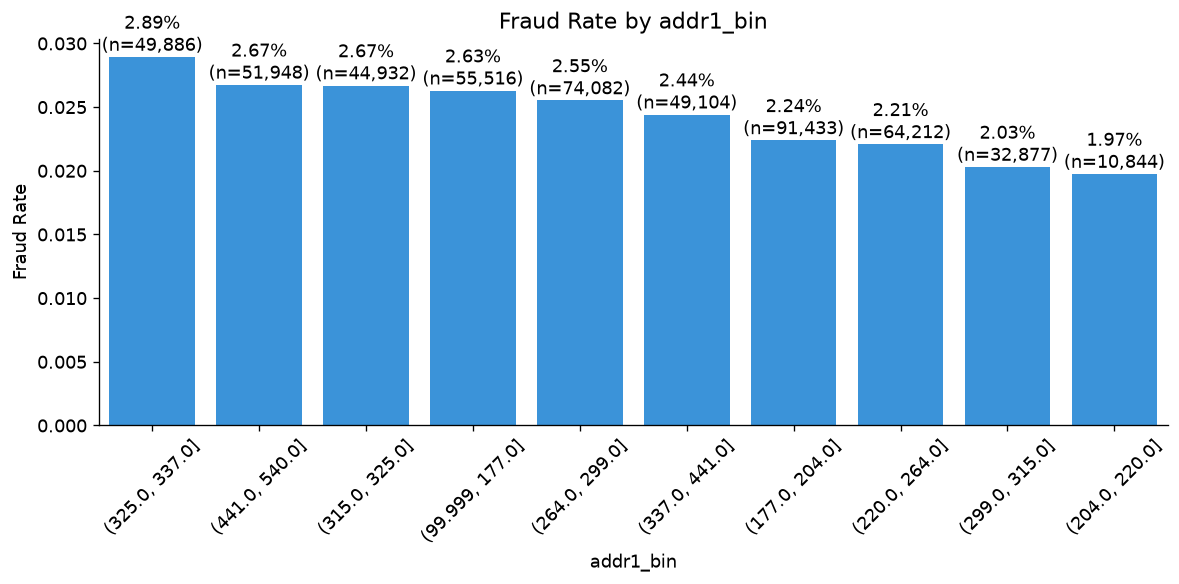

,Transactions,Fraud_Rate,Fraud_Count
addr1_bin,,,
"(325.0, 337.0]",49886,0.028926,1443
"(441.0, 540.0]",51948,0.026738,1389
"(315.0, 325.0]",44932,0.026685,1199
"(99.999, 177.0]",55516,0.026281,1459
"(264.0, 299.0]",74082,0.025512,1890
"(337.0, 441.0]",49104,0.024397,1198
"(177.0, 204.0]",91433,0.022377,2046
"(220.0, 264.0]",64212,0.022068,1417
"(299.0, 315.0]",32877,0.020288,667


In [48]:
# Fraud rate of addr1
# Creating addr1 Bins
df["addr1_bin"] = pd.qcut(
    df['addr1'],
    q=10, # 10 equal freuency bins
    duplicates="drop"
)
plot_fraud_rate(
    dataframe=df,
    domain_col="addr1_bin",
    top=100
)

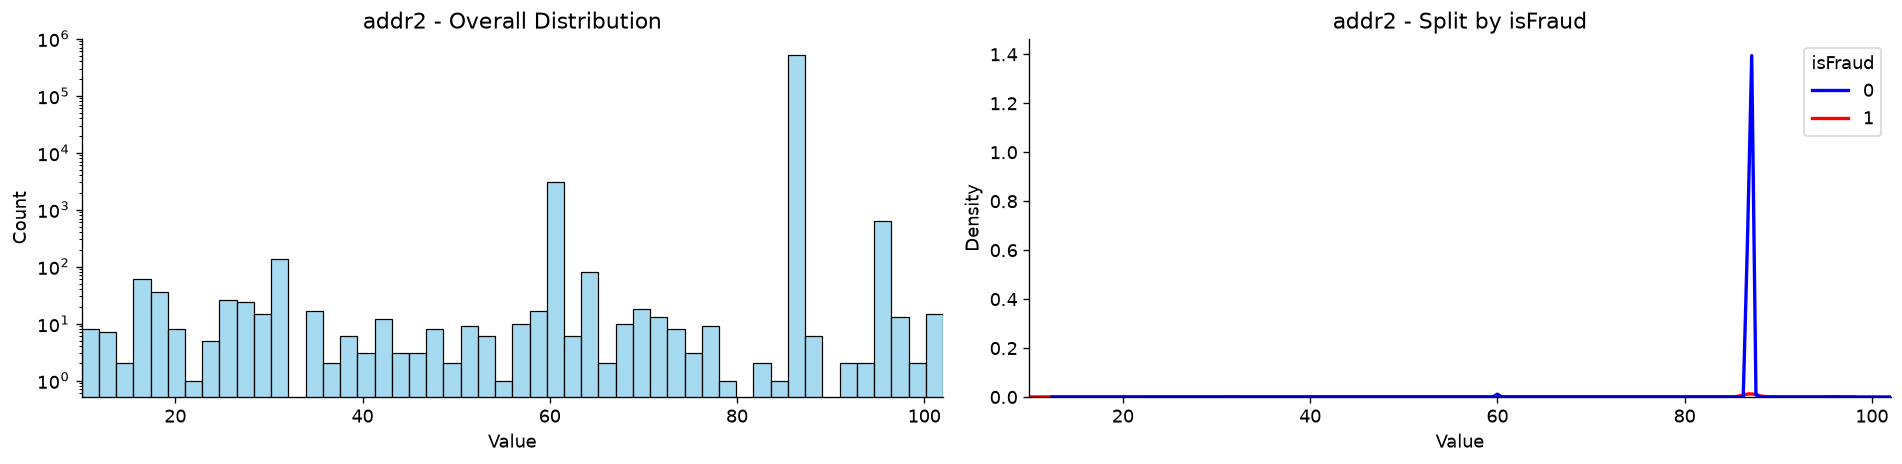

In [49]:
# Distribution by isFraud
feature_distribution(
    dataframe=df,
    bins=50,
    column="addr2",
    kde=True
)

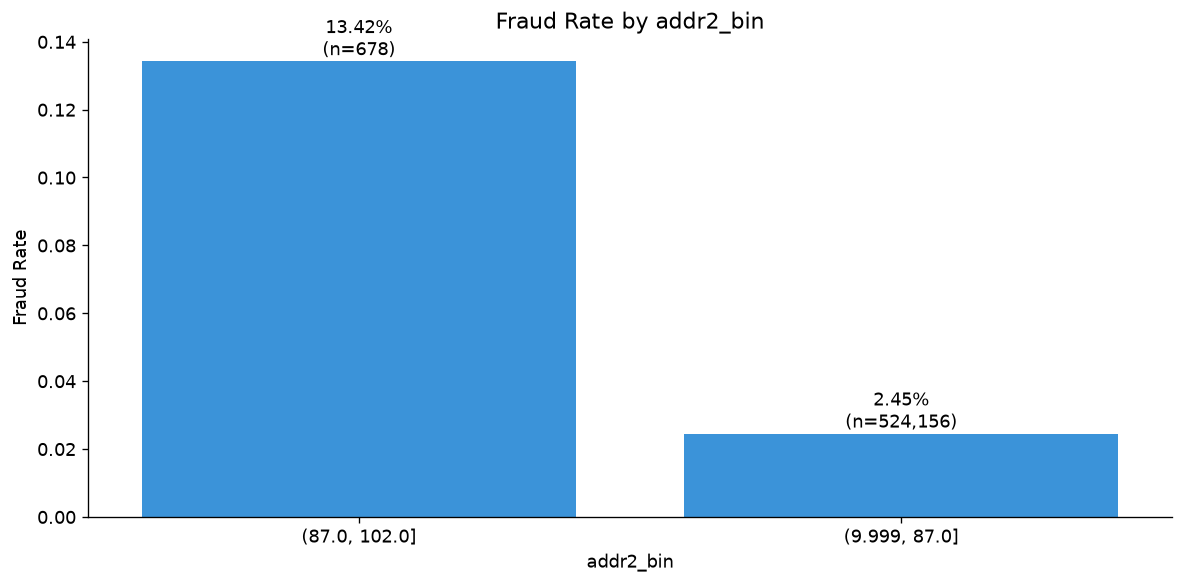

,Transactions,Fraud_Rate,Fraud_Count
addr2_bin,,,
"(87.0, 102.0]",678,0.134218,91
"(9.999, 87.0]",524156,0.024479,12831


In [50]:
# Fraud rate of addr2
# Creating addr2 Bins
df["addr2_bin"] = pd.qcut(
    df['addr2'],
    q=10, # 10 equal freuency bins
    duplicates="drop"
)
plot_fraud_rate(
    dataframe=df,
    domain_col="addr2_bin",
    top=100
)

In [51]:
# stats
dist_df = df[['addr1']]
dist_fraud_df = df[['addr1']][df["isFraud"] == 1]
dist_nonfraud_df = df[['addr1']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="addr1",
    dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,524834.000000,12922.000000,511912.000000
mean,290.733794,294.317134,290.643341
std,101.741072,103.584955,101.692564
min,100.000000,110.000000,100.000000
25%,204.000000,204.000000,204.000000
50%,299.000000,299.000000,299.000000
75%,330.000000,330.000000,330.000000
max,540.000000,536.000000,540.000000
unique values,332.000000,86.000000,332.000000
NaNs,65706.000000,7741.000000,57965.000000


In [52]:
# stats
dist_df = df[['addr2']]
dist_fraud_df = df[['addr2']][df["isFraud"] == 1]
dist_nonfraud_df = df[['addr2']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="addr2",
    dataframes=[dist_df, dist_fraud_df, dist_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,524834.000000,12922.000000,511912.000000
mean,86.800630,86.286024,86.813620
std,2.690623,4.936238,2.607742
min,10.000000,10.000000,13.000000
25%,87.000000,87.000000,87.000000
50%,87.000000,87.000000,87.000000
75%,87.000000,87.000000,87.000000
max,102.000000,96.000000,102.000000
unique values,74.000000,17.000000,68.000000
NaNs,65706.000000,7741.000000,57965.000000


### 10. DeviceInfo (Device Information)

In [53]:
df["DeviceInfo"].value_counts()

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
                               ...  
G8142                              1
G630-U251                          1
LG-K212                            1
LDN-LX3 Build/HUAWEILDN-LX3        1
Z955A                              1
Name: count, Length: 1786, dtype: int64

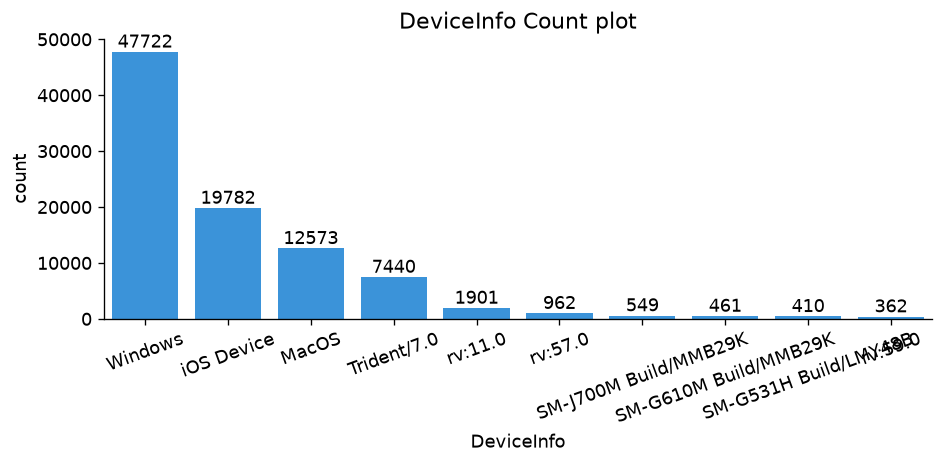

In [54]:
# DeviceInfo
categorical_countplot(df, column="DeviceInfo", top=10)

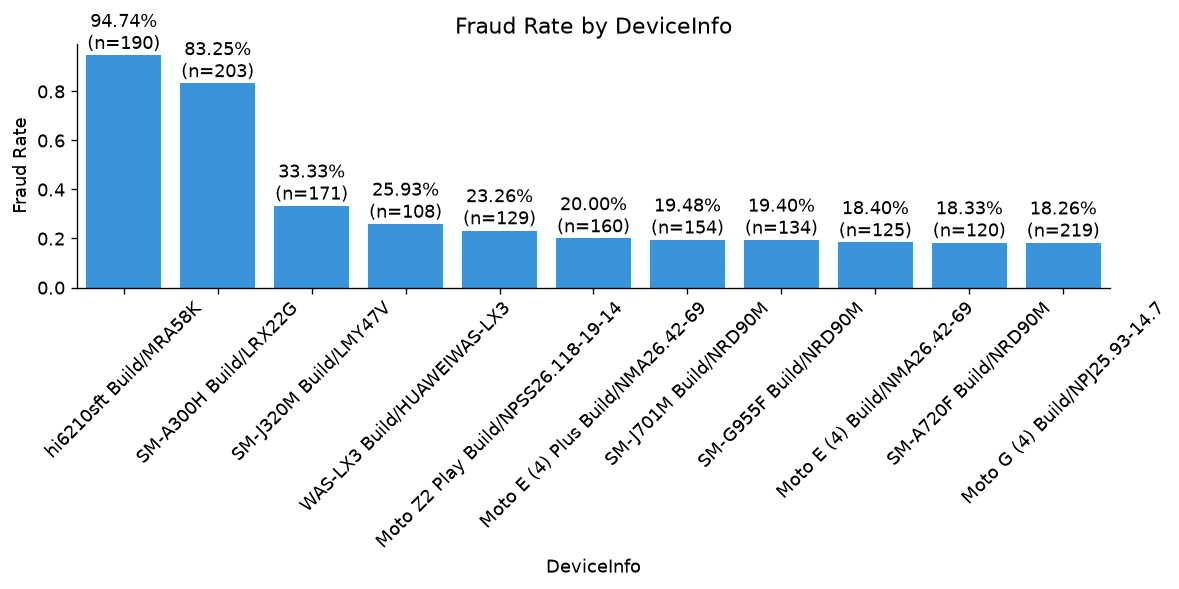

,Transactions,Fraud_Rate,Fraud_Count
DeviceInfo,,,
hi6210sft Build/MRA58K,190,0.947368,180
SM-A300H Build/LRX22G,203,0.832512,169
SM-J320M Build/LMY47V,171,0.333333,57
WAS-LX3 Build/HUAWEIWAS-LX3,108,0.259259,28
Moto Z2 Play Build/NPSS26.118-19-14,129,0.232558,30
Moto E (4) Plus Build/NMA26.42-69,160,0.200000,32
SM-J701M Build/NRD90M,154,0.194805,30
SM-G955F Build/NRD90M,134,0.194030,26
Moto E (4) Build/NMA26.42-69,125,0.184000,23


In [55]:
# Fraud Rate of DeviceInfo
plot_fraud_rate(df, "DeviceInfo", top=11)

In [56]:
# stats
deviceinfo_df = df[['DeviceInfo']]
deviceinfo_fraud_df = df[['DeviceInfo']][df["isFraud"] == 1]
deviceinfo_nonfraud_df = df[['DeviceInfo']][df["isFraud"] == 0]

summary_table = stat_describe(
    column="DeviceInfo",
    dataframes=[deviceinfo_df, deviceinfo_fraud_df, deviceinfo_nonfraud_df]
)
display(summary_table)

,Train,Train fraud,Train Not fraud
count,118666,8607,110059
unique,1786,420,1740
top,Windows,Windows,Windows
freq,47722,3121,44601
unique values,1786,420,1740
NaNs,471874,12056,459818
NaNs share,0.799055,0.583458,0.806872


### WOE (Weight of Evidence) + IV (Information Value) and KS Statistics for "known_cols"

In [148]:
def iv_status(df: pd.DataFrame, columns: List[str]):
    for col in columns:
        _, iv = calculate_woe_iv(df, col)
        if iv < 0.02:
            result = "useless"
        elif iv >= 0.02 and iv < 0.1 :
            result = "weak"
        elif iv >= 0.1 and iv < 0.3:
            result = "medium"
        elif iv >= 0.3 and iv < 0.5:
            result = "strong"
        elif iv >= 0.5:
            result = "suspiciously strong (check for leakage)"
        else:
            raise IOError(f"Iv value is not defineable iv= {iv}")
        print(f"{col}: IV = {iv:.4f}, and Status: {result}")

In [149]:
# WOE + IV
iv_status(df, known_cols)

TransactionAmt: IV = 0.1182, and Status: medium
ProductCD: IV = 0.5576, and Status: suspiciously strong (check for leakage)
card1: IV = 0.0585, and Status: weak
card2: IV = 0.0472, and Status: weak
card3: IV = 0.4723, and Status: strong
card4: IV = 0.0125, and Status: useless
card5: IV = 0.0349, and Status: weak
card6: IV = 0.2517, and Status: medium
addr1: IV = 0.0111, and Status: useless
addr2: IV = 0.0107, and Status: useless
dist1: IV = 0.0918, and Status: weak
dist2: IV = 0.0892, and Status: weak
P_emaildomain: IV = 0.1338, and Status: medium
R_emaildomain: IV = 0.5982, and Status: suspiciously strong (check for leakage)
DeviceType: IV = 0.0575, and Status: weak
DeviceInfo: IV = 0.1025, and Status: medium
M1: IV = 0.0004, and Status: useless
M2: IV = 0.0553, and Status: weak
M3: IV = 0.0666, and Status: weak
M4: IV = 0.3425, and Status: strong
M5: IV = 0.0329, and Status: weak
M6: IV = 0.0274, and Status: weak
M7: IV = 0.0023, and Status: useless
M8: IV = 0.0197, and Status: usele

### Data Leakage Audit for "Known_cols"

- **ProductCD** is NOT a data leak. Its high Information Value (IV=0.5576) simply means it is a powerful predictive feature.

- **R_emaildomain** is a Massive Leakage Minefield, several domains have exactly a 0.0% fraud rate, and earlier analysis showed protonmail.com sitting at a 95.12% fraud rate. Leaving it in risks the model simply memorizing these domains as hardcoded rules rather than learning generalizable fraud patterns.

In [133]:
def audit_leakage(df: pd.DataFrame, columns: List[str], volume_threshold: int = 100):
    """
    Definition
    ----------
    This function is used to find the leakage in selected features.
    
    Parameters
    ----------
    - df: DataFrame
    - columns: selected feature for leakage checking
    - volume_threshold=100: Default is 100, it take feature which have 100 transaction is total. 
    """

    confirmed_leaks = []
    
    for col in columns:
        # Bin numeric features to match our IV logic
        if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 20:
            audit_series = pd.qcut(df[col], q=10, duplicates="drop").astype(str)
        else:
            audit_series = df[col].astype(str)
            
        # Calculate fraud rate and volume per bin
        summary = df.groupby(audit_series)['isFraud'].agg(
            Transactions='count', 
            Fraud_Rate='mean'
        )
        
        # Filter out tiny bins to avoid false alarms
        summary = summary[summary['Transactions'] >= volume_threshold]
        
        # Check for perfect or near-perfect separation
        leaks = summary[(summary['Fraud_Rate'] > 0.95) | (summary['Fraud_Rate'] == 0.0)]
        
        if not leaks.empty:
            print(f" 🚨 LEAKAGE DETECTED IN {col}")
            display(leaks)
            confirmed_leaks.append(col)
            
    return confirmed_leaks

In [112]:
df[["ProductCD", "R_emaildomain"]].nunique()

ProductCD         5
R_emaildomain    60
dtype: int64

In [137]:
leaks = audit_leakage(df, ["ProductCD", "R_emaildomain"])
print(f"These features {leaks} have leakage")

 🚨 LEAKAGE DETECTED IN R_emaildomain


,Transactions,Fraud_Rate
R_emaildomain,,
att.net,430,0.0
gmx.de,147,0.0
hotmail.co.uk,105,0.0
hotmail.fr,293,0.0
verizon.net,620,0.0
web.de,237,0.0


These features ['R_emaildomain'] have leakage


## 6. Clustering Redundant features for V1-V399
- we are finding those feature who is highly correlated to each other and creating the cluster of the similary values.
- Then we are selecting which features to keep and which to drop.

In [85]:
v_cols = unknown_cols

In [86]:
# Share missingness pattern group
v_miss_groups = df[v_cols].isnull().sum().value_counts()
print("V-column missingness pattern groups (count of columns sharing each missing-count):")
print(v_miss_groups)

V-column missingness pattern groups (count of columns sharing each missing-count):
460110    46
314       43
12        32
450909    31
76073     23
77096     22
89164     20
450721    19
168969    18
508595    18
508189    18
449124    16
279287    11
508589    11
1269      11
Name: count, dtype: int64


In [ ]:
v_pair_corr = df[v_cols].corr(numeric_only=True).abs()
high_pairs = v_pair_corr.where(np.triu(np.ones(v_pair_corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False) # type: ignore

print("Most redundant V-column pairs:")
most_redundent_df = pd.DataFrame(high_pairs, columns=["correlation"])
most_redundent_df.index.names = ["feature1", "feature2"]
most_redundent_df.head(20)

Most redundant V-column pairs:


,,correlation
feature1,feature2,
V95,V322,0.999949
V96,V323,0.999948
V97,V324,0.999947
V101,V322,0.999698
V279,V322,0.999624
V95,V101,0.999594
V279,V293,0.999568
V280,V324,0.999464
V293,V322,0.999403


In [ ]:
# build a graph connecting any pair with correlation above a threshold
threshold = 0.95
edges = high_pairs[high_pairs > threshold].index.tolist()

G = nx.Graph()
G.add_edges_from(edges)
clusters = list(nx.connected_components(G))

print(f"{len(clusters)} redundant clusters found, covering {sum(len(c) for c in clusters)} columns")

# pick one representative per cluster: the one with the highest correlation to isFraud
v_target_corr = df[v_cols + ["isFraud"]].corr(numeric_only=True)["isFraud"].abs()

representatives = []
dropped = []
for cluster in clusters:
    best = max(cluster, key=lambda c: v_target_corr.get(c, 0))
    representatives.append(best)
    dropped.extend([c for c in cluster if c != best])

print(f"Keep {len(representatives)} representatives, drop {len(dropped)} redundant columns")

38 redundant clusters found, covering 174 columns
Keep 38 representatives, drop 136 redundant columns


In [ ]:
# V - Columns to keep  
print(list(representatives))

['V232', 'V129', 'V43', 'V276', 'V182', 'V99', 'V328', 'V287', 'V52', 'V156', 'V93', 'V277', 'V256', 'V251', 'V150', 'V237', 'V249', 'V244', 'V89', 'V271', 'V191', 'V222', 'V10', 'V48', 'V292', 'V302', 'V69', 'V187', 'V90', 'V29', 'V74', 'V199', 'V158', 'V309', 'V162', 'V81', 'V59', 'V225']


In [ ]:
# V- columns to drop
print(list(dropped))

['V323', 'V280', 'V218', 'V96', 'V306', 'V219', 'V102', 'V318', 'V143', 'V204', 'V97', 'V279', 'V265', 'V298', 'V307', 'V324', 'V95', 'V134', 'V106', 'V231', 'V164', 'V168', 'V233', 'V294', 'V299', 'V316', 'V127', 'V329', 'V212', 'V331', 'V333', 'V128', 'V101', 'V322', 'V295', 'V263', 'V293', 'V211', 'V132', 'V126', 'V213', 'V167', 'V275', 'V202', 'V203', 'V133', 'V217', 'V179', 'V308', 'V177', 'V330', 'V317', 'V103', 'V296', 'V273', 'V178', 'V105', 'V332', 'V269', 'V206', 'V205', 'V266', 'V311', 'V17', 'V21', 'V63', 'V84', 'V42', 'V22', 'V18', 'V214', 'V180', 'V326', 'V285', 'V297', 'V104', 'V100', 'V327', 'V58', 'V94', 'V34', 'V16', 'V57', 'V15', 'V33', 'V51', 'V154', 'V155', 'V149', 'V148', 'V153', 'V92', 'V31', 'V72', 'V71', 'V50', 'V32', 'V278', 'V215', 'V216', 'V255', 'V250', 'V145', 'V151', 'V160', 'V159', 'V144', 'V234', 'V236', 'V254', 'V253', 'V248', 'V242', 'V28', 'V27', 'V272', 'V270', 'V196', 'V221', 'V11', 'V49', 'V291', 'V304', 'V70', 'V193', 'V192', 'V91', 'V30', 'V73',

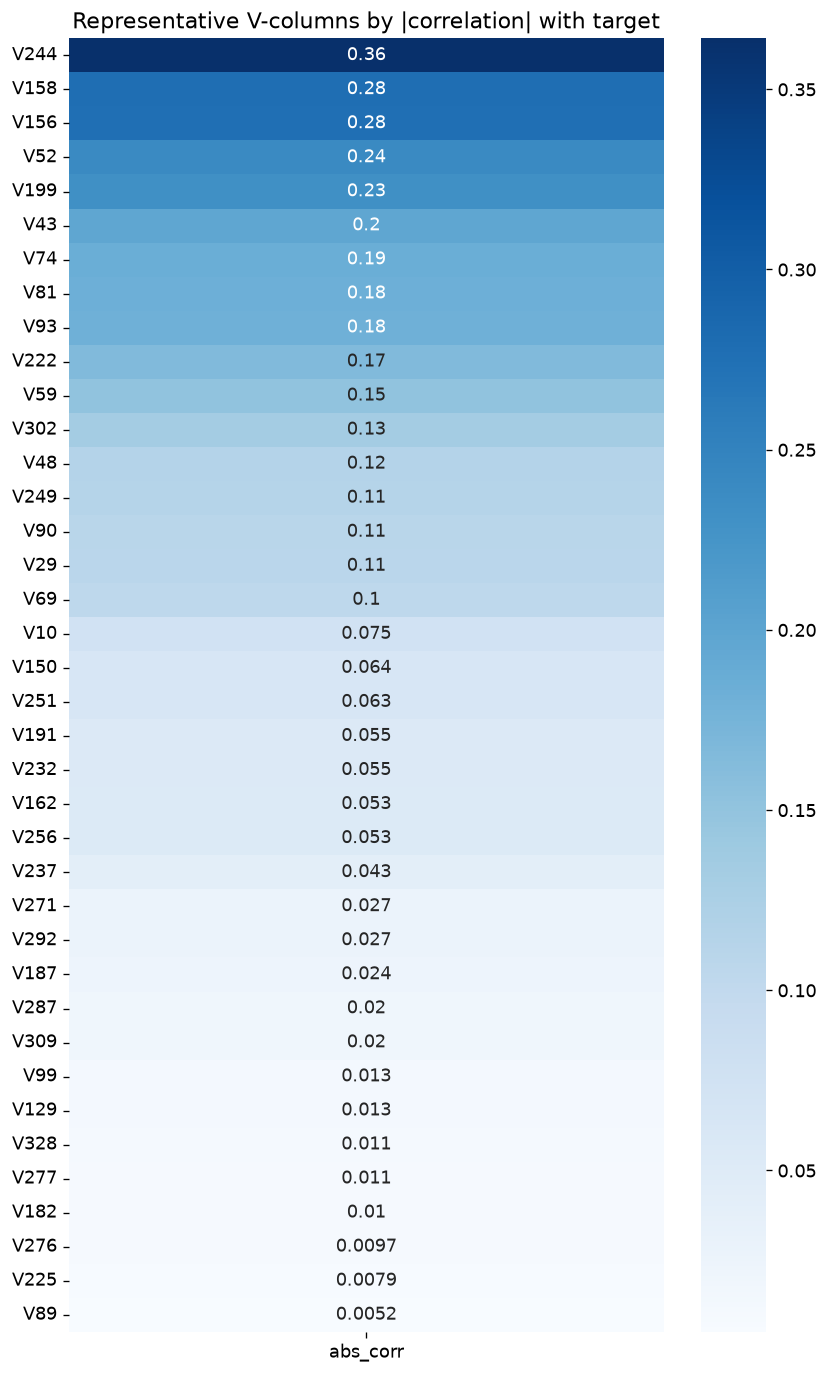

In [ ]:
# heatmap of the representative columns with isFraud
plt.figure(figsize=(8, 14))
representative_corr = df[representatives + ["isFraud"]].corr(numeric_only=True)["isFraud"].drop("isFraud").abs().sort_values(ascending=False)
sns.heatmap(representative_corr.to_frame(name="abs_corr"), annot=True, cmap="Blues", cbar=True)
plt.title("Representative V-columns by |correlation| with target")
plt.show()

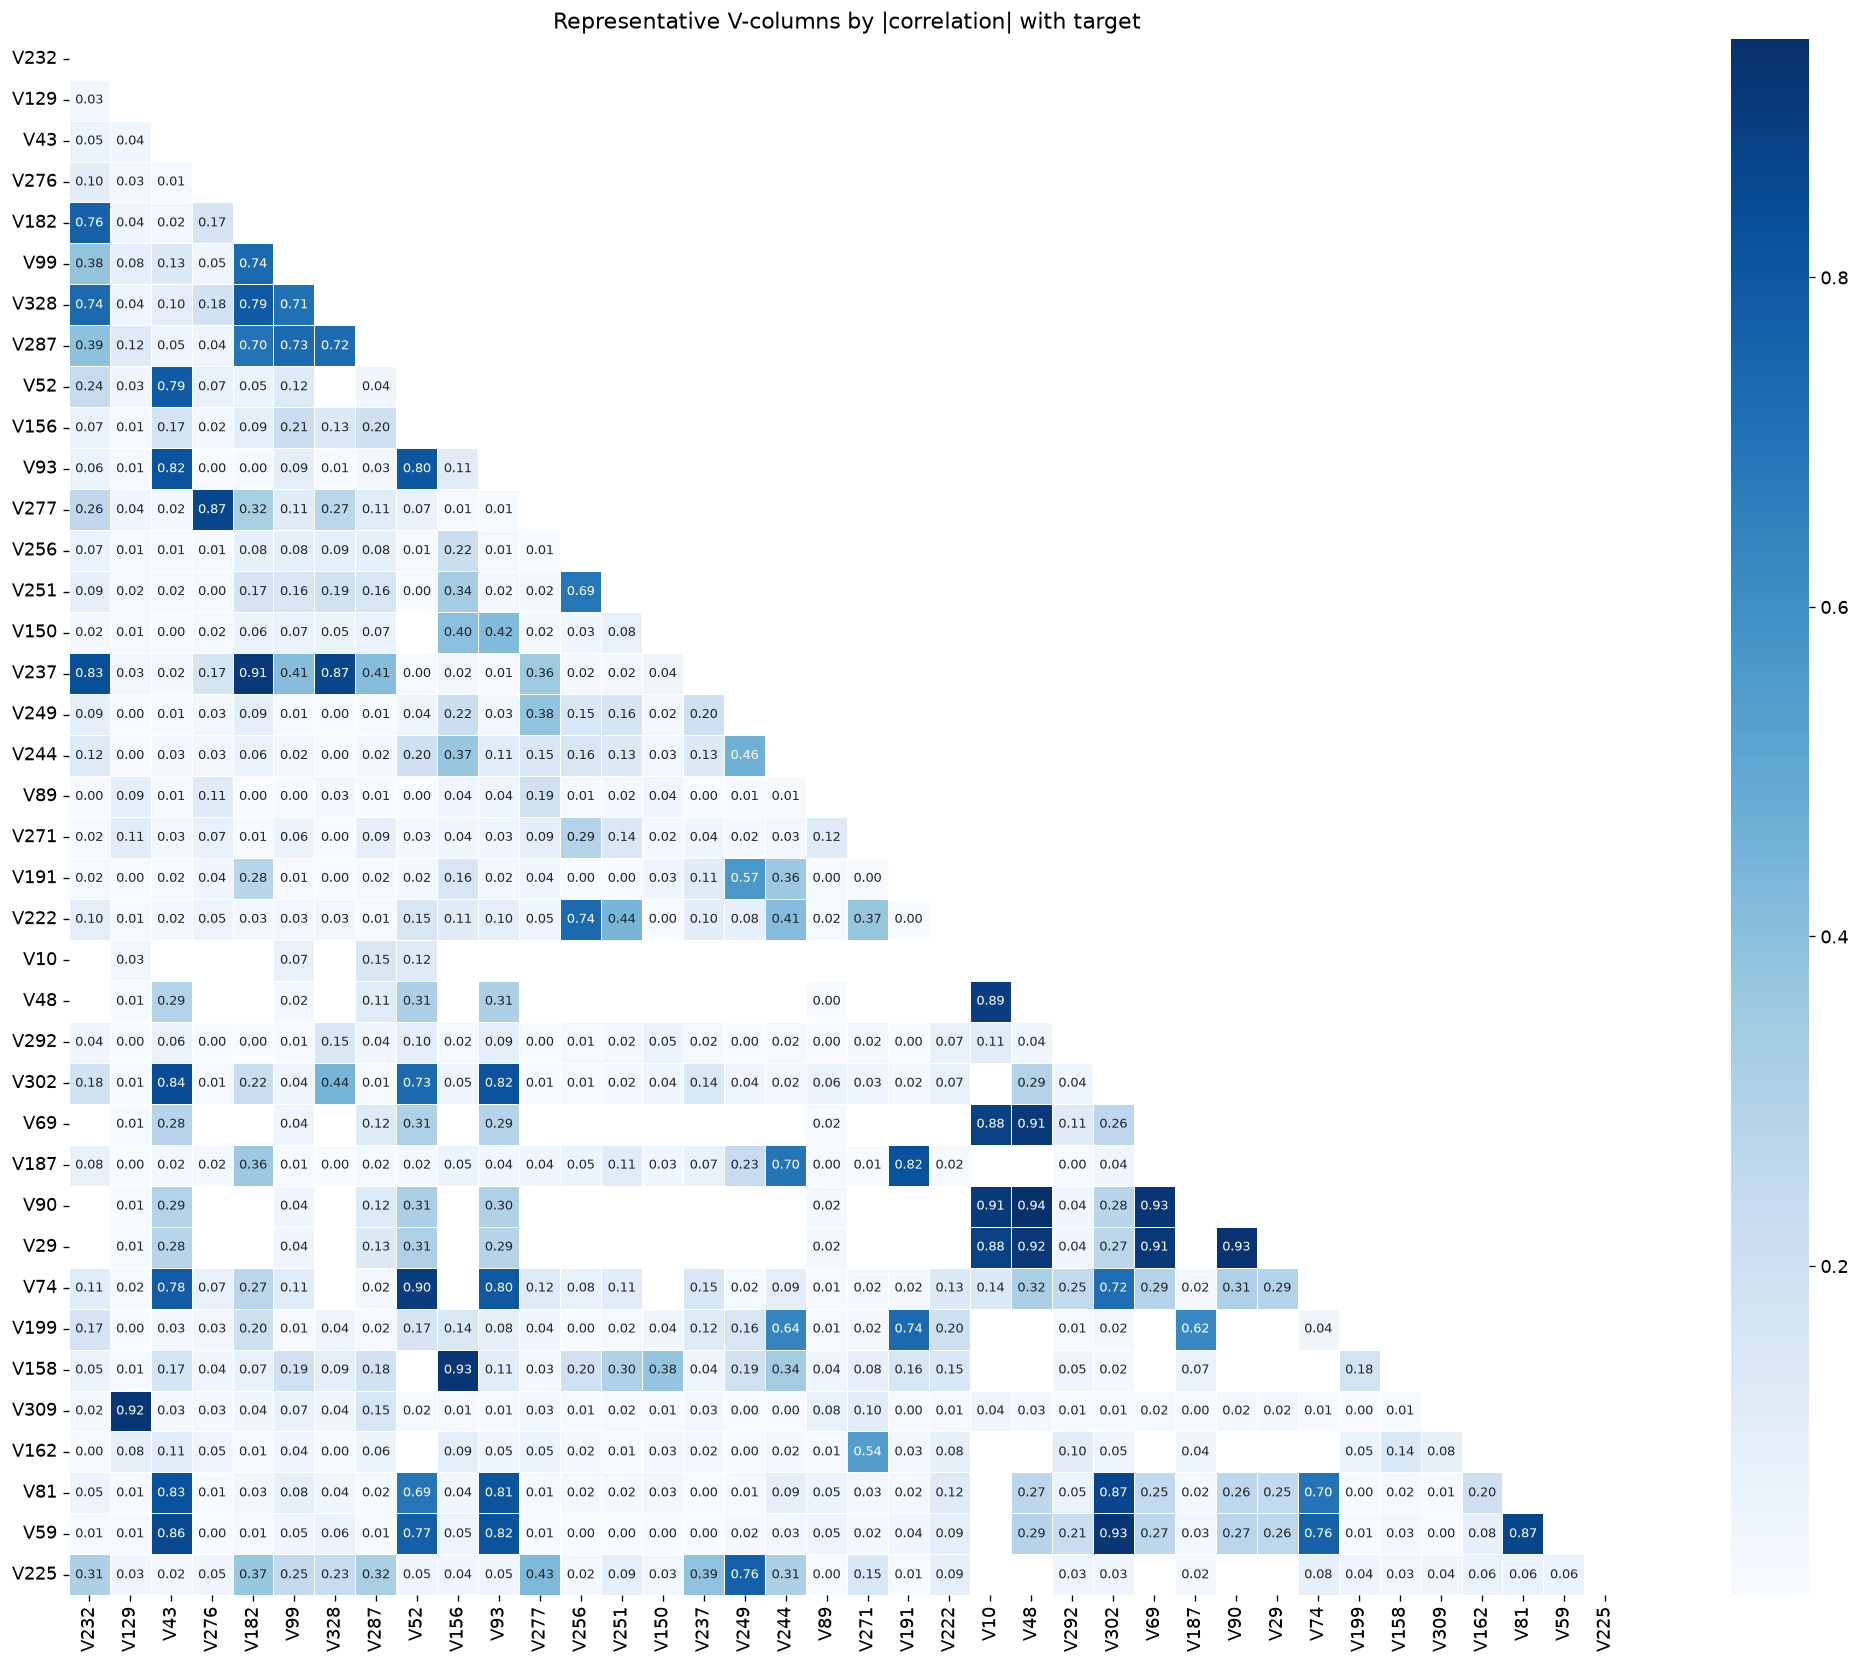

In [ ]:
plt.figure(figsize=(18, 14))
representative_corr_without_isFraud = df[representatives].corr(numeric_only=True).abs()
mask = np.triu(np.ones(representative_corr_without_isFraud.shape, dtype=bool))

sns.heatmap(
    representative_corr_without_isFraud,
    mask=mask,  # Masks upper triangle
    annot=True,  # Keeps numbers
    fmt=".2f",  # Limits decimals to 2 places (e.g. 0.85 instead of 0.849201)
    annot_kws={"size": 8},  # Shrinks font size so numbers fit inside boxes
    cmap="Blues",
    cbar=True,
    square=True,  # Keeps cells perfectly square
    linewidths=0.5,  # Adds clean separation lines between cells
)
plt.title("Representative V-columns by |correlation| with target")
plt.tight_layout()
plt.show()

#### Final V - Features

In [ ]:
untouched = [c for c in v_cols if c not in set(representatives) and c not in set(dropped)]
final_v_cols = representatives + untouched
print(len(final_v_cols))

203


In [ ]:
# V final columns
print(final_v_cols)

['V232', 'V129', 'V43', 'V276', 'V182', 'V99', 'V328', 'V287', 'V52', 'V156', 'V93', 'V277', 'V256', 'V251', 'V150', 'V237', 'V249', 'V244', 'V89', 'V271', 'V191', 'V222', 'V10', 'V48', 'V292', 'V302', 'V69', 'V187', 'V90', 'V29', 'V74', 'V199', 'V158', 'V309', 'V162', 'V81', 'V59', 'V225', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V12', 'V13', 'V14', 'V19', 'V20', 'V23', 'V24', 'V25', 'V26', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V44', 'V45', 'V46', 'V47', 'V53', 'V54', 'V55', 'V56', 'V61', 'V62', 'V64', 'V65', 'V66', 'V67', 'V68', 'V75', 'V76', 'V77', 'V78', 'V79', 'V82', 'V83', 'V85', 'V86', 'V87', 'V88', 'V98', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V130', 'V131', 'V135', 'V136', 'V137', 'V138', 'V139', 'V140', 'V141', 'V142', 'V146', 'V147', 'V152', 'V161', 'V165', 'V166', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V181', '

## 7. Univariate Analysis for C, D, id_, and V_ Features (WOE & IV)

### 🚨 Information Value (IV) & Leakage Audit Results
- **High IV Suspects**: Shifting the analysis to Weight of Evidence (WOE) and Information Value (IV) successfully exposed non-linear relationships. It identified 52 suspiciously strong features with an IV >= 0.5 (e.g., `V258` at 1.459, `V257` at 1.390, and `D5` at 0.881), prompting an automated leakage audit.
- **Confirmed Leakers**: The audit confirmed strict class separation leaks in **`V79`** and **`V93`**. Specifically, bin 7.0 for these features contained exactly 0.0% fraud over substantial transaction volumes. (Note: Previous leakers like `V153` and `V154` were successfully pruned out during the correlation clustering step before reaching this audit).
- **Action Taken**: `V79` and `V93` have been completely dropped from the dataset. Leaving them in would cause severe target leakage, artificially inflating offline metrics while failing entirely in a production environment.

### Top 20 Valid Predictors (IV < 0.5)
Filtering out the 52 leakage suspects isolated the most powerful, mathematically sound signals across the feature families:
- **`C_` Features (Counts)**: `C2`, `C1`, `C11`, `C5`, `C6`
- **`D_` Features (Time Deltas)**: `D7`, `D15`, `D10`, `D4`, `D11`
- **`id_` Features (Identities)**: `id_24`, `id_31`, `id_17`, `id_35`, `id_21`
- **`V_` Features (Vesta Engineered)**: `V59`, `V64`, `V247`, `V195`, `V302`

### Feature Engineering & MLOps Strategy
- **Handling Missingness**: As observed across multiple families, missing values (NaNs) are highly predictive. Instead of standard imputation, numeric NaNs will be filled with an extreme out-of-range value (e.g., -999) so tree-based algorithms can natively split on the missingness.
- **Encoding Categoricals**: One-Hot Encoding will be avoided to prevent dimensionality explosion. High-cardinality features will be processed using Target Encoding (with k-fold regularization) or Frequency Encoding.
- **Pipeline Optimization**: By aggressively clustering and pruning the redundant feature space early on, the dataset is now optimized for the downstream ML pipeline, ensuring faster training times and lower latency for API inference.

In [93]:
# Combine all tier 2 and tier 3 columns into a single list
all_tier2_tier3_cols = unknown_cols_cat + id_cols + final_v_cols

print(f"Total features for combined EDA: {len(all_tier2_tier3_cols)}")

Total features for combined EDA: 270


In [95]:
display(df[all_tier2_tier3_cols].head())

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,V232,V129,V43,V276,V182,V99,V328,V287,V52,V156,V93,V277,V256,V251,V150,V237,V249,V244,V89,V271,V191,V222,V10,V48,V292,V302,V69,V187,V90,V29,V74,V199,V158,V309,V162,V81,V59,V225,V1,V2,V3,V4,V5,V6,V7,V8,V9,V12,V13,V14,V19,V20,V23,V24,V25,V26,V35,V36,V37,V38,V39,V40,V41,V44,V45,V46,V47,V53,V54,V55,V56,V61,V62,V64,V65,V66,V67,V68,V75,V76,V77,V78,V79,V82,V83,V85,V86,V87,V88,V98,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V130,V131,V135,V136,V137,V138,V139,V140,V141,V142,V146,V147,V152,V161,V165,V166,V169,V170,V171,V172,V173,V174,V175,V176,V181,V183,V184,V185,V186,V188,V189,V194,V195,V197,V198,V200,V201,V207,V208,V209,V210,V220,V223,V226,V227,V228,V229,V230,V235,V238,V239,V240,V241,V243,V245,V246,V247,V252,V257,V258,V259,V260,V261,V262,V264,V267,V268,V274,V281,V282,V283,V284,V286,V288,V289,V290,V300,V301,V303,V305,V310,V312,V313,V314,V315,V319,V320,V321,V325,V335,V336,V337,V338,V339
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,1.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.

In [96]:
# Calculate and store IV for all combined columns using your existing function
iv_results = []

for col in all_tier2_tier3_cols:
    # Your calculate_woe_iv function bins the data and returns the IV score
    _, iv = calculate_woe_iv(df, col) 
    iv_results.append({'feature': col, 'IV': iv})

iv_df = pd.DataFrame(iv_results)

# Let's see the top 15 features overall by IV
display(iv_df.sort_values(by='IV', ascending=False).head(15))

,feature,IV
235,V258,1.459571
234,V257,1.390014
76,V156,1.186051
231,V246,1.090537
84,V244,1.035778
98,V199,1.028817
229,V243,1.026844
212,V201,0.939203
206,V189,0.898450
211,V200,0.893974


In [97]:
# Separate features by their prefixes
c_features = [col for col in all_tier2_tier3_cols if col.startswith('C')]
d_features = [col for col in all_tier2_tier3_cols if col.startswith('D')]
id_features = [col for col in all_tier2_tier3_cols if col.startswith('id_')]
v_features = [col for col in all_tier2_tier3_cols if col.startswith('V')]

# Filter out suspiciously strong features (IV >= 0.5)
valid_iv_df = iv_df[iv_df['IV'] < 0.5]

# Get the top 5 valid, highly predictive features from each family
top_c = valid_iv_df[valid_iv_df['feature'].isin(c_features)].sort_values(by='IV', ascending=False).head(5)
top_d = valid_iv_df[valid_iv_df['feature'].isin(d_features)].sort_values(by='IV', ascending=False).head(5)
top_id = valid_iv_df[valid_iv_df['feature'].isin(id_features)].sort_values(by='IV', ascending=False).head(5)
top_v = valid_iv_df[valid_iv_df['feature'].isin(v_features)].sort_values(by='IV', ascending=False).head(5)

# Combine them into a single list for plotting
features_to_plot = pd.concat([top_c, top_d, top_id, top_v])['feature'].tolist()

print(f"Top 20 valid features selected for deep-dive visual EDA:\n{features_to_plot}")

Top 20 valid features selected for deep-dive visual EDA:
['C2', 'C1', 'C11', 'C5', 'C6', 'D7', 'D15', 'D10', 'D4', 'D11', 'id_24', 'id_31', 'id_17', 'id_35', 'id_21', 'V59', 'V64', 'V247', 'V195', 'V302']



Inspecting Feature: C2


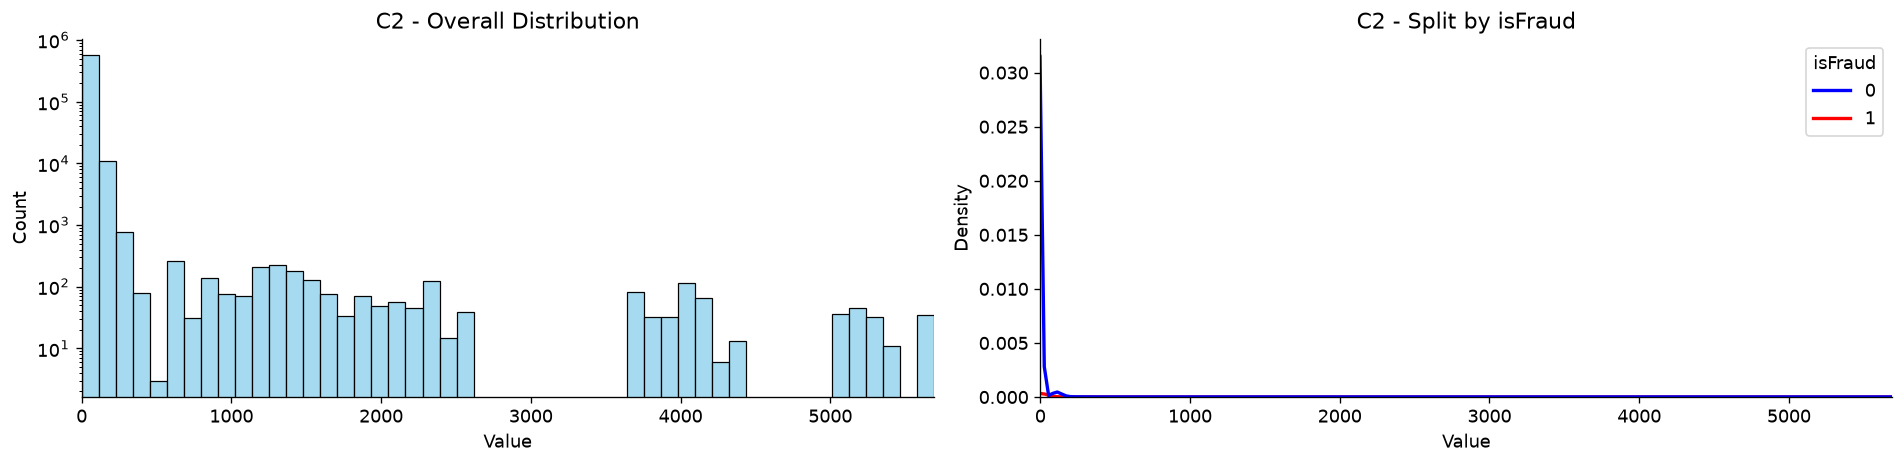

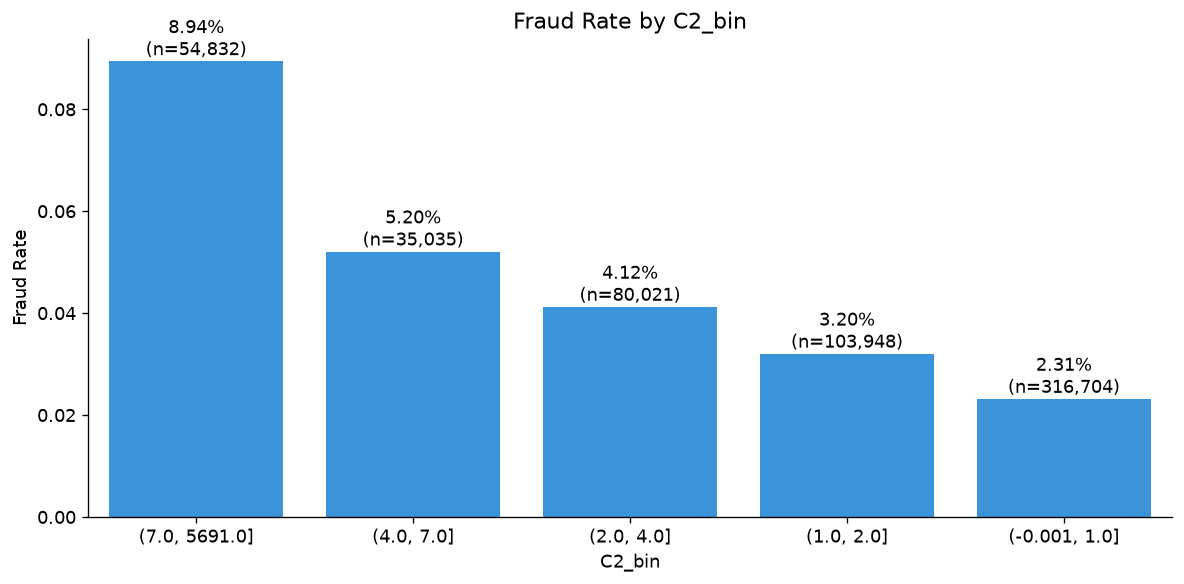

,Transactions,Fraud_Rate,Fraud_Count
C2_bin,,,
"(7.0, 5691.0]",54832,0.089382,4901
"(4.0, 7.0]",35035,0.052034,1823
"(2.0, 4.0]",80021,0.041177,3295
"(1.0, 2.0]",103948,0.031978,3324
"(-0.001, 1.0]",316704,0.023113,7320



Inspecting Feature: C1


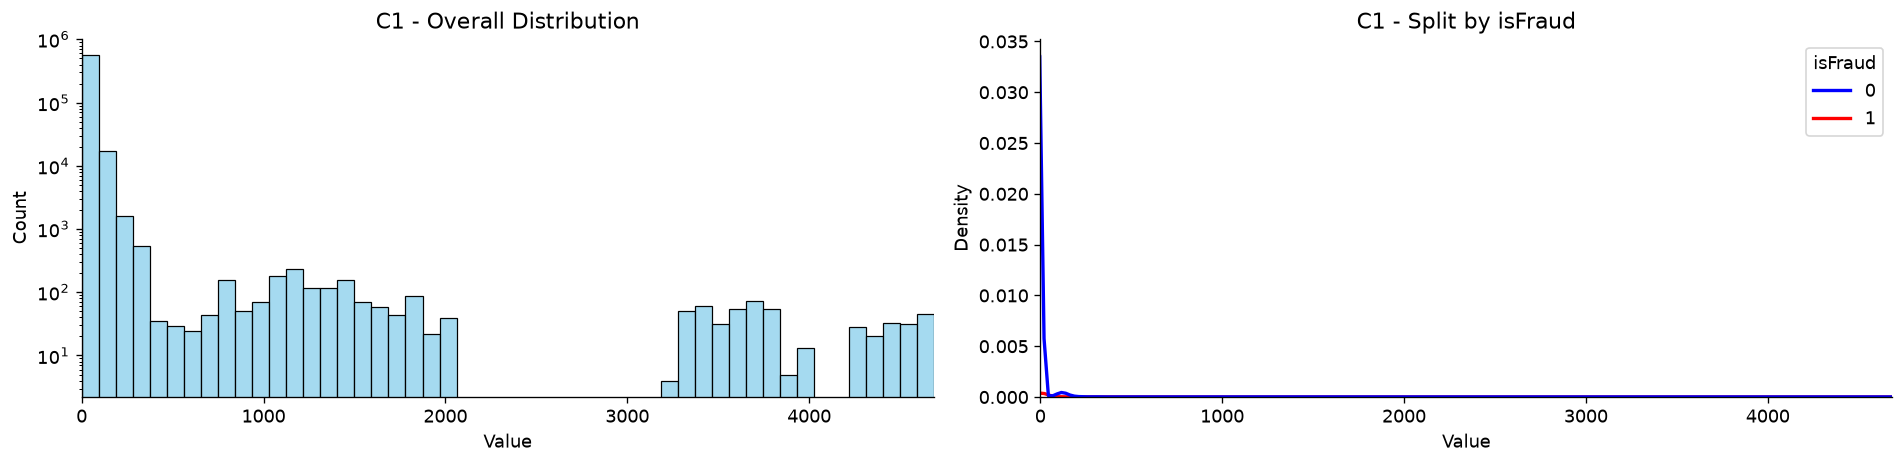

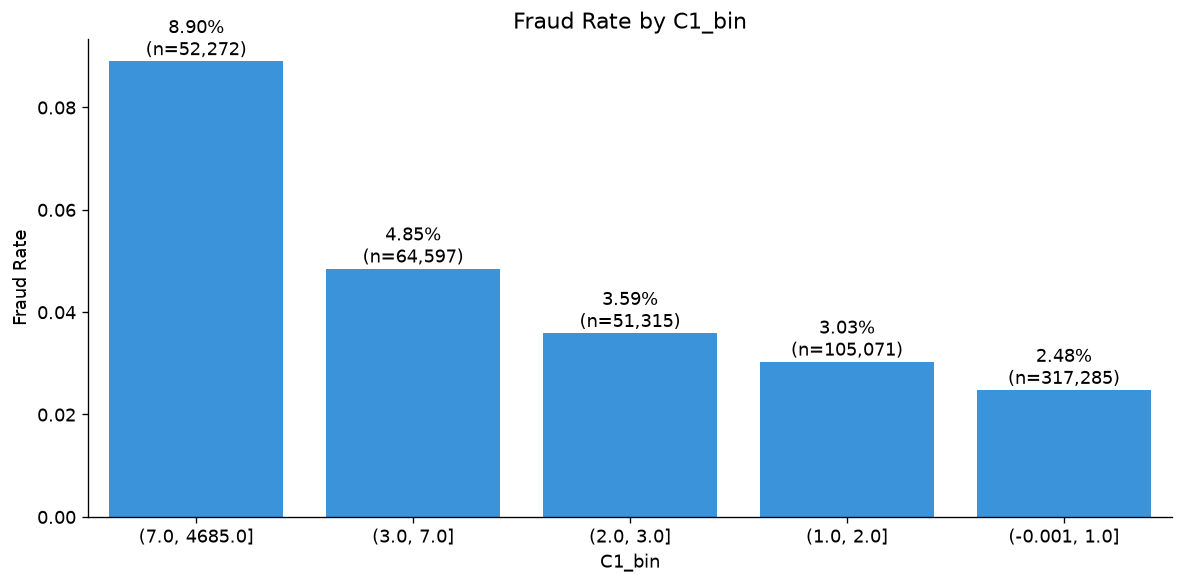

,Transactions,Fraud_Rate,Fraud_Count
C1_bin,,,
"(7.0, 4685.0]",52272,0.088996,4652
"(3.0, 7.0]",64597,0.048485,3132
"(2.0, 3.0]",51315,0.035876,1841
"(1.0, 2.0]",105071,0.030284,3182
"(-0.001, 1.0]",317285,0.024760,7856



Inspecting Feature: C11


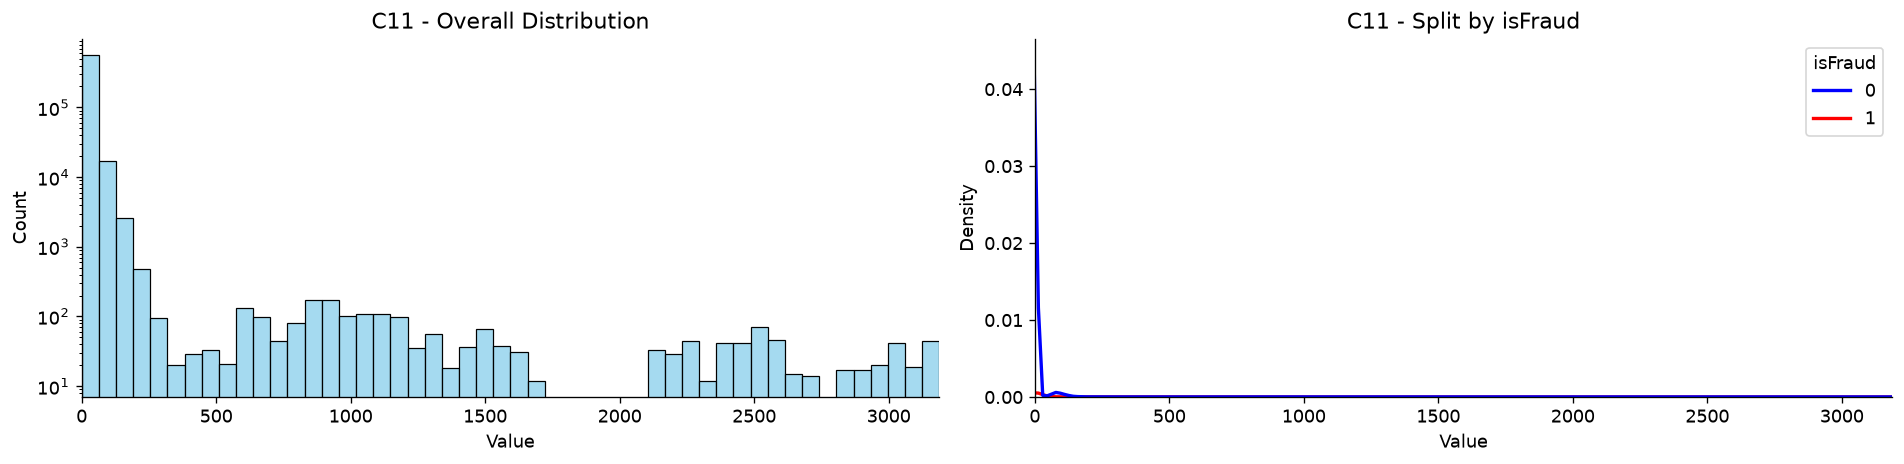

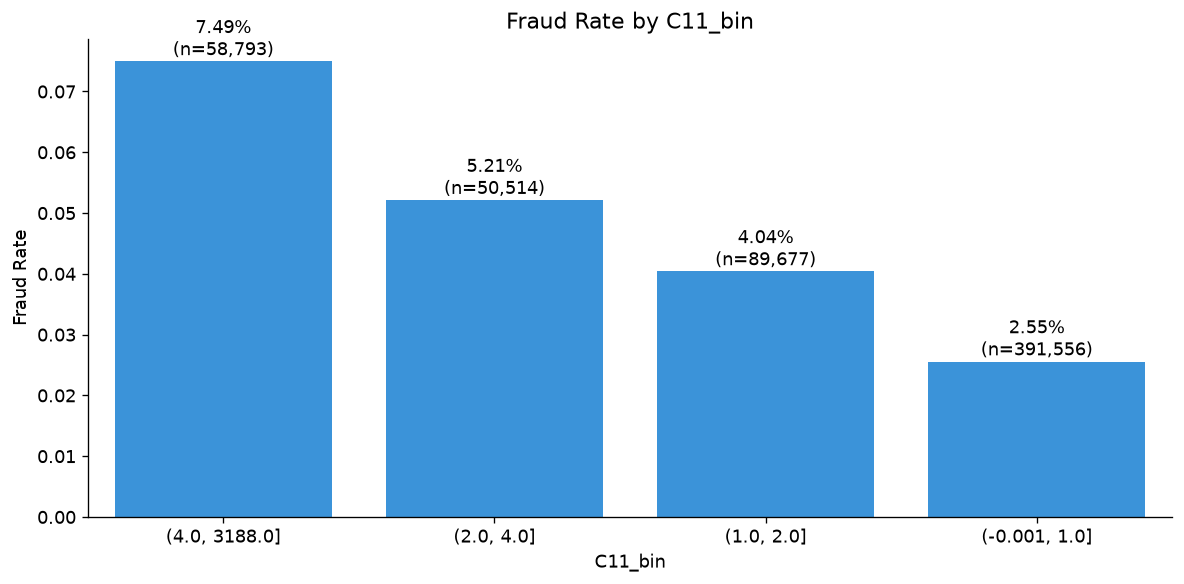

,Transactions,Fraud_Rate,Fraud_Count
C11_bin,,,
"(4.0, 3188.0]",58793,0.074941,4406
"(2.0, 4.0]",50514,0.052104,2632
"(1.0, 2.0]",89677,0.040378,3621
"(-0.001, 1.0]",391556,0.025549,10004



Inspecting Feature: C5


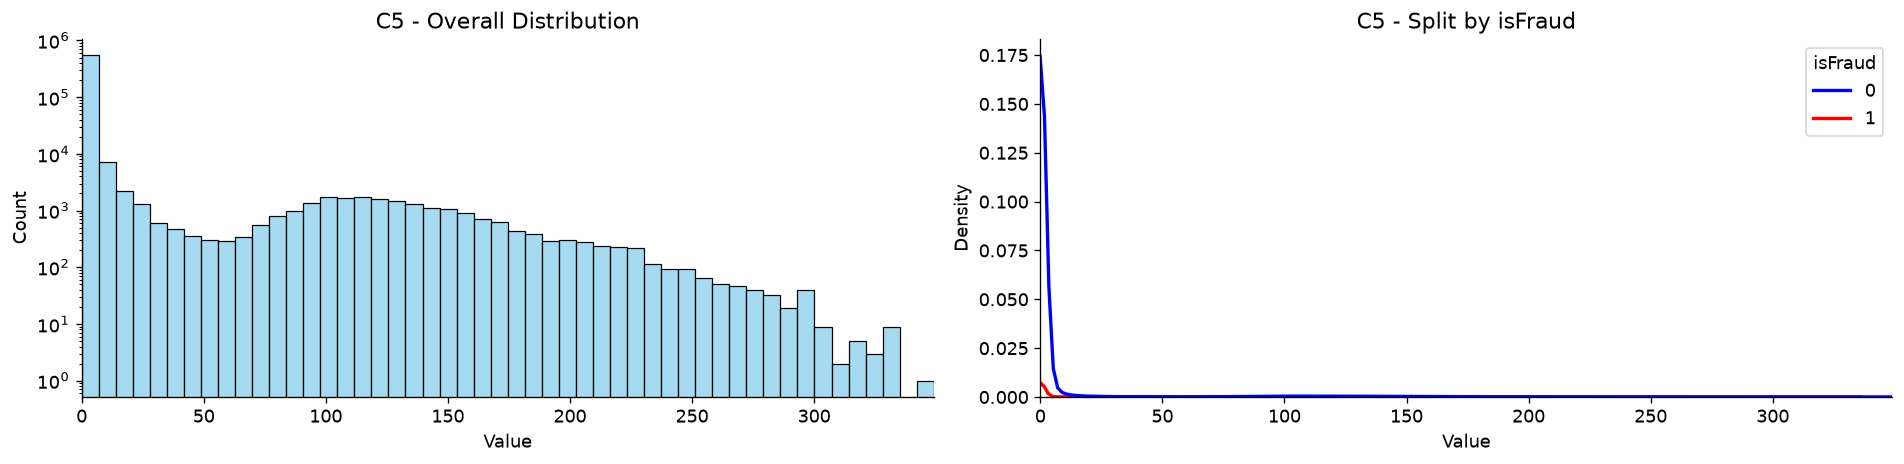

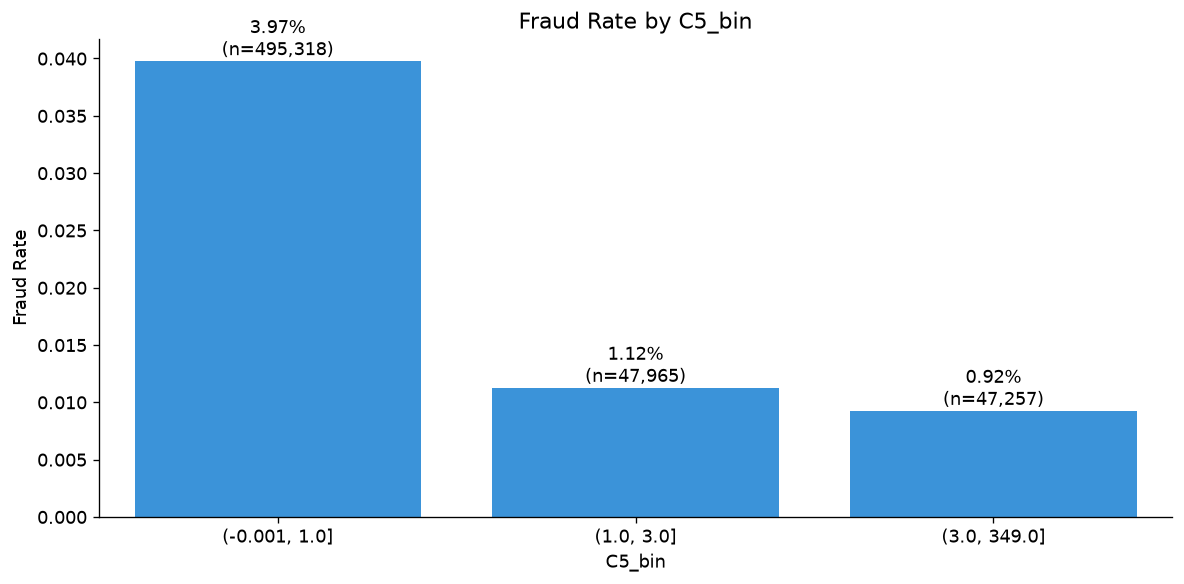

,Transactions,Fraud_Rate,Fraud_Count
C5_bin,,,
"(-0.001, 1.0]",495318,0.039748,19688
"(1.0, 3.0]",47965,0.011237,539
"(3.0, 349.0]",47257,0.009226,436



Inspecting Feature: C6


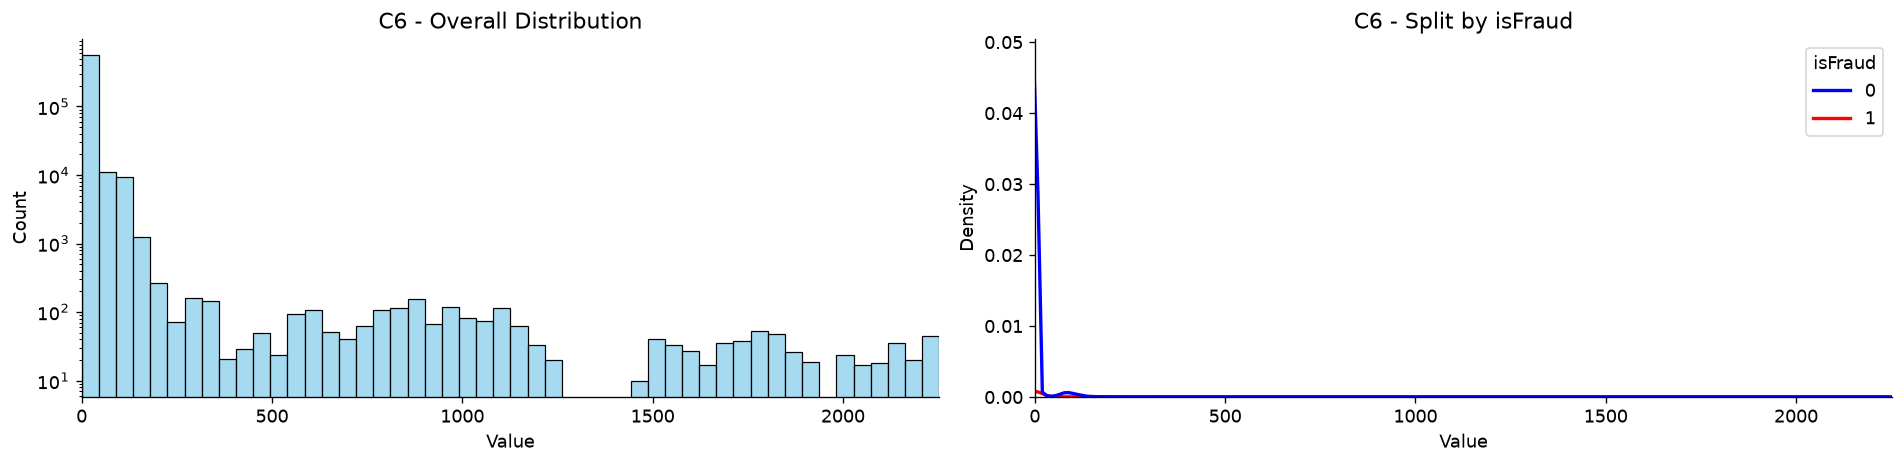

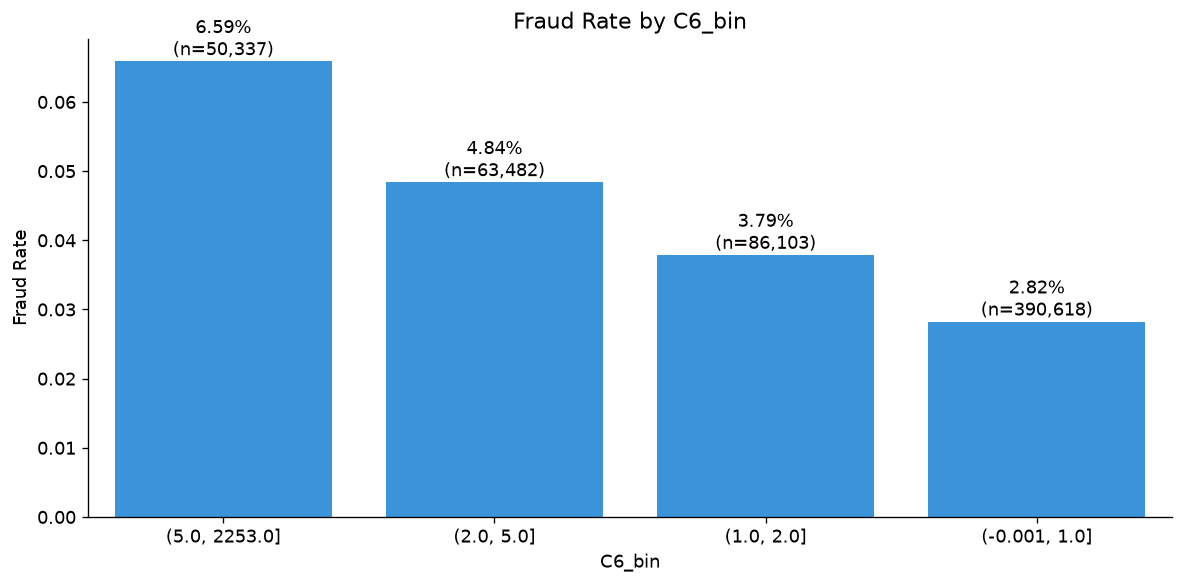

,Transactions,Fraud_Rate,Fraud_Count
C6_bin,,,
"(5.0, 2253.0]",50337,0.065856,3315
"(2.0, 5.0]",63482,0.048360,3070
"(1.0, 2.0]",86103,0.037850,3259
"(-0.001, 1.0]",390618,0.028209,11019



Inspecting Feature: D7


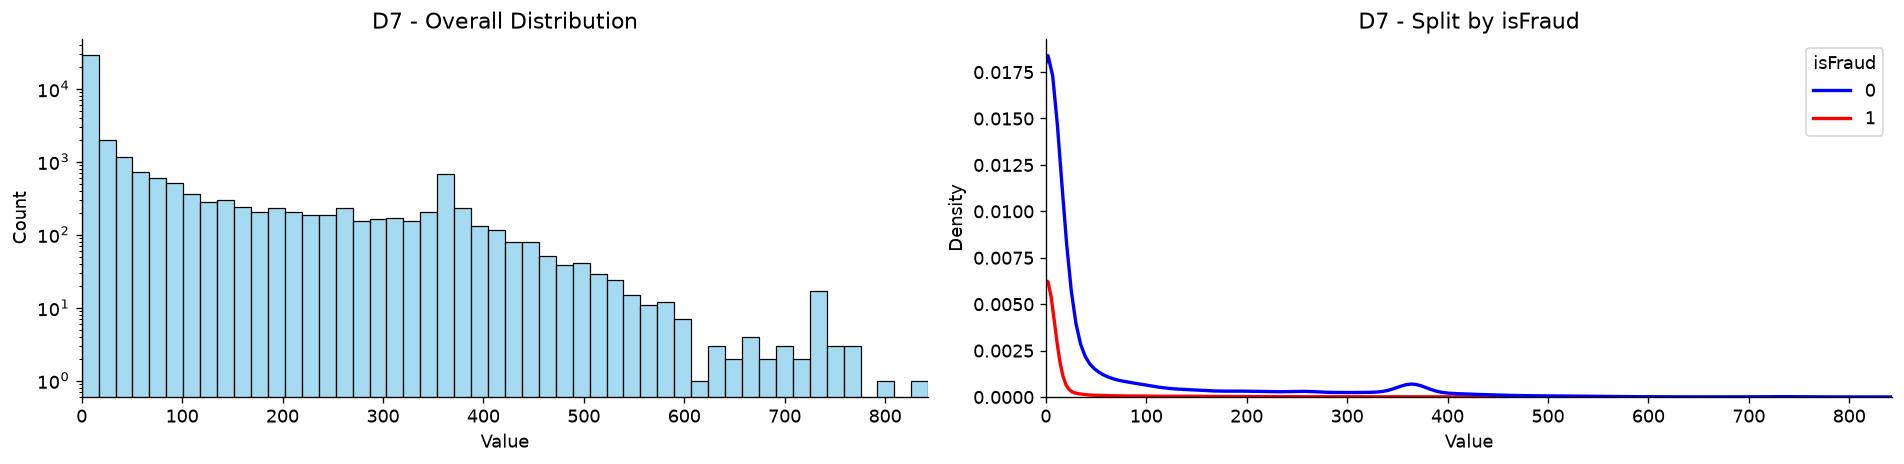

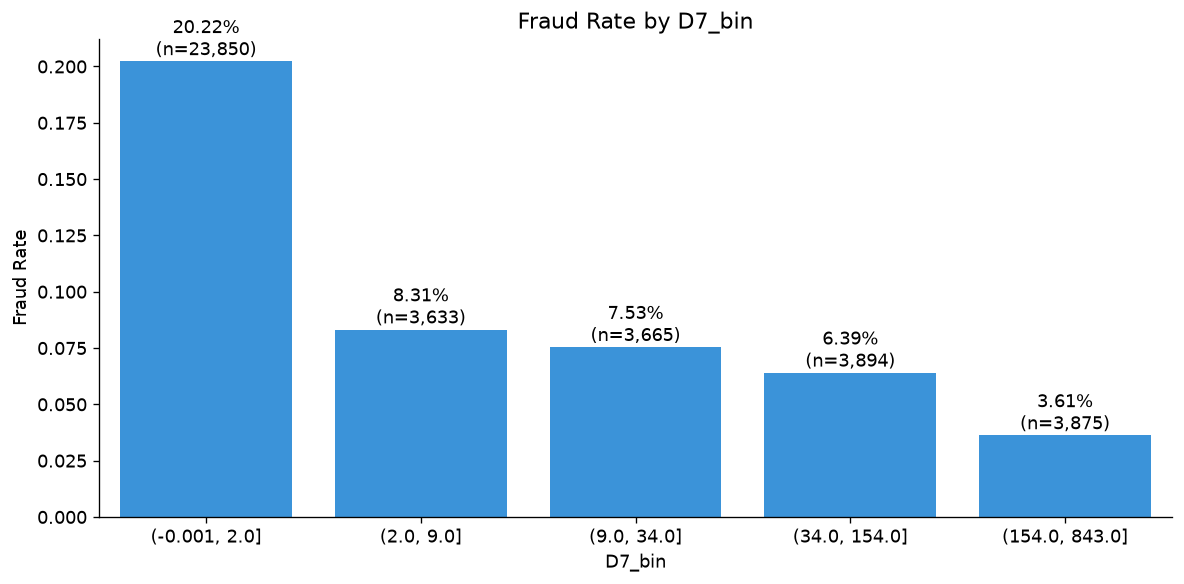

,Transactions,Fraud_Rate,Fraud_Count
D7_bin,,,
"(-0.001, 2.0]",23850,0.202222,4823
"(2.0, 9.0]",3633,0.083127,302
"(9.0, 34.0]",3665,0.075307,276
"(34.0, 154.0]",3894,0.063945,249
"(154.0, 843.0]",3875,0.036129,140



Inspecting Feature: D15


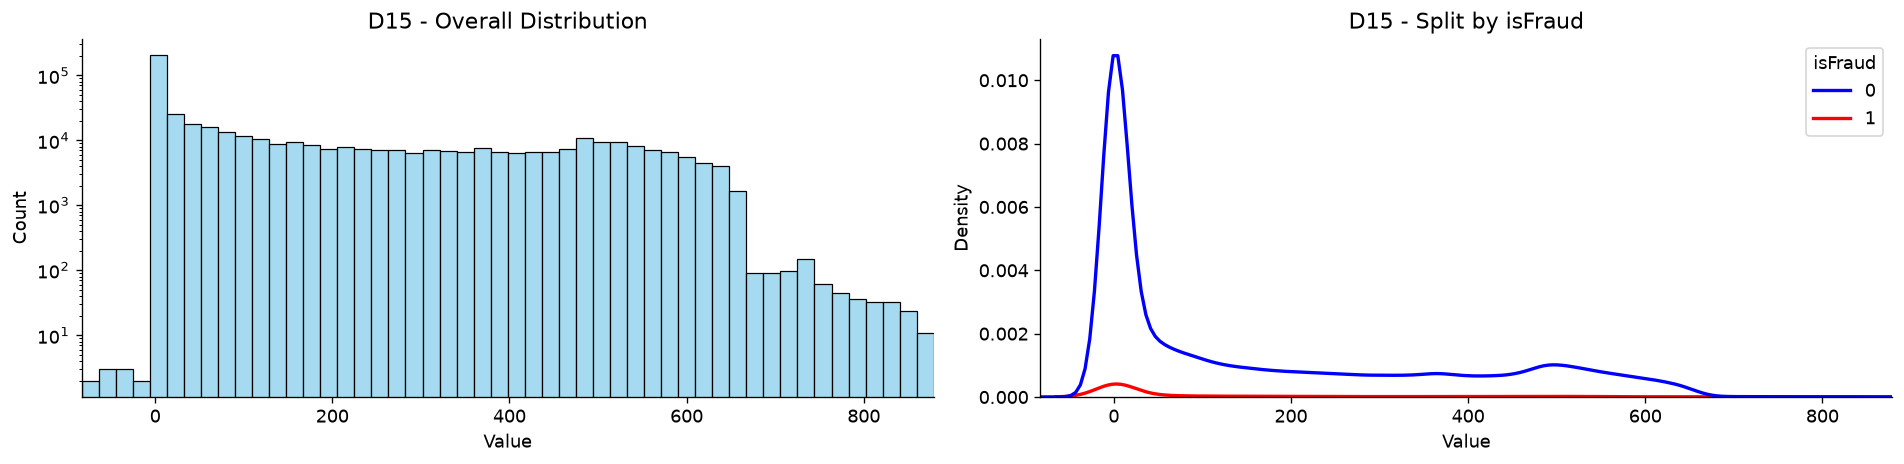

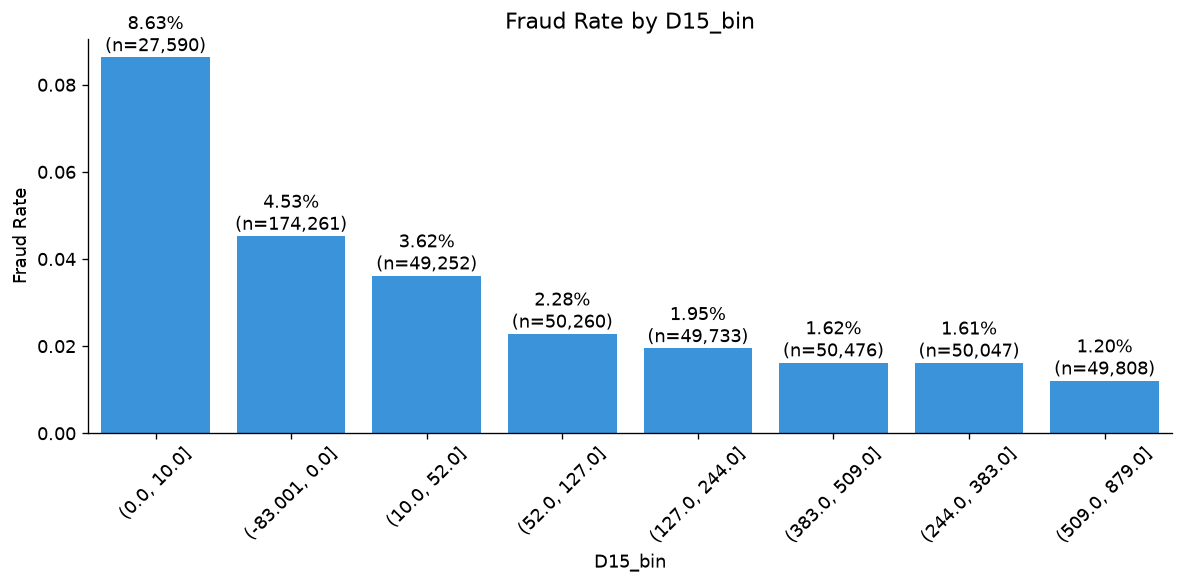

,Transactions,Fraud_Rate,Fraud_Count
D15_bin,,,
"(0.0, 10.0]",27590,0.086263,2380
"(-83.001, 0.0]",174261,0.045254,7886
"(10.0, 52.0]",49252,0.036161,1781
"(52.0, 127.0]",50260,0.022801,1146
"(127.0, 244.0]",49733,0.019464,968
"(383.0, 509.0]",50476,0.016206,818
"(244.0, 383.0]",50047,0.016145,808
"(509.0, 879.0]",49808,0.012046,600



Inspecting Feature: D10


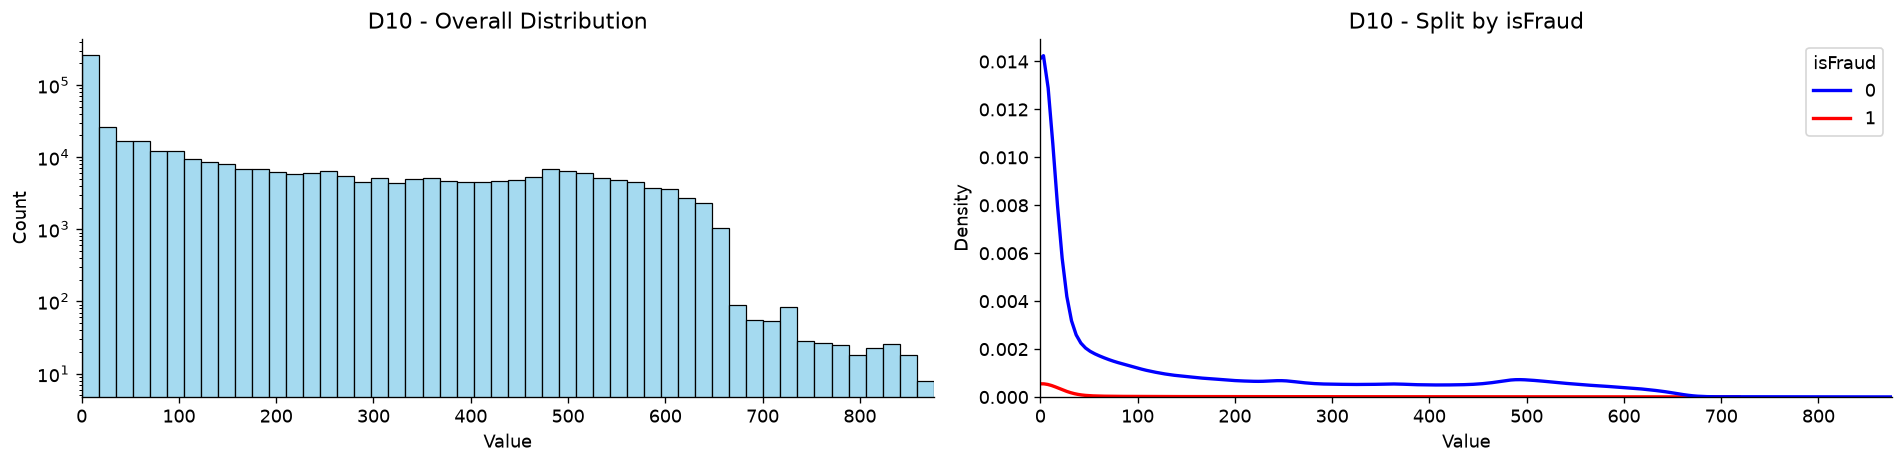

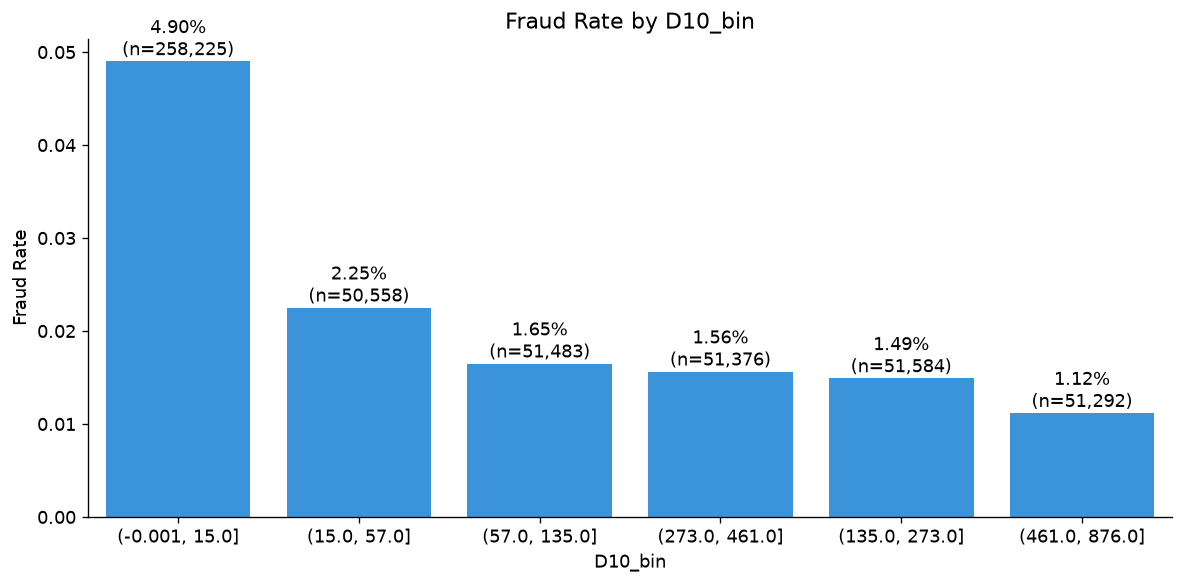

,Transactions,Fraud_Rate,Fraud_Count
D10_bin,,,
"(-0.001, 15.0]",258225,0.048988,12650
"(15.0, 57.0]",50558,0.022489,1137
"(57.0, 135.0]",51483,0.016471,848
"(273.0, 461.0]",51376,0.015610,802
"(135.0, 273.0]",51584,0.014888,768
"(461.0, 876.0]",51292,0.011152,572



Inspecting Feature: D4


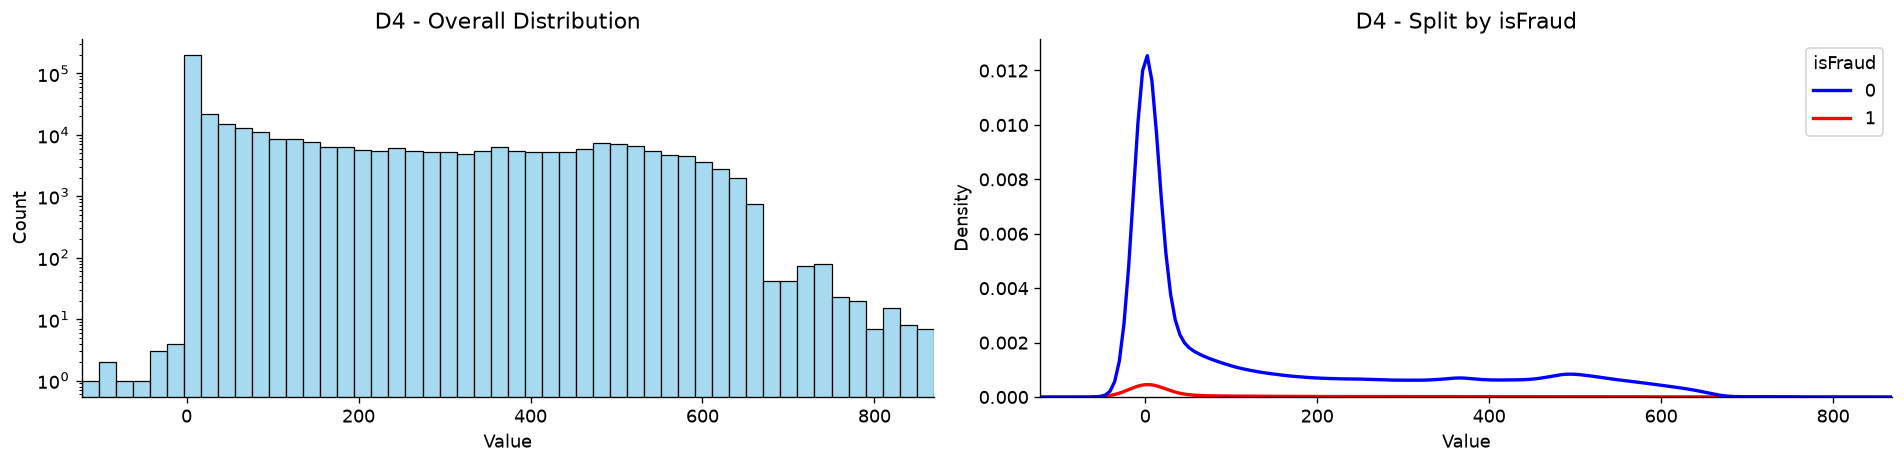

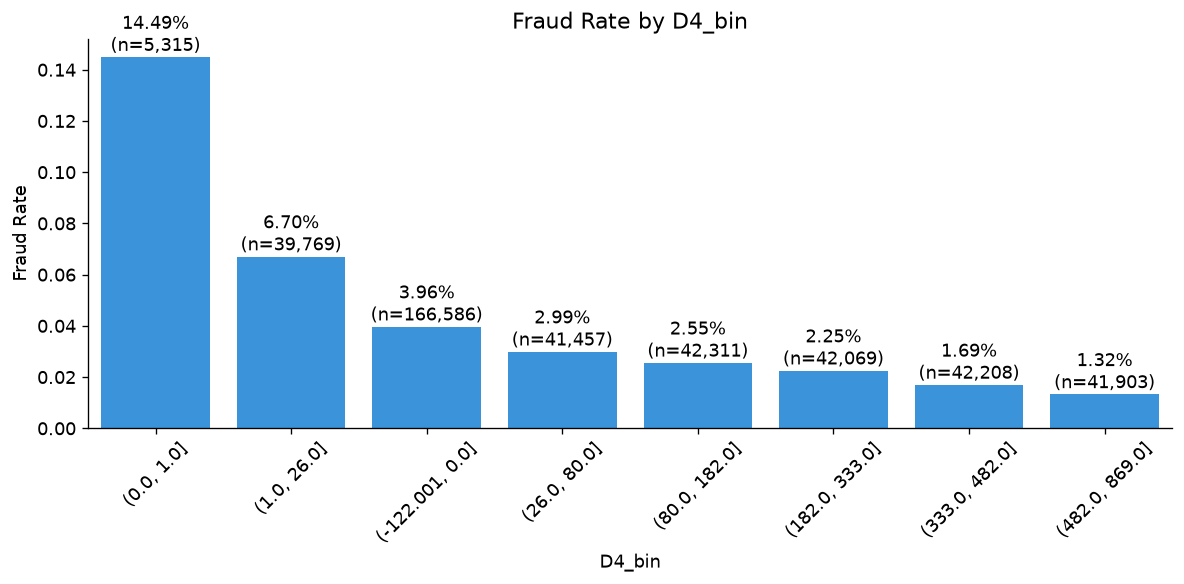

,Transactions,Fraud_Rate,Fraud_Count
D4_bin,,,
"(0.0, 1.0]",5315,0.144873,770
"(1.0, 26.0]",39769,0.067012,2665
"(-122.001, 0.0]",166586,0.039637,6603
"(26.0, 80.0]",41457,0.029862,1238
"(80.0, 182.0]",42311,0.025525,1080
"(182.0, 333.0]",42069,0.022463,945
"(333.0, 482.0]",42208,0.016893,713
"(482.0, 869.0]",41903,0.013197,553



Inspecting Feature: D11


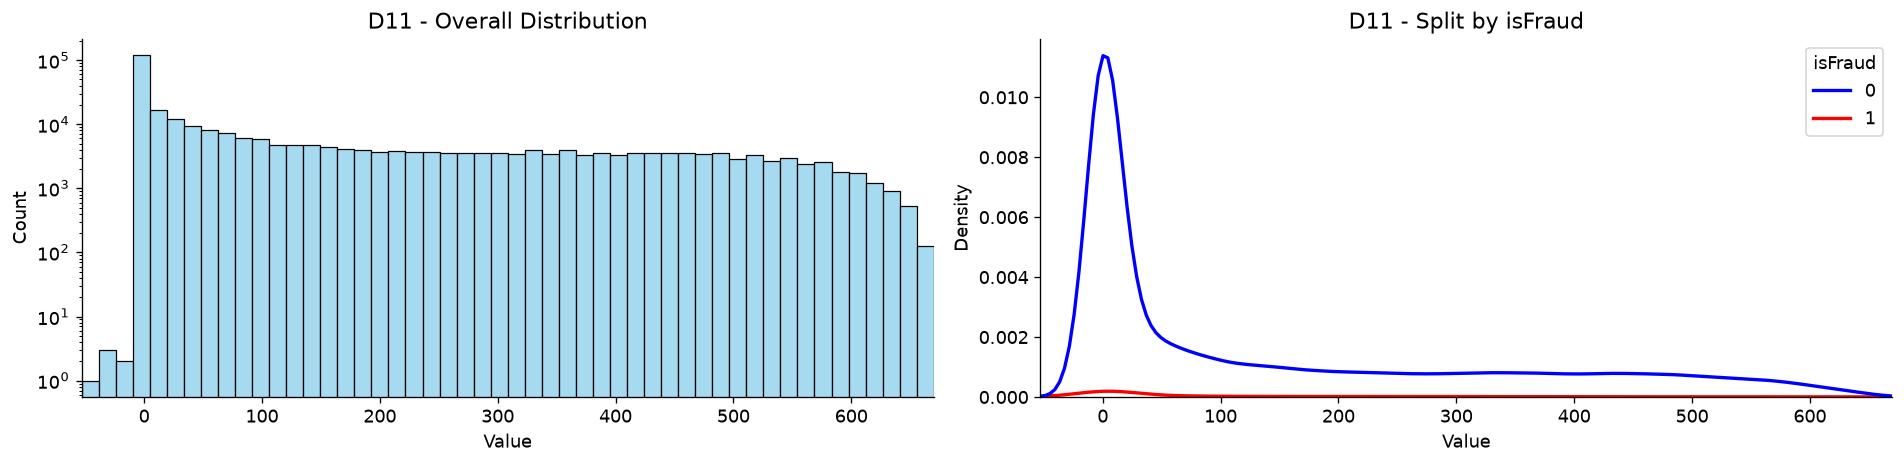

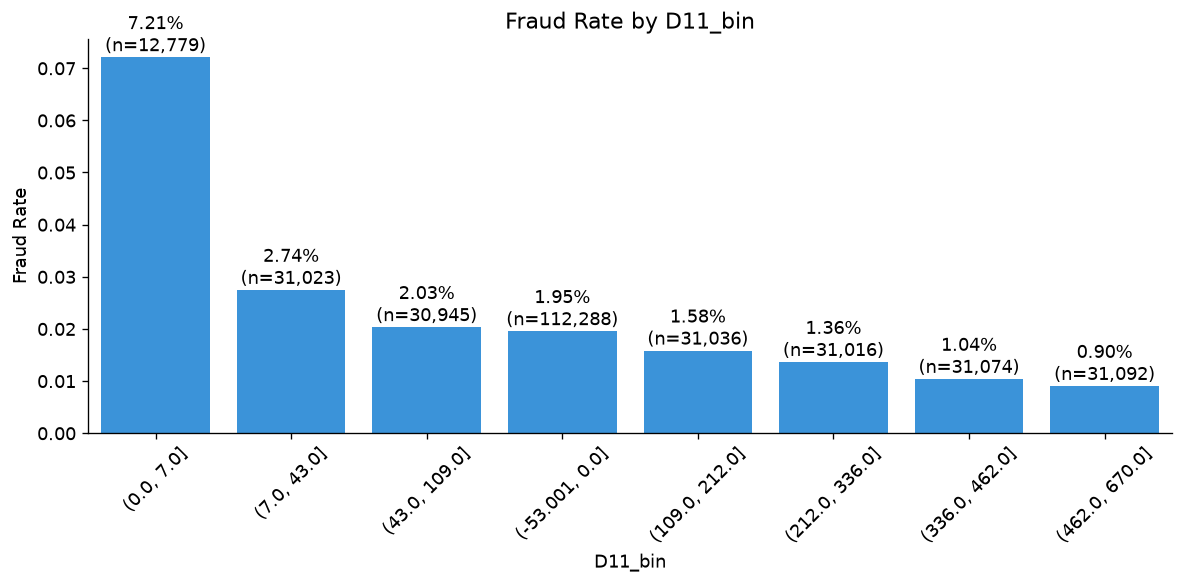

,Transactions,Fraud_Rate,Fraud_Count
D11_bin,,,
"(0.0, 7.0]",12779,0.072071,921
"(7.0, 43.0]",31023,0.027431,851
"(43.0, 109.0]",30945,0.020294,628
"(-53.001, 0.0]",112288,0.019521,2192
"(109.0, 212.0]",31036,0.015788,490
"(212.0, 336.0]",31016,0.013606,422
"(336.0, 462.0]",31074,0.010362,322
"(462.0, 670.0]",31092,0.009006,280



Inspecting Feature: id_24


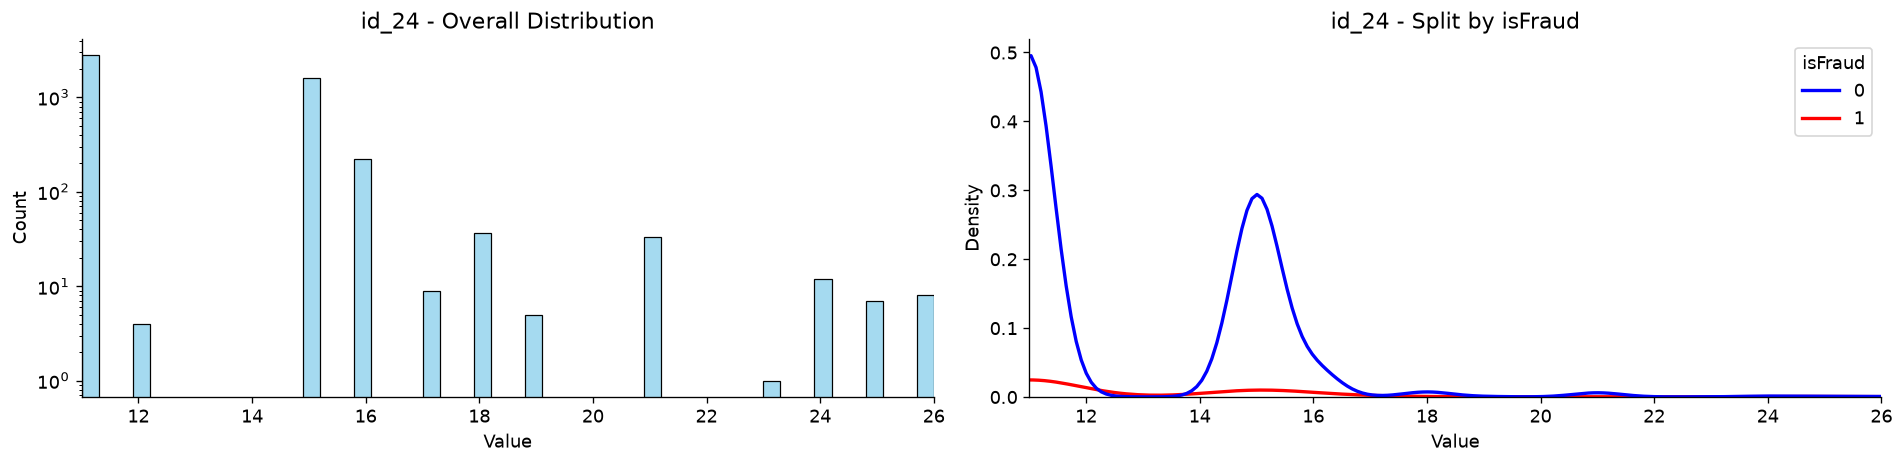

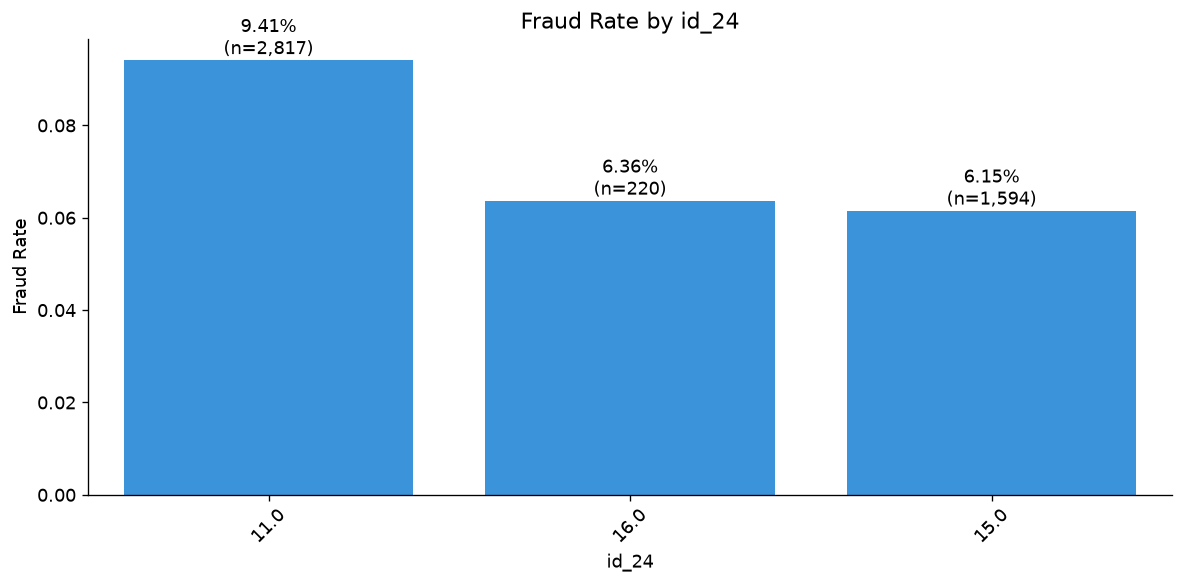

,Transactions,Fraud_Rate,Fraud_Count
id_24,,,
11.0,2817,0.094072,265
16.0,220,0.063636,14
15.0,1594,0.061481,98



Inspecting Feature: id_31
Feature 'id_31' is categorical. Utilizing countplot instead of KDE.


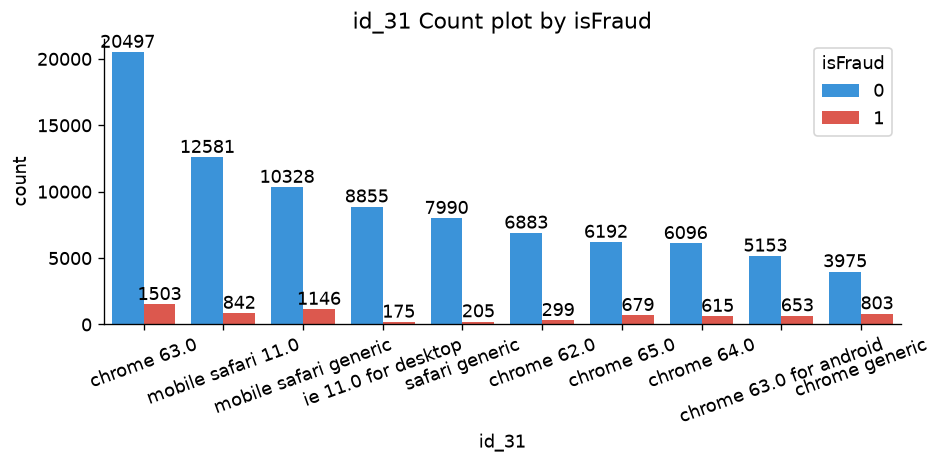

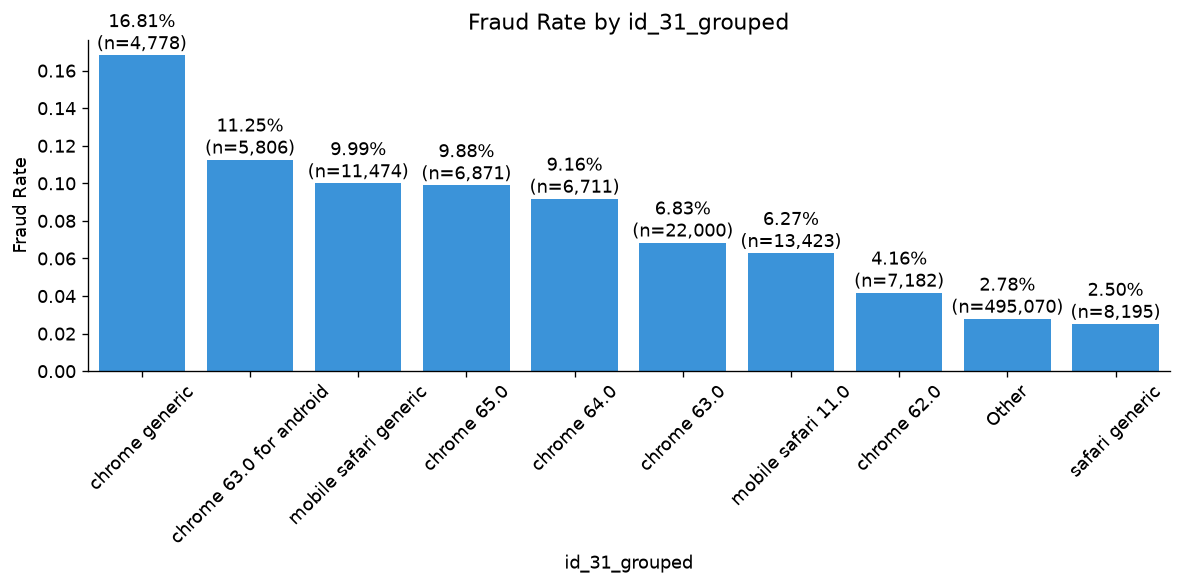

,Transactions,Fraud_Rate,Fraud_Count
id_31_grouped,,,
chrome generic,4778,0.168062,803
chrome 63.0 for android,5806,0.112470,653
mobile safari generic,11474,0.099878,1146
chrome 65.0,6871,0.098821,679
chrome 64.0,6711,0.091641,615
chrome 63.0,22000,0.068318,1503
mobile safari 11.0,13423,0.062728,842
chrome 62.0,7182,0.041632,299
Other,495070,0.027760,13743



Inspecting Feature: id_17


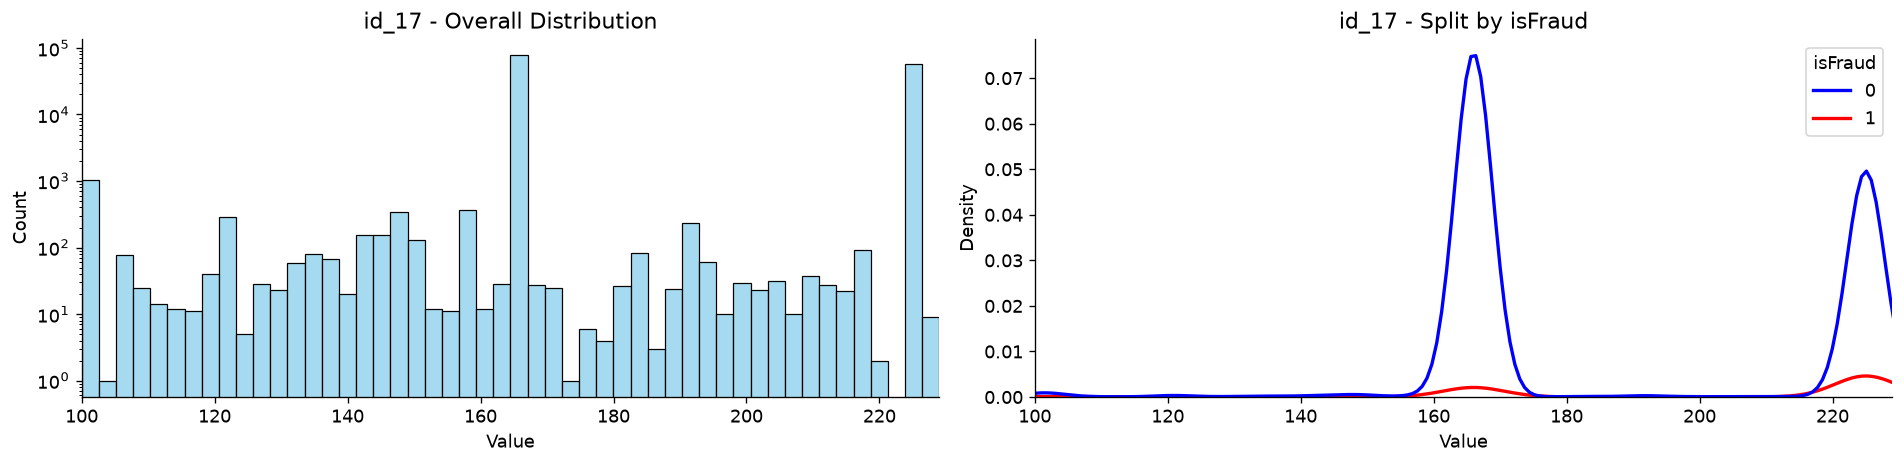

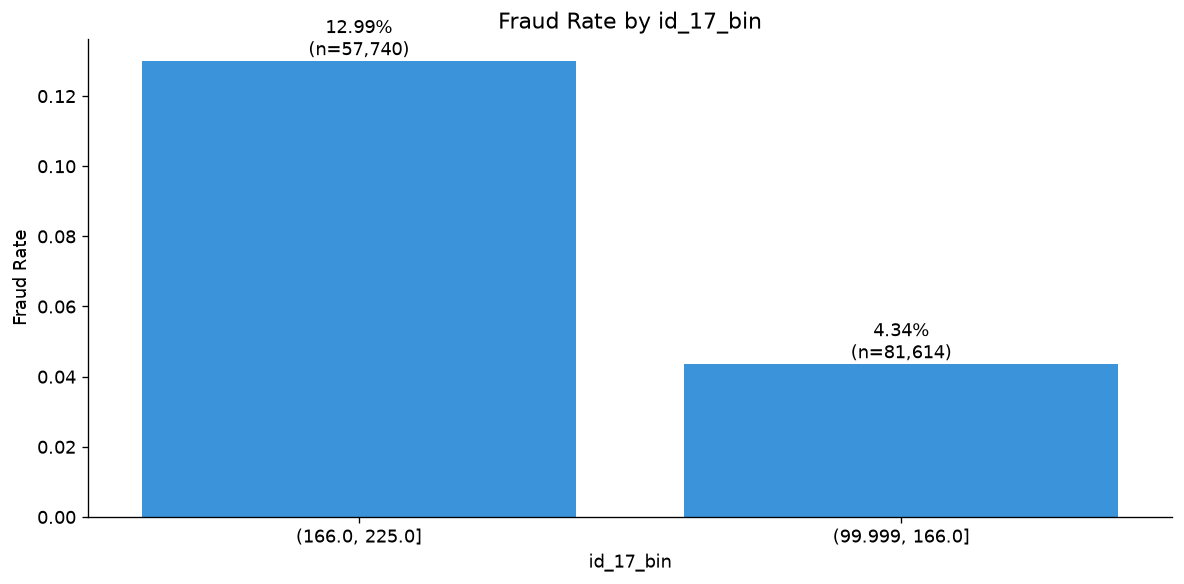

,Transactions,Fraud_Rate,Fraud_Count
id_17_bin,,,
"(166.0, 225.0]",57740,0.129875,7499
"(99.999, 166.0]",81614,0.043448,3546



Inspecting Feature: id_35
Feature 'id_35' is categorical. Utilizing countplot instead of KDE.


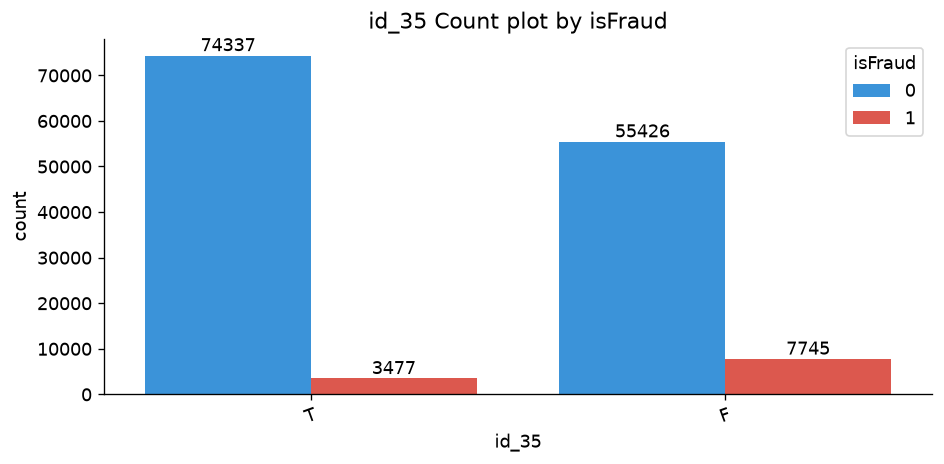

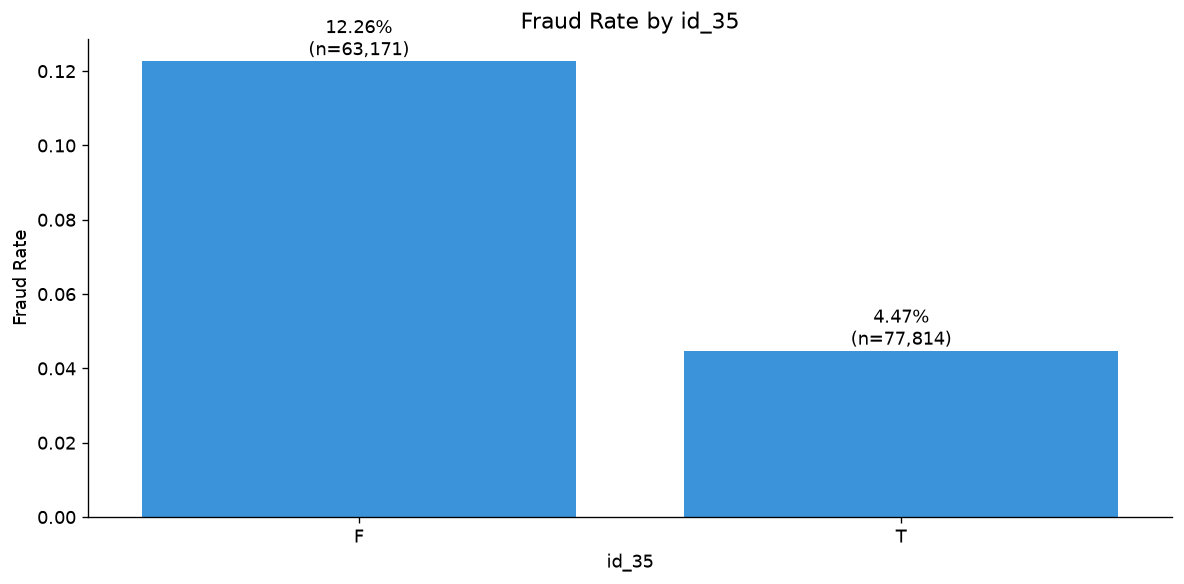

,Transactions,Fraud_Rate,Fraud_Count
id_35,,,
F,63171,0.122604,7745
T,77814,0.044683,3477



Inspecting Feature: id_21


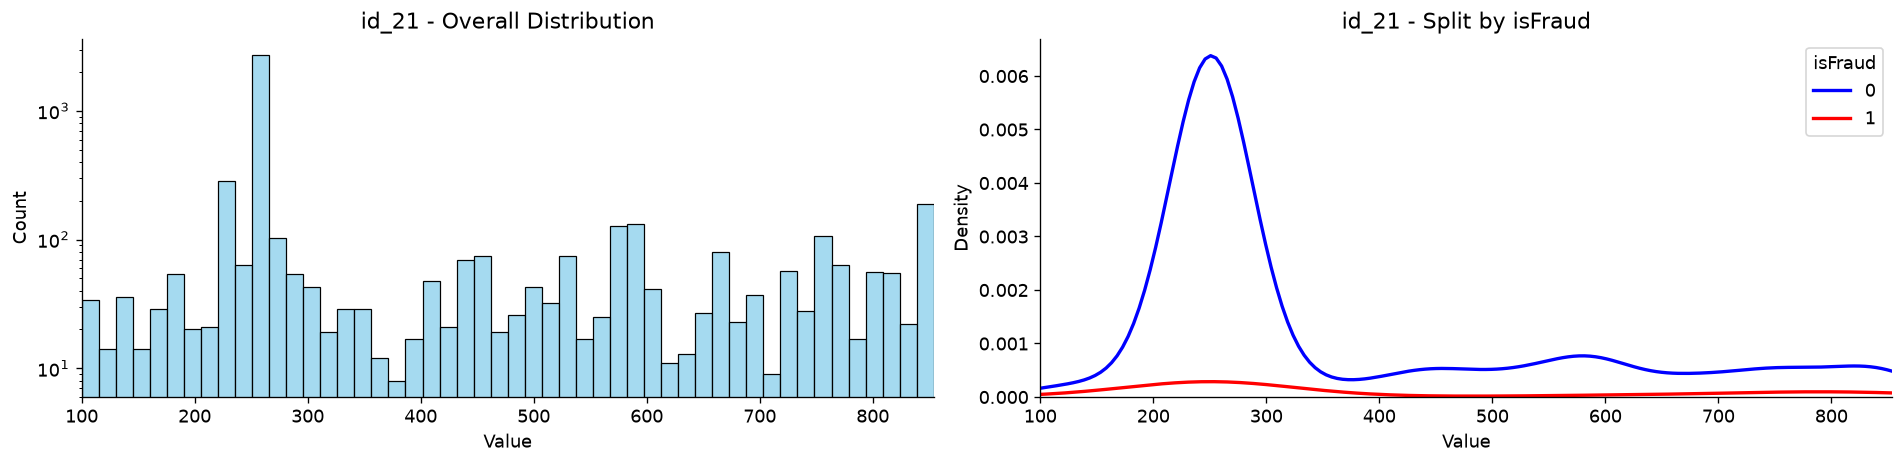

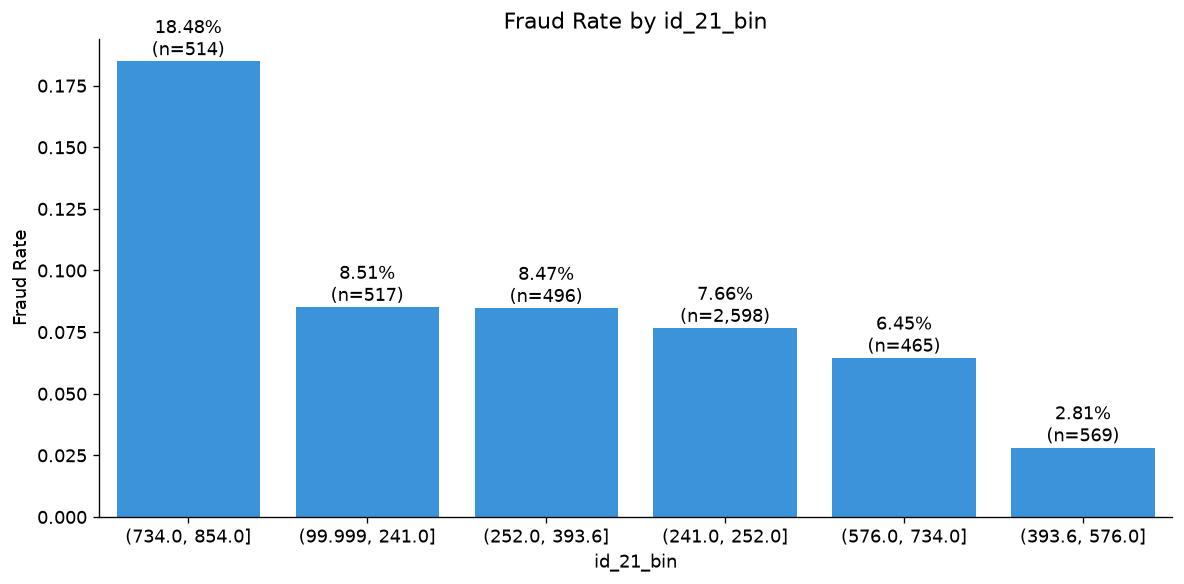

,Transactions,Fraud_Rate,Fraud_Count
id_21_bin,,,
"(734.0, 854.0]",514,0.184825,95
"(99.999, 241.0]",517,0.085106,44
"(252.0, 393.6]",496,0.084677,42
"(241.0, 252.0]",2598,0.076597,199
"(576.0, 734.0]",465,0.064516,30
"(393.6, 576.0]",569,0.028120,16



Inspecting Feature: V59


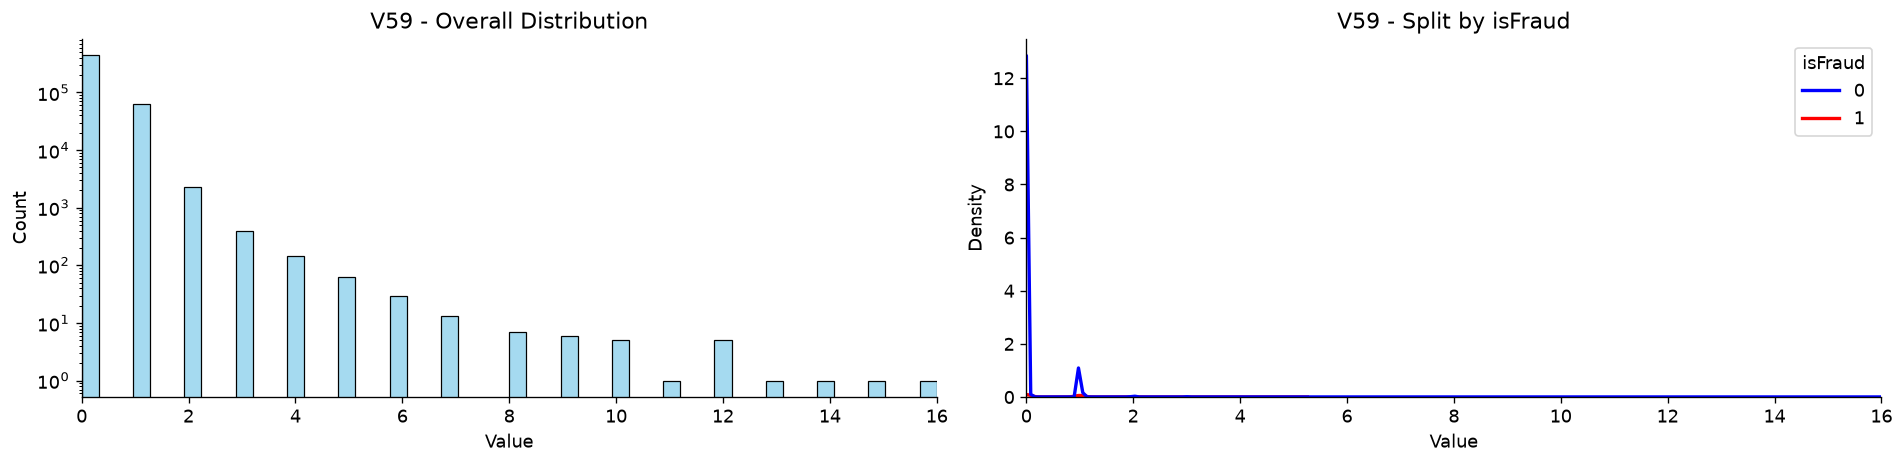

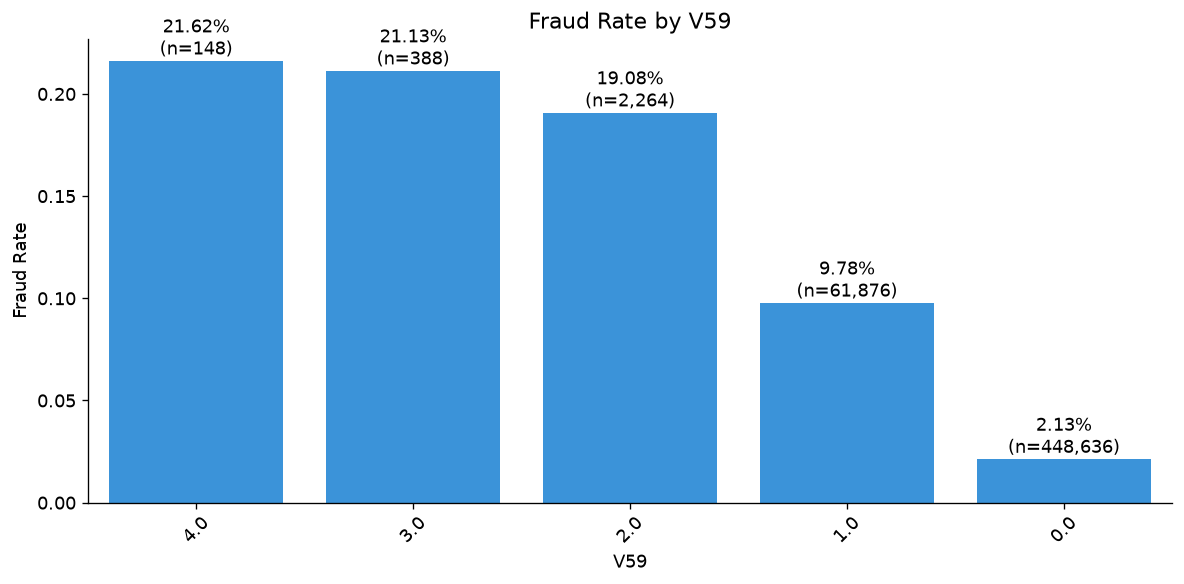

,Transactions,Fraud_Rate,Fraud_Count
V59,,,
4.0,148,0.216216,32
3.0,388,0.211340,82
2.0,2264,0.190813,432
1.0,61876,0.097760,6049
0.0,448636,0.021298,9555



Inspecting Feature: V64


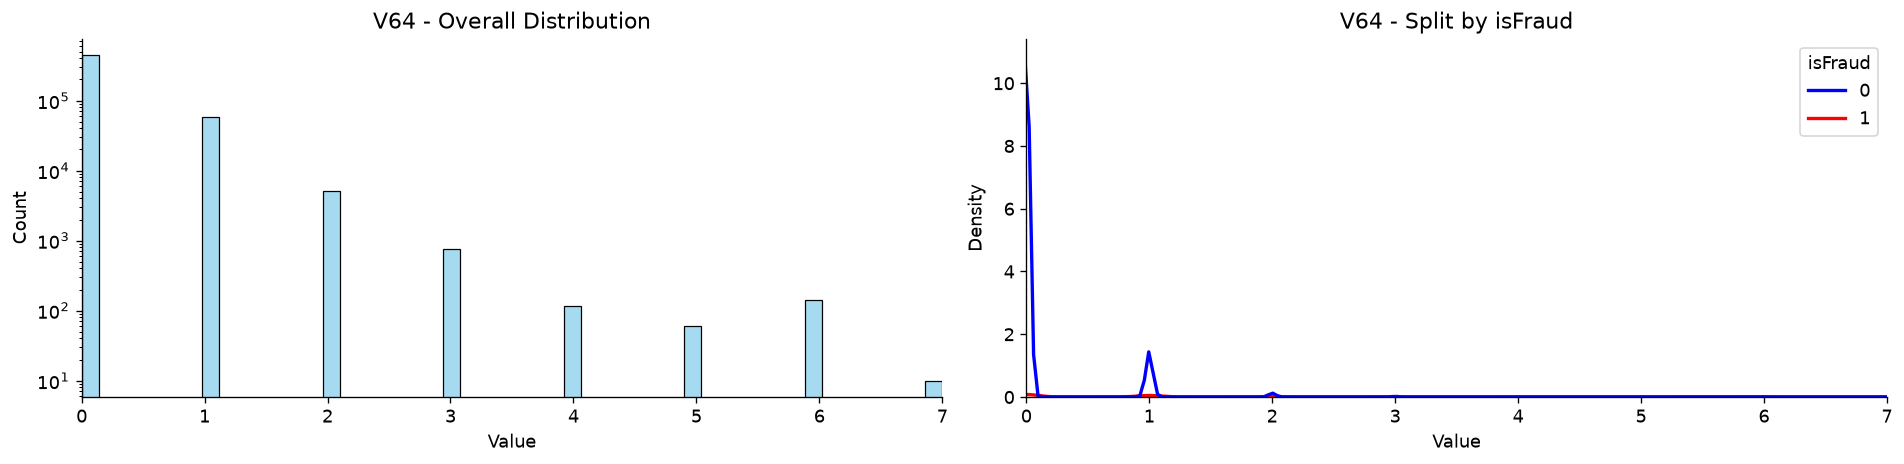

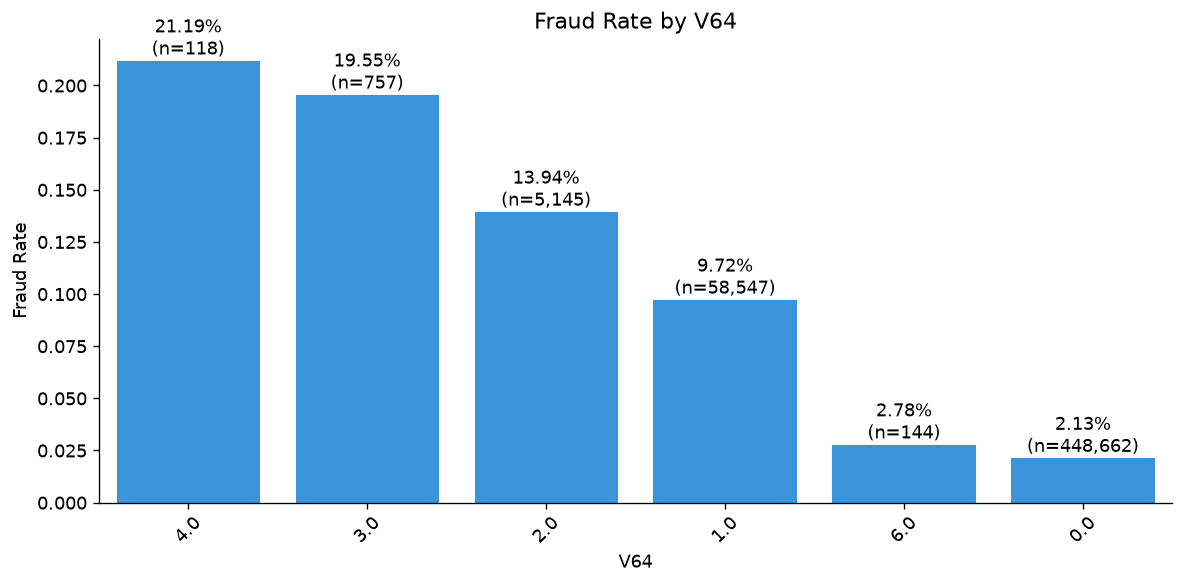

,Transactions,Fraud_Rate,Fraud_Count
V64,,,
4.0,118,0.211864,25
3.0,757,0.195509,148
2.0,5145,0.139359,717
1.0,58547,0.097187,5690
6.0,144,0.027778,4
0.0,448662,0.021301,9557



Inspecting Feature: V247


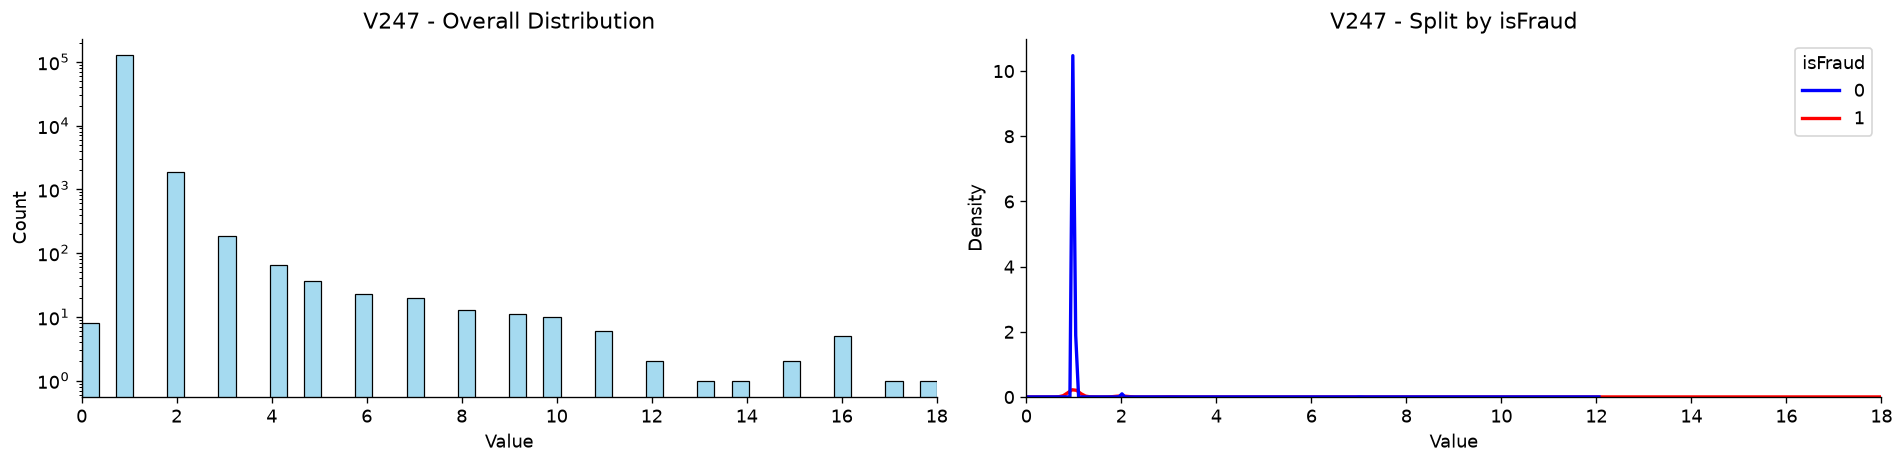

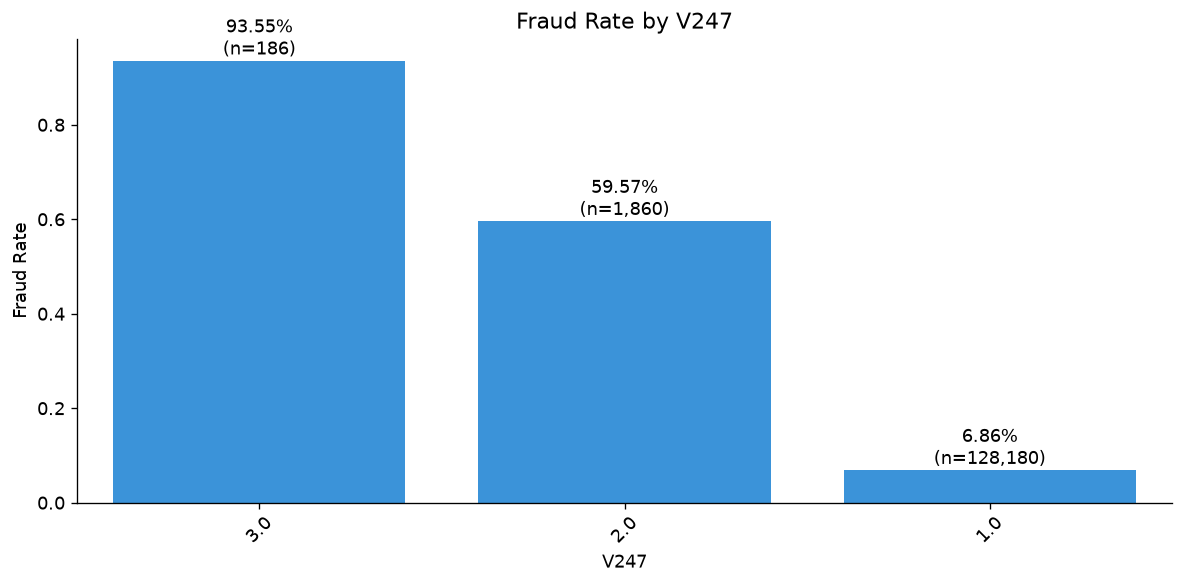

,Transactions,Fraud_Rate,Fraud_Count
V247,,,
3.0,186,0.935484,174
2.0,1860,0.595699,1108
1.0,128180,0.068568,8789



Inspecting Feature: V195


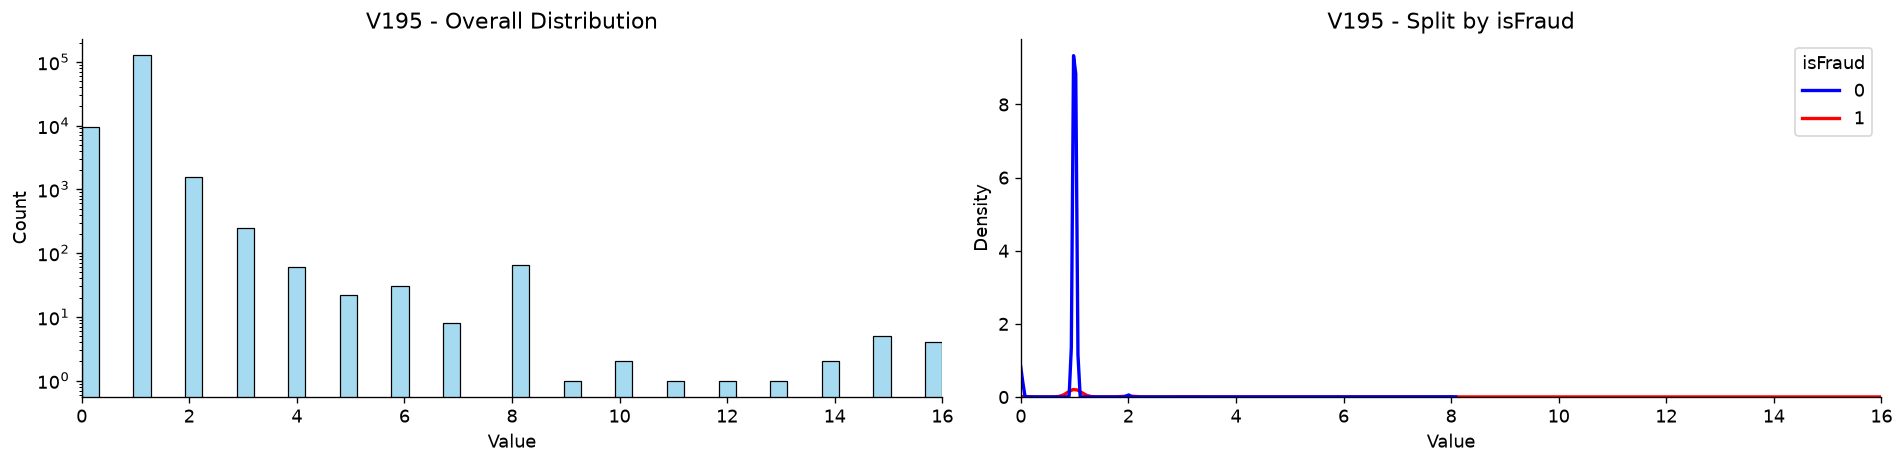

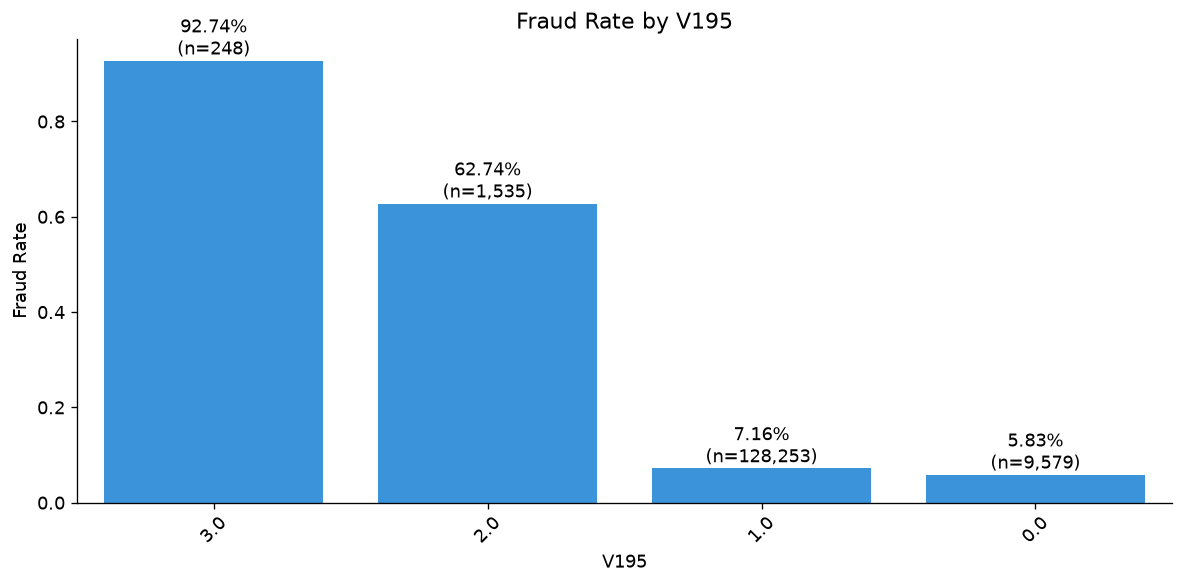

,Transactions,Fraud_Rate,Fraud_Count
V195,,,
3.0,248,0.927419,230
2.0,1535,0.627362,963
1.0,128253,0.071562,9178
0.0,9579,0.058252,558



Inspecting Feature: V302


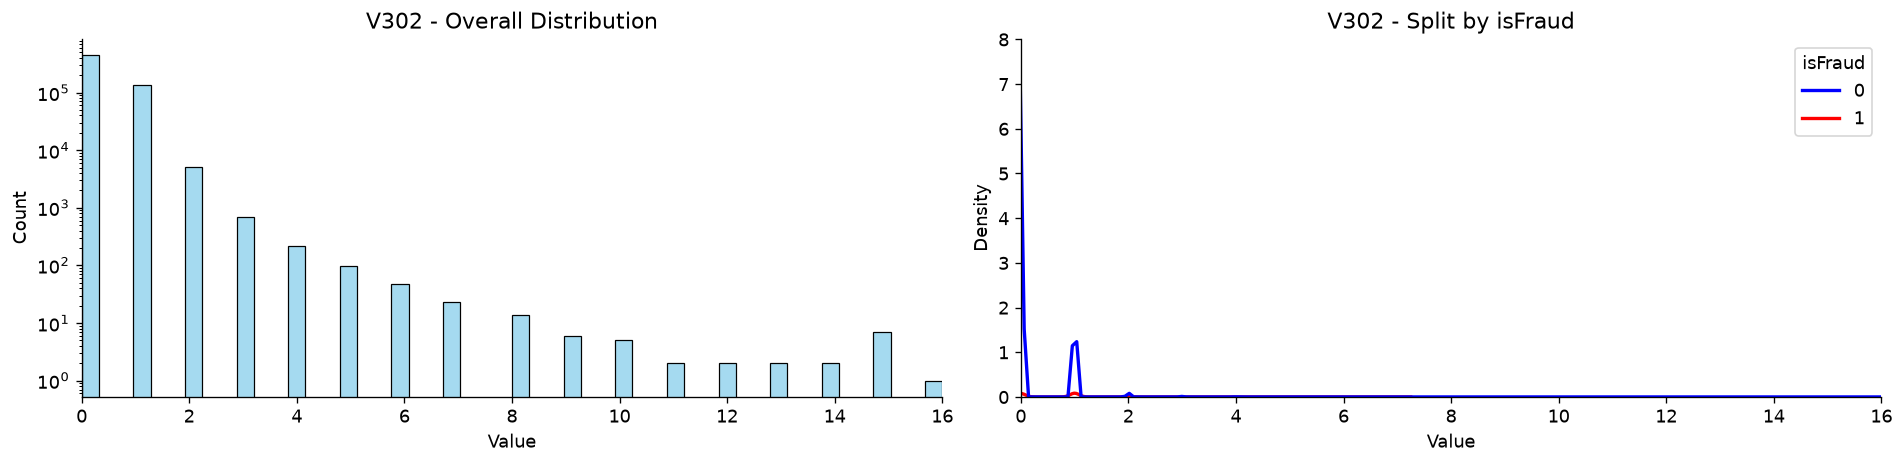

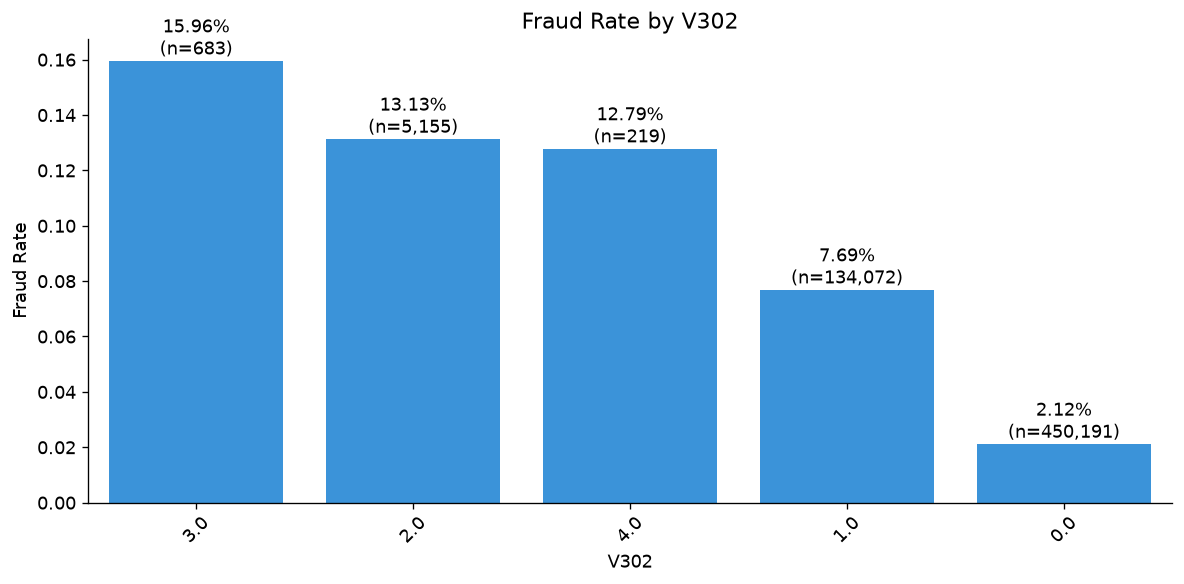

,Transactions,Fraud_Rate,Fraud_Count
V302,,,
3.0,683,0.159590,109
2.0,5155,0.131329,677
4.0,219,0.127854,28
1.0,134072,0.076899,10310
0.0,450191,0.021164,9528


In [98]:
for col in features_to_plot:
    print(f"\n{'='*60}\nInspecting Feature: {col}\n{'='*60}")
    
    # Branch 1: Handling for Numeric Features
    if pd.api.types.is_numeric_dtype(df[col]):
        
        # Plot the overall distribution and the KDE split by fraud
        feature_distribution(dataframe=df, bins=50, column=col, kde=True)
        
        # If the numeric feature has too many unique values, bin it for the fraud rate plot
        if df[col].nunique() > 20:
            df[f"{col}_bin"] = pd.qcut(df[col], q=10, duplicates="drop").astype(str)
            plot_col = f"{col}_bin"
        else:
            plot_col = col
            
    # Branch 2: Handling for Categorical/String Features
    else:
        print(f"Feature '{col}' is categorical. Utilizing countplot instead of KDE.")
        
        # Use the categorical countplot function you defined earlier in the notebook
        categorical_countplot(dataframe=df, column=col, hue="isFraud", top=10)
        
        # If the categorical feature has too many unique strings, group the rare ones
        if df[col].nunique() > 20:
            top_n = df[col].value_counts().head(10).index
            df[f"{col}_grouped"] = df[col].where(df[col].isin(top_n), "Other")
            plot_col = f"{col}_grouped"
        else:
            plot_col = col

    # 3. Plot the specific fraud rates per bin/category for both branches
    plot_fraud_rate(dataframe=df, domain_col=plot_col, top=10)

### IV (Information Value) for C, V, id and D features

In [ ]:
c_id_d_features = {
    "c_features": c_features,
    "id_features": id_features,
    "d_features": d_features,
}

for group_name, features in c_id_d_features.items():
    print(f"\n{"="*50}\n{group_name}\n{"="*50}\n")
    iv_status(df, features)


c_features

C1: IV = 0.2170, and Status: medium
C2: IV = 0.2476, and Status: medium
C3: IV = 0.0000, and Status: useless
C4: IV = 0.5498, and Status: suspiciously strong (check for leakage)
C5: IV = 0.1649, and Status: medium
C6: IV = 0.0967, and Status: weak
C7: IV = 0.5096, and Status: suspiciously strong (check for leakage)
C8: IV = 0.5607, and Status: suspiciously strong (check for leakage)
C9: IV = 0.0649, and Status: weak
C10: IV = 0.5270, and Status: suspiciously strong (check for leakage)
C11: IV = 0.1764, and Status: medium
C12: IV = 0.5212, and Status: suspiciously strong (check for leakage)
C13: IV = 0.0932, and Status: weak
C14: IV = 0.0230, and Status: weak

id_features

id_01: IV = 0.1553, and Status: medium
id_02: IV = 0.0466, and Status: weak
id_03: IV = 0.0520, and Status: weak
id_04: IV = 0.0355, and Status: weak
id_05: IV = 0.0264, and Status: weak
id_06: IV = 0.0497, and Status: weak
id_07: IV = 0.1645, and Status: medium
id_08: IV = 0.0814, and Status: weak
id_09:

We will do the Leakage check for C, V, id and D features

### Leakage Audit Block for C, V, id and D features

In [119]:
len(c_features + v_features+ id_features+ d_features)

270

In [139]:
all_features = {
    "c_features": c_features,
    "v_features": v_features,
    "id_features": id_features,
    "d_features": d_features,
}

total_leaks_to_drop = []

for group_name, features in all_features.items():
    leakage_suspects = iv_df[iv_df["feature"].isin(features) & (iv_df["IV"] >= 0.5)].sort_values(by="IV", ascending=False)
    suspect_cols = leakage_suspects["feature"].tolist()
    
    print(f"\n[{group_name}] Found {len(suspect_cols)} features suspected of data leakage. Running audit...")
    
    if len(suspect_cols) > 0:
        # Run the audit and catch the returned list of leakers
        leaks_found = audit_leakage(df, suspect_cols)
        total_leaks_to_drop.extend(leaks_found)
        
        # Explicitly announce if the audit ran but found nothing
        if not leaks_found:
            print(f" ✅ Audit complete: No leaks found in {group_name}. All suspects are safe to use.")
    else:
        print(f" ✅ No high-IV suspects found in {group_name}.")

print(f"\n{'='*50}\nFINAL AUDIT SUMMARY\n{'='*50}")
print(f"Total confirmed leakers to drop: {total_leaks_to_drop}")


[c_features] Found 5 features suspected of data leakage. Running audit...
 ✅ Audit complete: No leaks found in c_features. All suspects are safe to use.

[v_features] Found 43 features suspected of data leakage. Running audit...
 🚨 LEAKAGE DETECTED IN V79


,Transactions,Fraud_Rate
V79,,
7.0,109,0.0


 🚨 LEAKAGE DETECTED IN V93


,Transactions,Fraud_Rate
V93,,
7.0,109,0.0



[id_features] Found 0 features suspected of data leakage. Running audit...
 ✅ No high-IV suspects found in id_features.

[d_features] Found 4 features suspected of data leakage. Running audit...
 ✅ Audit complete: No leaks found in d_features. All suspects are safe to use.

FINAL AUDIT SUMMARY
Total confirmed leakers to drop: ['V79', 'V93']


# Data Cleaning Steps